In [86]:
import numpy as np
print("NumPy版本:", np.__version__)


NumPy版本: 1.23.5


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
import os
import matplotlib.ticker as ticker
from adjustText import adjust_text
import copy
import statistics
import pandas as pd
from matplotlib.lines import Line2D
#from brokenaxes import brokenaxes
#%matplotlib notebook

In [2]:
file_path = "C:\\Users\\zyx\\Desktop\\data\\CO_and_HCO\\source.vsys.dat"
import pandas as pd

# 假设文件格式：
# 列名: ID   Vsys   RA    Dec
# 数据: 001  250.3  12.5  30.0
# 注释行以 '#' 开头

df = pd.read_csv(
    file_path,
    sep='\s+',          # 按空格/制表符分隔
    comment='#',        # 忽略注释行
    header=0,           # 第一行为列名
    #names=['ID', 'Vsys', 'RA', 'Dec']  # 可选：手动指定列名
)

print(df)   # df.head()则默认输出前五行数据，在数据量大的时候可以方便检查

   source, field,        ra,       dec,       Vsys,  Vsys_sigma
0     Ll01   Ll01  81.505174 -67.503328  287.328125    0.983483
1     Ll02   Ll02  73.534500 -66.775389  274.113342    1.343082
2     Ll03   Ll03  84.478441 -69.576586  265.006836    0.913653
3     Ll04   Ll04  75.983875 -67.344111  269.604950    2.035654
4   Ll04_2   Ll04  75.982767 -67.345826  268.652863    1.179893
..     ...    ...        ...        ...         ...         ...
66     S07    S07  13.514352 -73.327366  163.216629    1.475220
67     S08    S08  12.257295 -73.186037  146.751221    1.218433
68     S09    S09  11.235079 -73.169770  132.257156    2.265169
69     S10    S10  16.280342 -71.995208  189.761490    1.967455
70   S10_2    S10  16.274230 -71.995216  190.884918    1.150420

[71 rows x 6 columns]


In [3]:
sou=df["source,"].tolist()
V=df["Vsys,"].tolist()
print(sou)
print(V)
print(type(sou))
print(type(V))

['Ll01', 'Ll02', 'Ll03', 'Ll04', 'Ll04_2', 'Ll05', 'Ll06', 'Ll06_2', 'Ll06_3', 'Ll07', 'Ll07_2', 'Ll08', 'Ll09', 'Ll09_2', 'Ll09_3', 'Ll09_4', 'Ll09_5', 'Ll10', 'Ll10_2', 'Lm01', 'Lm02', 'Lm02_2', 'Lm02_3', 'Lm03', 'Lm04', 'Lm04_2', 'Lm04_3', 'Lm05', 'Lm05_2', 'Lm05_3', 'Lm06', 'Lm06_2', 'Lm06_3', 'Lm07', 'Lm07_2', 'Lm07_3', 'Lm08', 'Lm09', 'Lm10', 'Lh01', 'Lh01_2', 'Lh01_3', 'Lh02', 'Lh02_2', 'Lh02_3', 'Lh03', 'Lh04', 'Lh05', 'Lh05_2', 'Lh05_3', 'Lh05_4', 'Lh06', 'Lh07', 'Lh08', 'Lh08_2', 'Lh08_3', 'Lh08_4', 'Lh09', 'Lh10', 'S01', 'S01_2', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S10_2']
[287.328125, 274.1133423, 265.0068359, 269.60495, 268.6528625, 274.9273682, 231.8370972, 232.4548035, 235.1858368, 267.088623, 266.247467, 235.3066406, 283.1570435, 282.2198181, 285.8900146, 279.8934326, 281.043335, 249.9293213, 249.9293213, 276.4645691, 230.7684784, 230.9107971, 229.9667053, 296.7356262, 283.2704773, 282.0755615, 284.4465637, 236.2545319, 237.4716644, 233.84242

In [4]:
def open_file():
    path='C:\\Users\\zyx\\Desktop\\data\\spw1'  #设置存储路径
    files= os.listdir(path) #得到文件夹下的所有文件名称
    name_list=source_name(files) # 得到每个源的名字
    data=[]  # 建立空列表储存数据
    data_i=0 # 记录是第几个文件

    for file in files:  #按照顺序在 files 里面进行每一个文件的 数据名称 循环读取
        position = path+"\\"+file   # 打开第一个文件
        data.append([])
        with open(position, 'r') as f:
            line_num=0
            for line in f:
                if line_num>0:
                    data[data_i].append(line.strip().split())
                line_num+=1
        data_i+=1
    return data,name_list

In [5]:
def source_name(name):
    name_list=[]
    for i in range(len(name)):
        part=name[i].split(".")
        name_list.append(part[1])
    return name_list

In [6]:
def data_to_xy(data):   # 输入某一个文件的数据，转换成xy
    data_x=[]
    data_y=[]
    for i in range(len(data)):
        data_x.append(float(data[i][0]))
        data_y.append(float(data[i][1]))
    return data_x,data_y

In [7]:
def paint(x,y):    # 把光谱画出来
    plt.plot(x,y)
    plt.xlabel("frequency (GHz)")
    plt.ylabel("flux (Jy/beam)")
    #plt.autoscale(enable=True, axis='y', tight=True)
    plt.ticklabel_format(useOffset=False, style='plain')
    plt.show()

In [8]:
data,name_list=open_file()

indices = [i for i, name in enumerate(name_list) if name == 'Ll02']
for i in sorted(indices, reverse=True):
    del data[i]
    del name_list[i]  # 如果同时需要删除名字列表中的元素
    
indices = [i for i, name in enumerate(name_list) if name == 'Ll04']
for i in sorted(indices, reverse=True):
    del data[i]
    del name_list[i]  # 如果同时需要删除名字列表中的元素
    
print(len(data))
print(len(name_list))
# print(name_list)

190
190


删掉两个源后，注意要修改视向速度

In [9]:
# 归一化（用HCO+的数据归一化）
def guiyihua(list5,flux_HCO):
    list6=[]
    for i in range(len(list5)):
        list6.append(list5[i]/flux_HCO)
        
    return list6

In [10]:
def find_peak2(x,y):
    m=max(y)
    index_m=y.index(m)
    return m,index_m

In [11]:
# 找到每个源的视向速度
def Vsys(name,source,V):
    V_rest_source=[]
    for i in range(len(name)):
        for j in range (len(source)):
            if name[i]==source[j]:
                V_rest_source.append(V[j])
                break
    return V_rest_source

In [12]:
# 找到每个源的HCO+的流量
def guiyi_HCO(name,source,flux):
    F=[]
    for i in range(len(name)):
        for j in range(len(source)):
            if name[i]==source[j]:
                F.append(flux[j])
                break
    return F

In [13]:
# 视向速度
V_rest_source=Vsys(name_list,sou,V)
# print(V_rest_source)
print(len(V_rest_source))
print(len(data))

190
190


In [14]:
# 插值法对齐频率
import numpy as np
from scipy.interpolate import interp1d

def align_spectra_to_grid(spectra, f_start=None, f_end=None, df=None, kind='linear'):
    """
    将多个光谱对齐到统一的频率网格。
    
    参数：
        spectra (list of dict): 每个字典包含'f'和'flux'数组。
        f_start (float): 统一频率范围的起始值。若为None，自动计算。
        f_end (float): 统一频率范围的结束值。若为None，自动计算。
        df (float): 频率步长。若为None，取所有光谱的最小步长。
        kind (str): 插值方法（'linear', 'cubic', 'nearest'）。
    
    返回：
        f_new (np.array): 统一频率网格。
        aligned_flux (np.array): 对齐后的流量矩阵（光谱数 × 频率点数）。
    """
    # 自动确定频率范围和步长
    if f_start is None or f_end is None:
        all_f = np.concatenate([spec['f'] for spec in spectra])
        f_start = all_f.min() if f_start is None else f_start
        f_end = all_f.max() if f_end is None else f_end
    
    if df is None:
        df_list = [np.diff(spec['f']).min() for spec in spectra]
        df = min(df_list)
    
    # 生成统一频率网格
    f_new = np.arange(f_start, f_end + df, df)
    
    # 插值每个光谱
    aligned_flux = []
    for spec in spectra:
        f_orig = spec['f']
        flux_orig = spec['flux']
        # 创建插值函数（超出范围填充NaN）
        interp_func = interp1d(f_orig, flux_orig, kind=kind, bounds_error=False, fill_value=0)
        flux_new = interp_func(f_new)
        aligned_flux.append(flux_new)
    
    return f_new, np.array(aligned_flux)
        

In [15]:
# lll=[[] for _ in range(40)]
# print(lll)
# aaa=[1,2,3]
# bbb=[4,5,6]
# lll[0].append(aaa)
# lll[0].append(bbb)
# print(lll)
# lll[0]=np.concatenate(lll[0]).tolist()
# print(lll)

In [16]:
# 读取HCO+的最大流量信息
import pandas as pd

# 假设文件格式：
# 列名: ID   Vsys   RA    Dec
# 数据: 001  250.3  12.5  30.0
# 注释行以 '#' 开头

df_flux = pd.read_csv(
    "data_with_HCO_flux.txt",
    sep='\s+',          # 按空格/制表符分隔
    #comment='#',        # 忽略注释行
    header=0,           # 第一行为列名
    #names=['ID', 'Vsys', 'RA', 'Dec']  # 可选：手动指定列名
)

name_HCO=df_flux.iloc[:, 0].tolist()   # df.head()则默认输出前五行数据，在数据量大的时候可以方便检查
flux_HCO=df_flux.iloc[:, 1].tolist()

print(flux_HCO)
print(len(flux_HCO))

[0.236722291, 0.332697213, 0.594777167, 0.284221739, 0.50144136, 0.309614241, 0.822760761, 0.342617989, 0.567353308, 0.645932913, 0.151109248, 0.103599511, 0.177517712, 0.0613674298, 0.0974844024, 0.158679515, 0.147837862, 0.353915006, 0.0995358974, 0.163344994, 0.0738406479, 0.183654696, 0.104190871, 0.201626703, 0.402454019, 0.263523281, 0.24253118, 0.44099158, 0.0751578659, 0.028581392, 0.152063936, 0.0628216565, 0.174288481, 0.112904117, 0.155170918, 0.0690230802, 0.206649378, 0.264712214]
38


In [17]:
# HCO+最大流量
F=guiyi_HCO(name_list,name_HCO,flux_HCO)
# print(F)
print(len(F))

190


统一频率网格长度: 2107
对齐后的流量矩阵形状: (38, 2107)
统一频率网格长度: 2107
对齐后的流量矩阵形状: (38, 2107)
统一频率网格长度: 4028
对齐后的流量矩阵形状: (38, 4028)
统一频率网格长度: 4042
对齐后的流量矩阵形状: (38, 4042)
统一频率网格长度: 4044
对齐后的流量矩阵形状: (38, 4044)


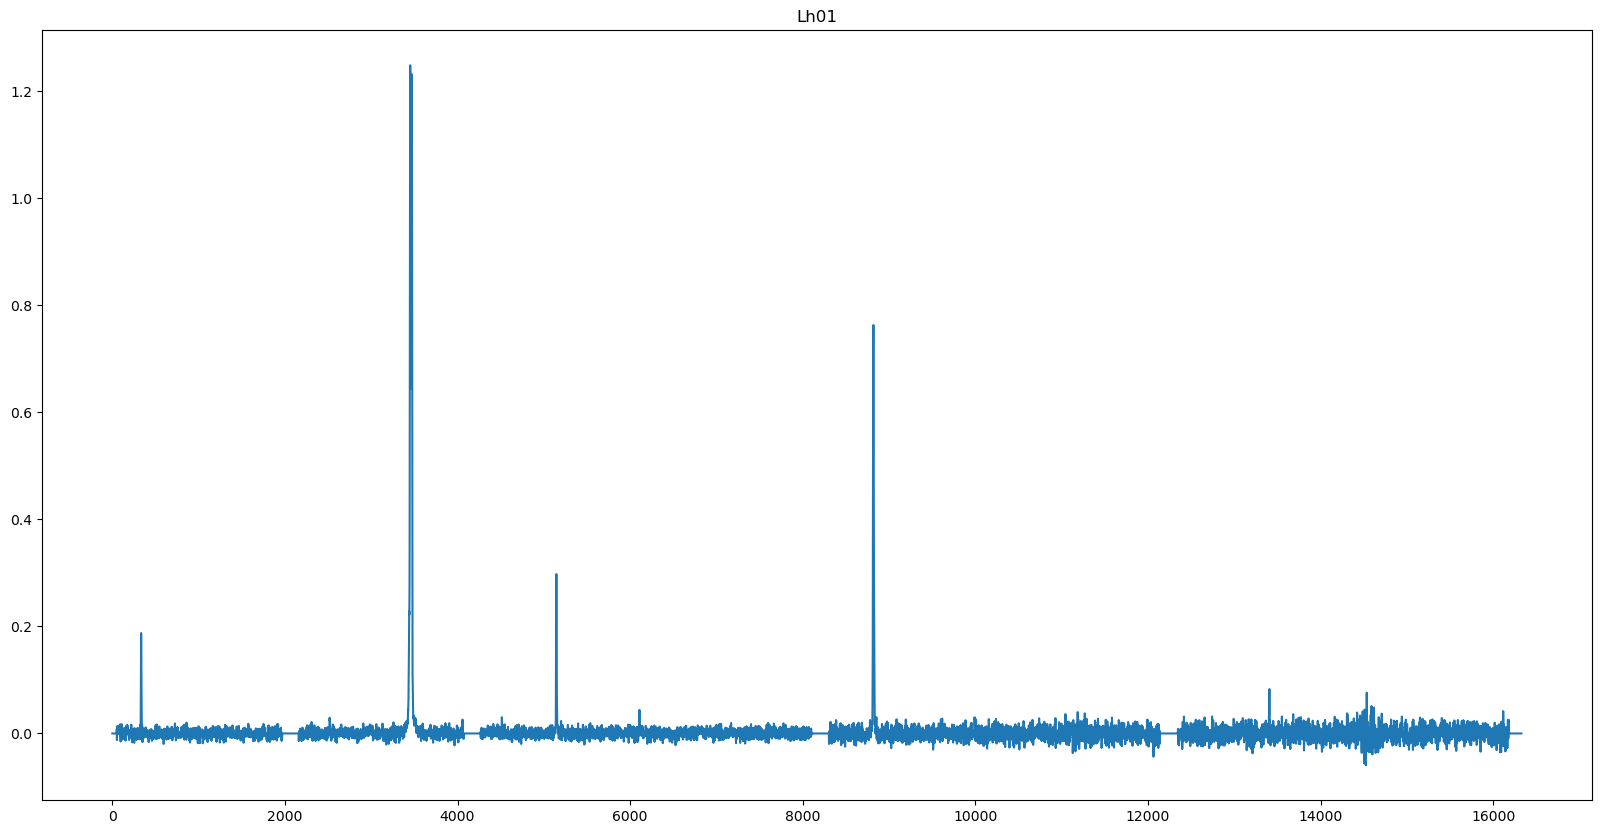

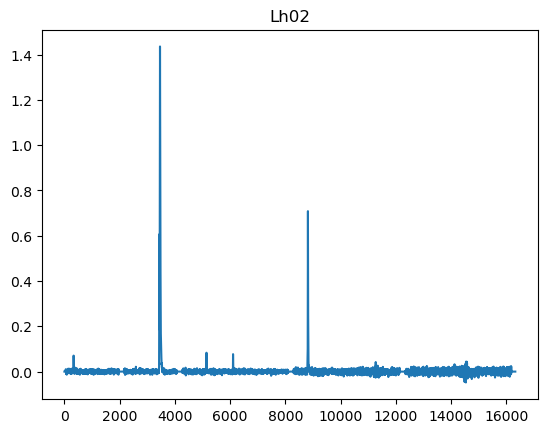

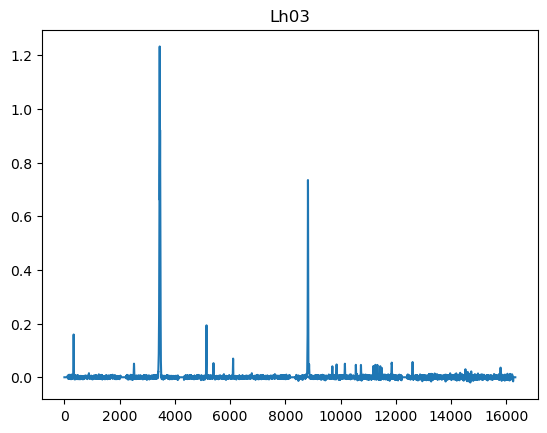

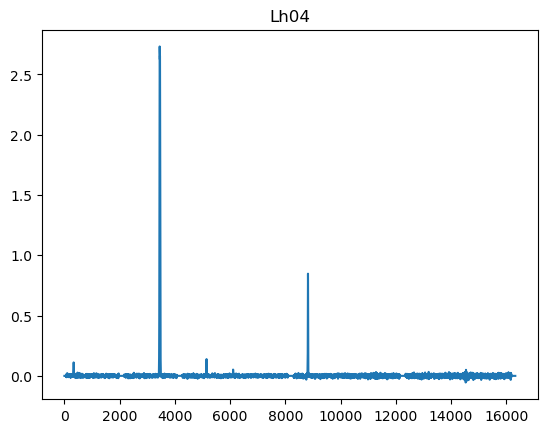

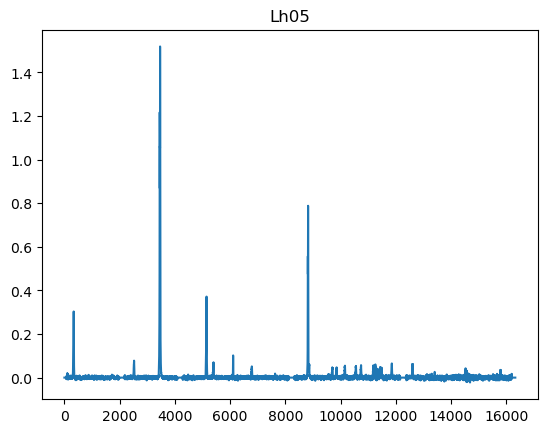

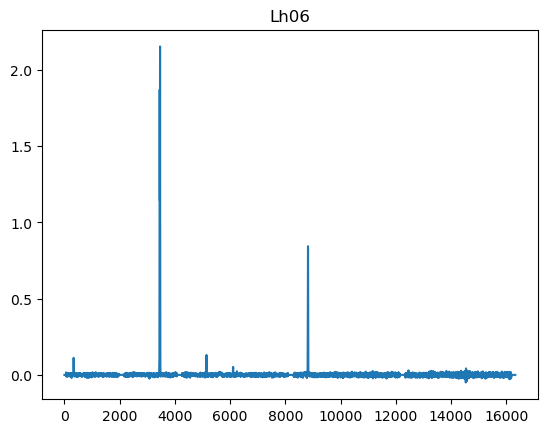

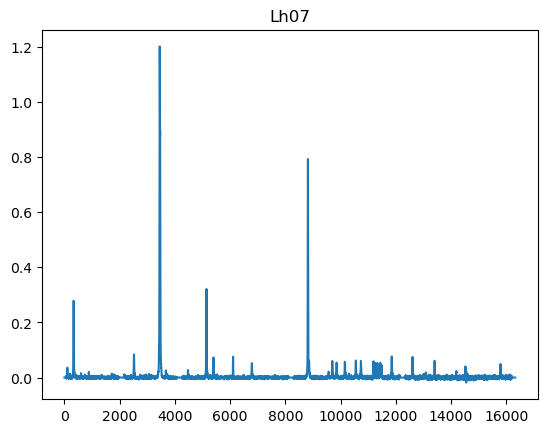

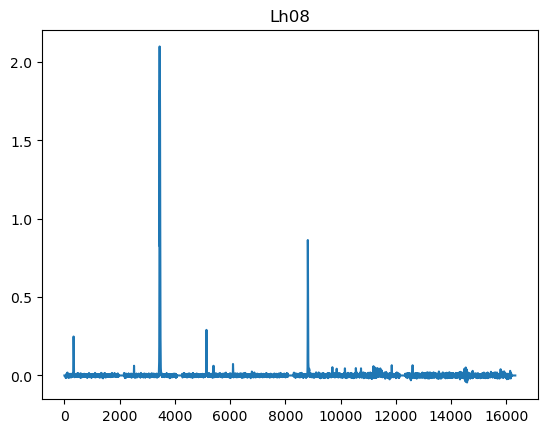

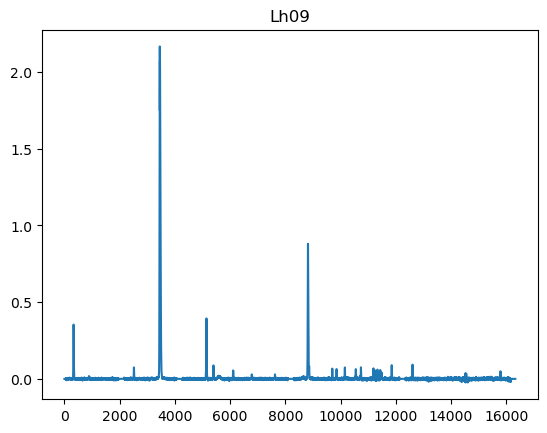

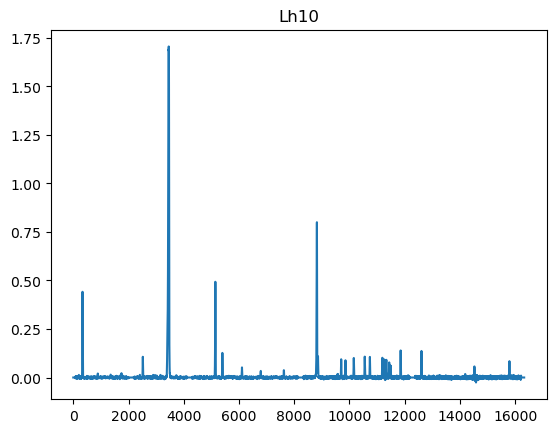

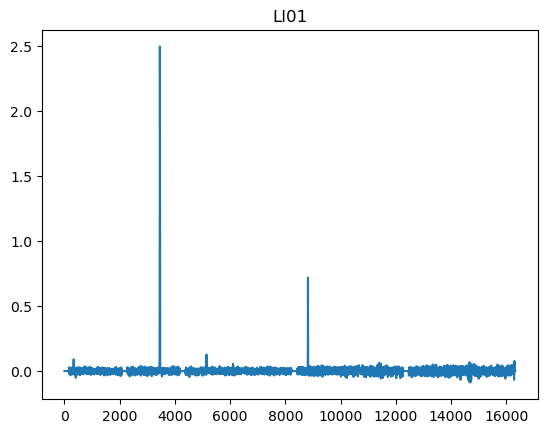

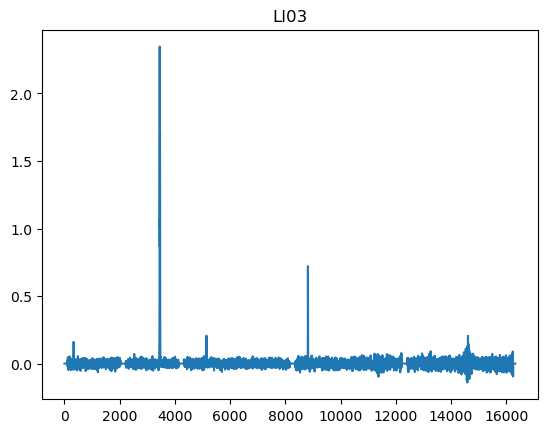

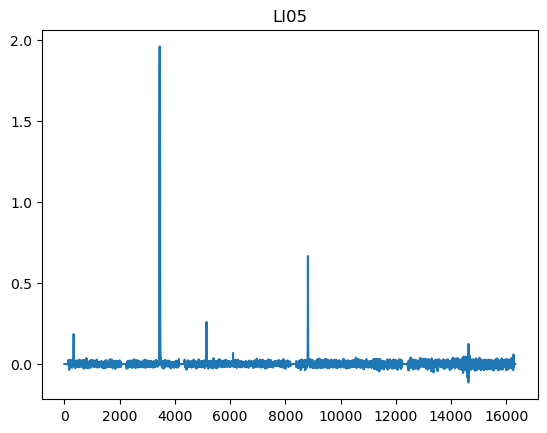

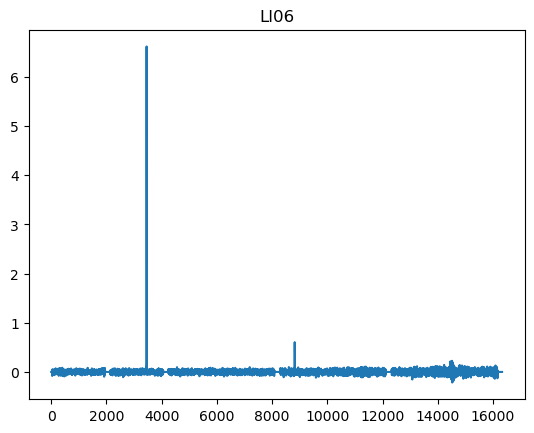

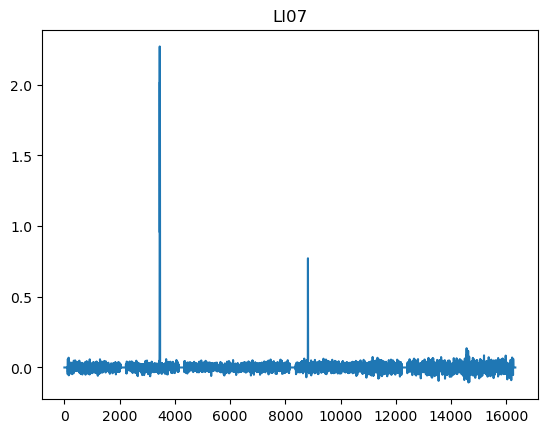

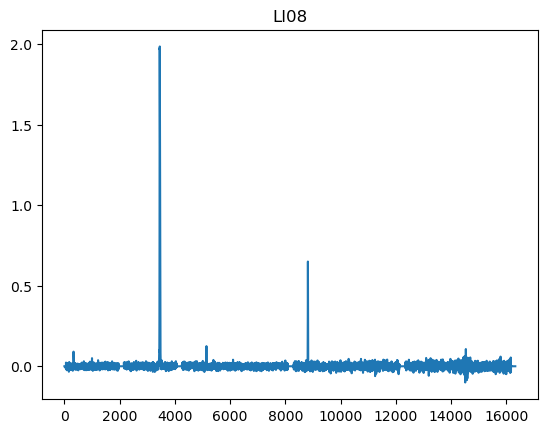

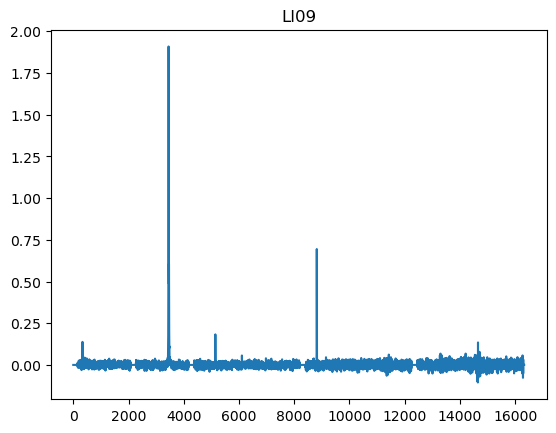

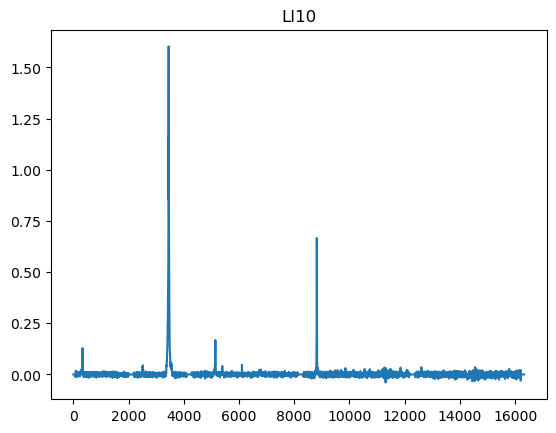

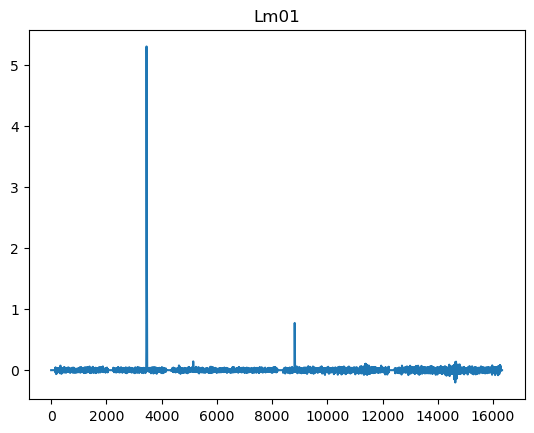

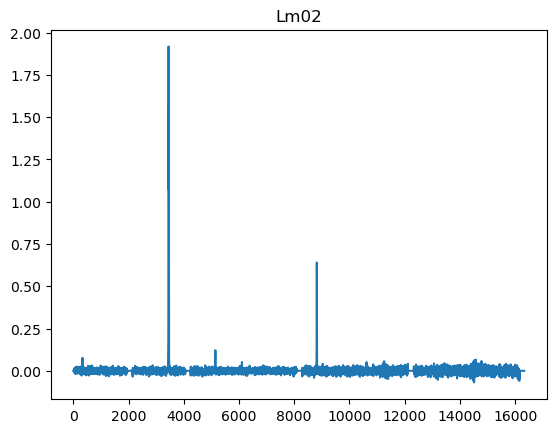

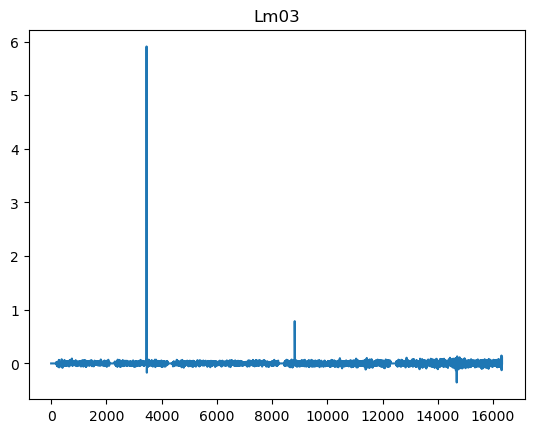

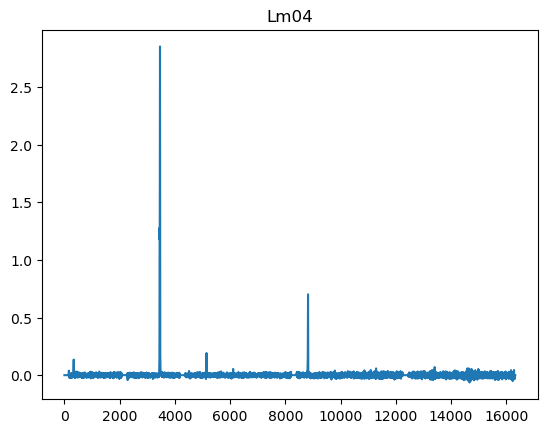

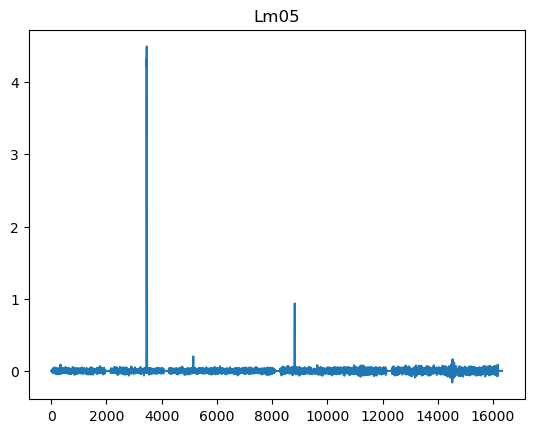

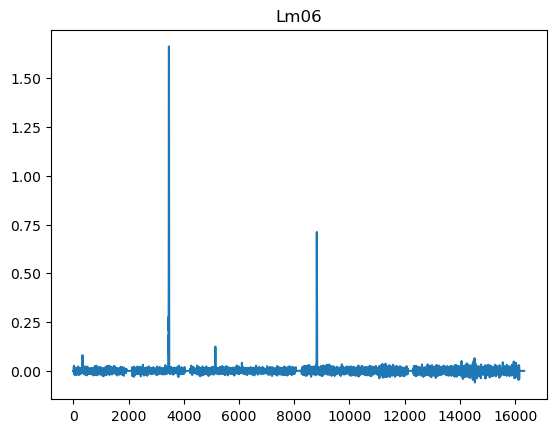

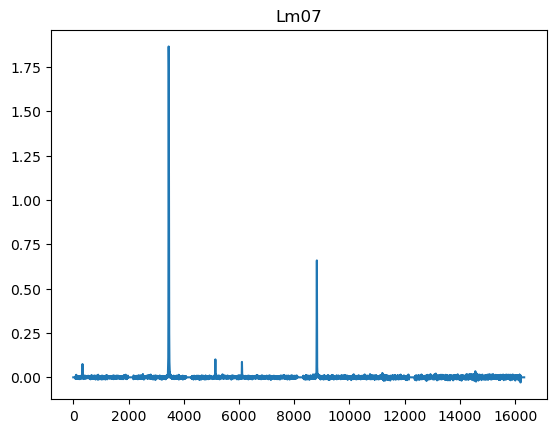

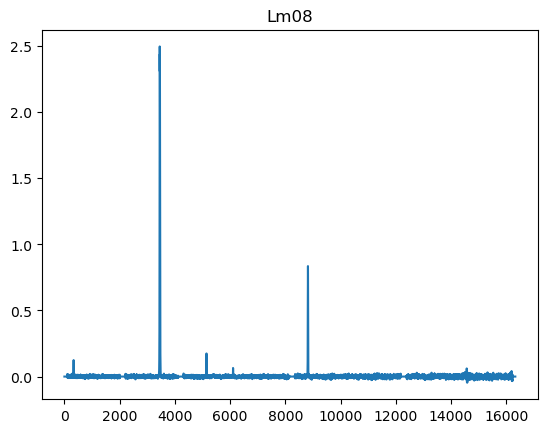

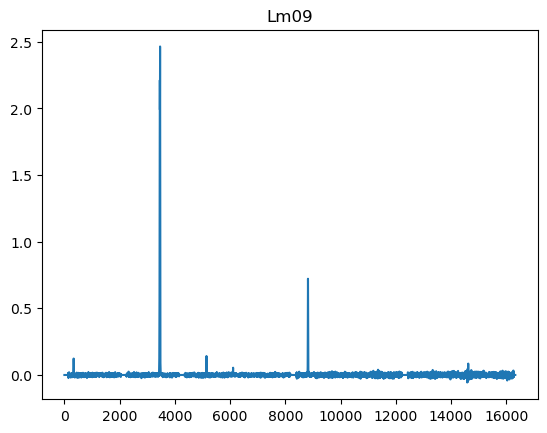

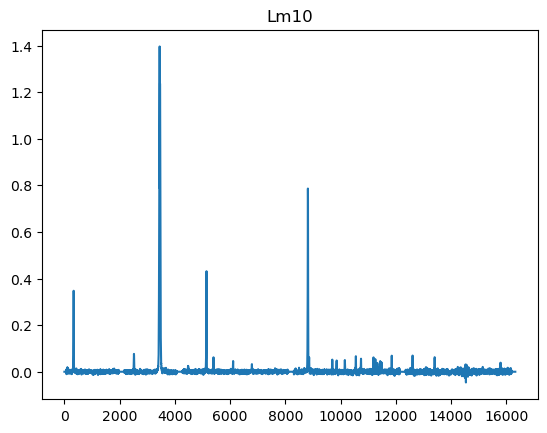

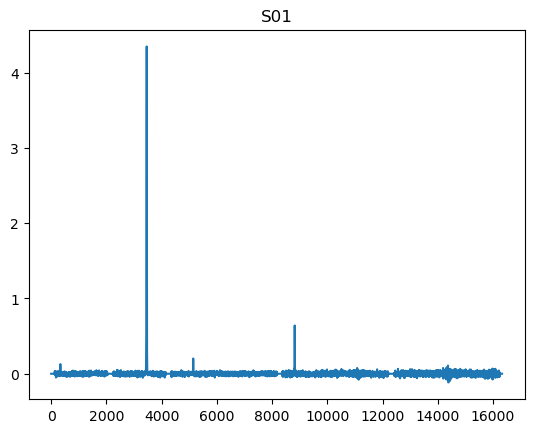

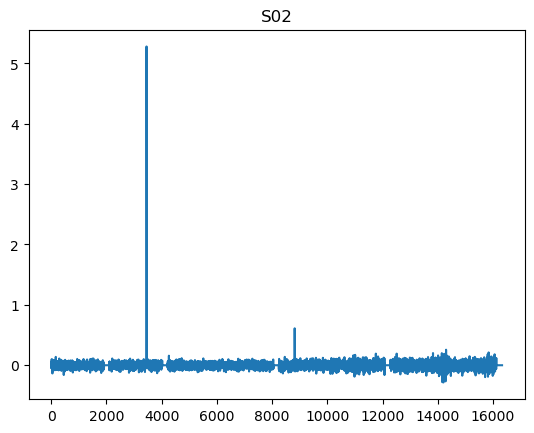

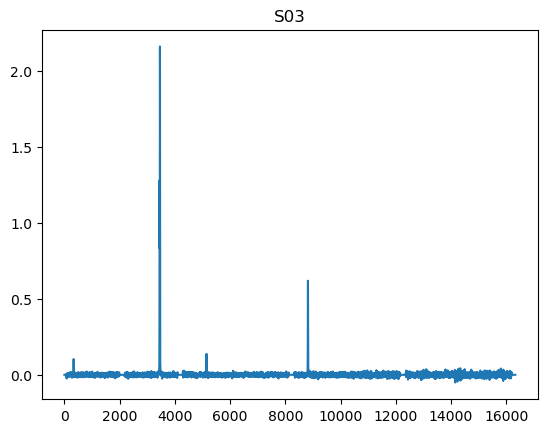

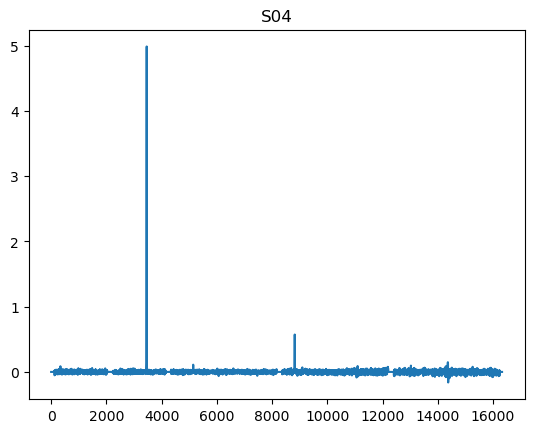

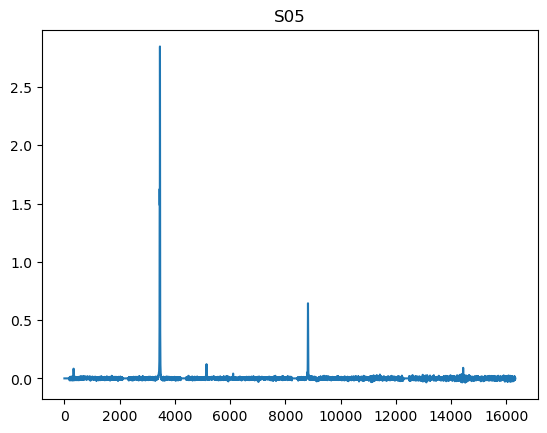

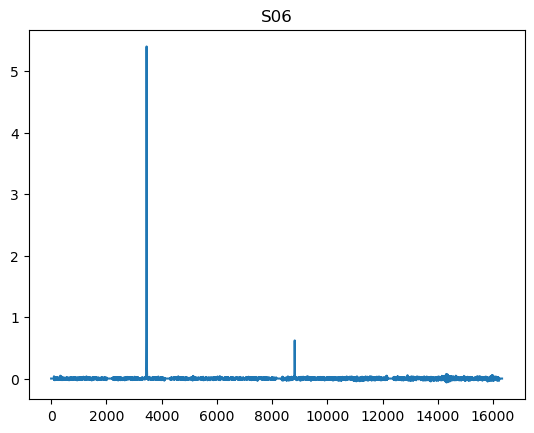

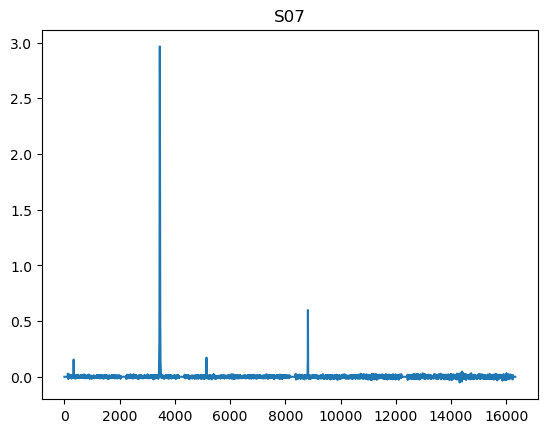

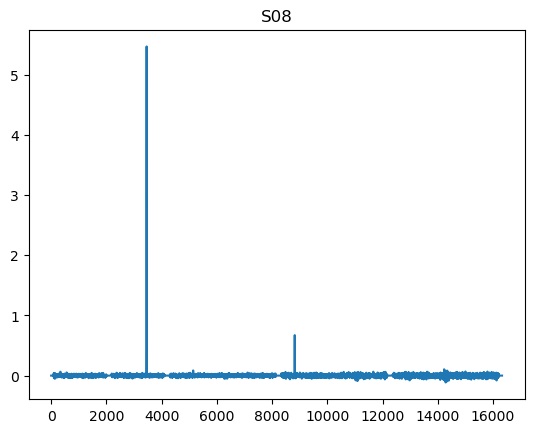

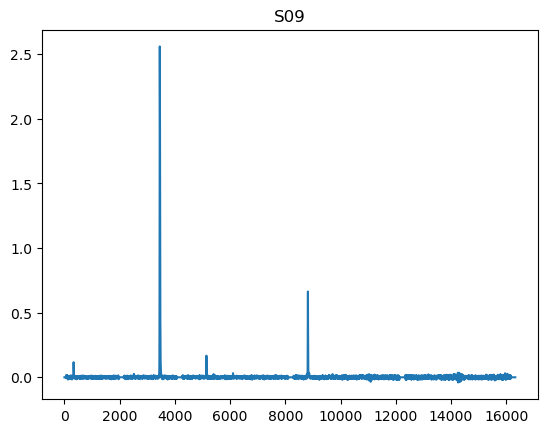

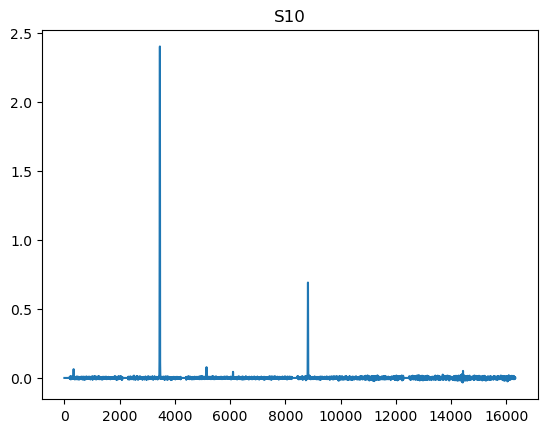

['Lh01', 'Lh02', 'Lh03', 'Lh04', 'Lh05', 'Lh06', 'Lh07', 'Lh08', 'Lh09', 'Lh10', 'Ll01', 'Ll03', 'Ll05', 'Ll06', 'Ll07', 'Ll08', 'Ll09', 'Ll10', 'Lm01', 'Lm02', 'Lm03', 'Lm04', 'Lm05', 'Lm06', 'Lm07', 'Lm08', 'Lm09', 'Lm10', 'S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10']
16328


In [18]:
# 删掉识别不出的线和太密集的线
# 对齐速度
c=299792458

plt.figure(figsize=(20,10))
count=38
data_flux=[[] for _ in range(count)]  # 最后用来合并不同通道的列表
data_x=[[] for _ in range(count)]
data_name=[]
for k in range(5):
    f=[]  # 用来组合成字典的列表
    flux=[]
    
    for i in range(count):   #len(data)
        list_x=[]
        list_y=[]
        delta=[]
        
        if k==0:   # 记录源的名字
            data_name.append(name_list[i*5])
            
        
        raw_x,raw_y=data_to_xy(data[i*5+k])   # 一个spw文件的数据
        for j in range(len(raw_x)):    
            list_x.append(raw_x[j]/(1-(V_rest_source[i*5+k]*1000/c)))  # 把视向速度扣掉
            list_y.append(raw_y[j]/F[i*5+k])                   # 用HCO+的流量归一化
        #plt.plot(list_x,list_y)

        f.append(list_x)
        flux.append(list_y)
    #plt.show()

    spectra = [
        {"f": f, "flux": flux}
        for f,flux in zip(f, flux)
    ]

    f_new, aligned_flux = align_spectra_to_grid(spectra, kind='linear')

    # 输出结果形状
    print("统一频率网格长度:", len(f_new))
    print("对齐后的流量矩阵形状:", aligned_flux.shape)

    f_new=list(f_new)
    aligned_flux=list(aligned_flux)

    for m in range(len(aligned_flux)):
        aligned_flux[m]=list(aligned_flux[m])

    for j in range(count):
        data_x[j].append((f_new))
        data_flux[j].append(aligned_flux[j])

for n in range(count):
    data_x[n]=np.concatenate(data_x[n]).tolist()
    data_flux[n]=np.concatenate(data_flux[n]).tolist()



for i in range(len(data_flux)):
#     plt.plot(f_new, aligned_flux[i])
    plt.plot(data_flux[i])
    plt.title(name_list[i*5])
#     print(len(data_flux[i]))
    plt.show()
print(data_name)
print(len(data_x[0]))

In [19]:
# 读取每个源的光度
import pandas as pd

# 假设文件格式：
# 列名: ID   Vsys   RA    Dec
# 数据: 001  250.3  12.5  30.0
# 注释行以 '#' 开头

df_L = pd.read_csv(
    "C:\\Users\\zyx\\Desktop\\data\\name_L.txt",
    sep='\s+',          # 按空格/制表符分隔
    #comment='#',        # 忽略注释行
    header=0,           # 第一行为列名
    #names=['ID', 'Vsys', 'RA', 'Dec']  # 可选：手动指定列名
)

print(df_L.iloc[:, 0].tolist())   # df.head()则默认输出前五行数据，在数据量大的时候可以方便检查

name_=df_L.iloc[:, 0].tolist()
name_L=df_L.iloc[:, 1].tolist()
name_.pop(1)
name_L.pop(1)
name_.pop(2)
name_L.pop(2)
print(name_)

['Ll01', 'Ll02', 'Ll03', 'Ll04', 'Ll05', 'Ll06', 'Ll07', 'Ll08', 'Ll09', 'Ll10', 'Lm01', 'Lm02', 'Lm03', 'Lm04', 'Lm05', 'Lm06', 'Lm07', 'Lm08', 'Lm09', 'Lm10', 'Lh01', 'Lh02', 'Lh03', 'Lh04', 'Lh05', 'Lh06', 'Lh07', 'Lh08', 'Lh09', 'Lh10', 'S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10']
['Ll01', 'Ll03', 'Ll05', 'Ll06', 'Ll07', 'Ll08', 'Ll09', 'Ll10', 'Lm01', 'Lm02', 'Lm03', 'Lm04', 'Lm05', 'Lm06', 'Lm07', 'Lm08', 'Lm09', 'Lm10', 'Lh01', 'Lh02', 'Lh03', 'Lh04', 'Lh05', 'Lh06', 'Lh07', 'Lh08', 'Lh09', 'Lh10', 'S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10']


In [20]:
from sklearn.datasets import load_digits
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE,MDS, Isomap,LocallyLinearEmbedding,SpectralEmbedding
from sklearn.decomposition import PCA


In [21]:
print(len(data_flux))

38


In [22]:
spec=SpectralEmbedding(n_components=3)
digits_spec=spec.fit_transform(data_flux)

D:\anaconda\lib\site-packages\sklearn\manifold\_spectral_embedding.py:274: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


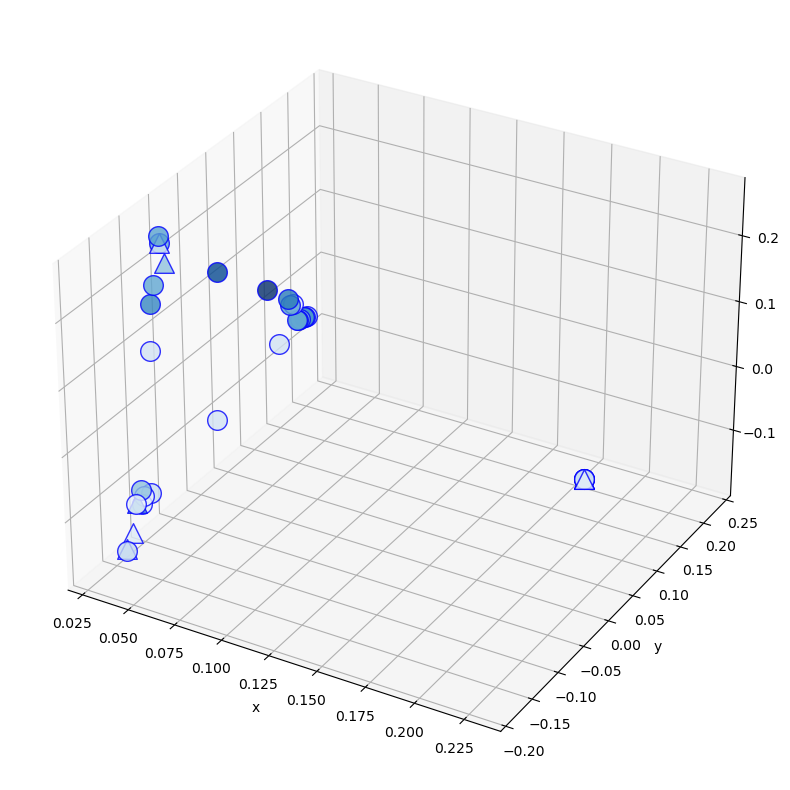

In [23]:
# 画图
# SpectralEmbedding
plt.figure(figsize=(10,10))


# 颜色设置
cmap1=plt.cm.Blues
cmap2=plt.cm.Oranges
cmap3=plt.cm.Purples
cmap4=plt.cm.Greens

ax1 = plt.axes(projection='3d')

# digits_str = name_list[0][2:4]
# print(digits_str)
# print(int(digits_str))

for i in range(len(digits_spec)):
    if data_name[i][0]=="L":    # 大麦哲伦云里的
        for j in range(len(name_)):
            if data_name[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    ax1.scatter3D(digits_spec[i, 0], digits_spec[i, 1],digits_spec[i, 2], s=200,color=color0, label=data_name[i],alpha=0.8,edgecolors=(0,0,1,0.8))
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    ax1.scatter3D(digits_spec[i, 0], digits_spec[i, 1],digits_spec[i, 2], s=200,color=color0, label=data_name[i],alpha=0.8,edgecolors=(0,0,1,0.8))
                    break
        continue
        
    elif data_name[i][0]=="S":
        for j in range(len(name_)):
            if data_name[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    ax1.scatter3D(digits_spec[i, 0], digits_spec[i, 1],digits_spec[i, 2], s=200,color=color0, label=data_name[i],alpha=0.8,marker="^",edgecolors=(0,0,1,0.8))
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    ax1.scatter3D(digits_spec[i, 0], digits_spec[i, 1],digits_spec[i, 2], s=200,color=color0, label=data_name[i],alpha=0.8,marker="^",edgecolors=(0,0,1,0.8))
                    break
        continue

ax1.set_ylim([-0.2, 0.25])
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')

# new_texts = [plt.text(x_, y_, text, fontsize=12) for x_, y_, text in zip(digits_spec[:, 0], digits_spec[:, 1], data_name)]
# adjust_text(new_texts,arrowprops=dict(arrowstyle='->',color='red',lw=1))
#plt.legend(loc="right")
#plt.savefig('./picture/SpectralEmbedding(Blues)(38).png')
plt.show()

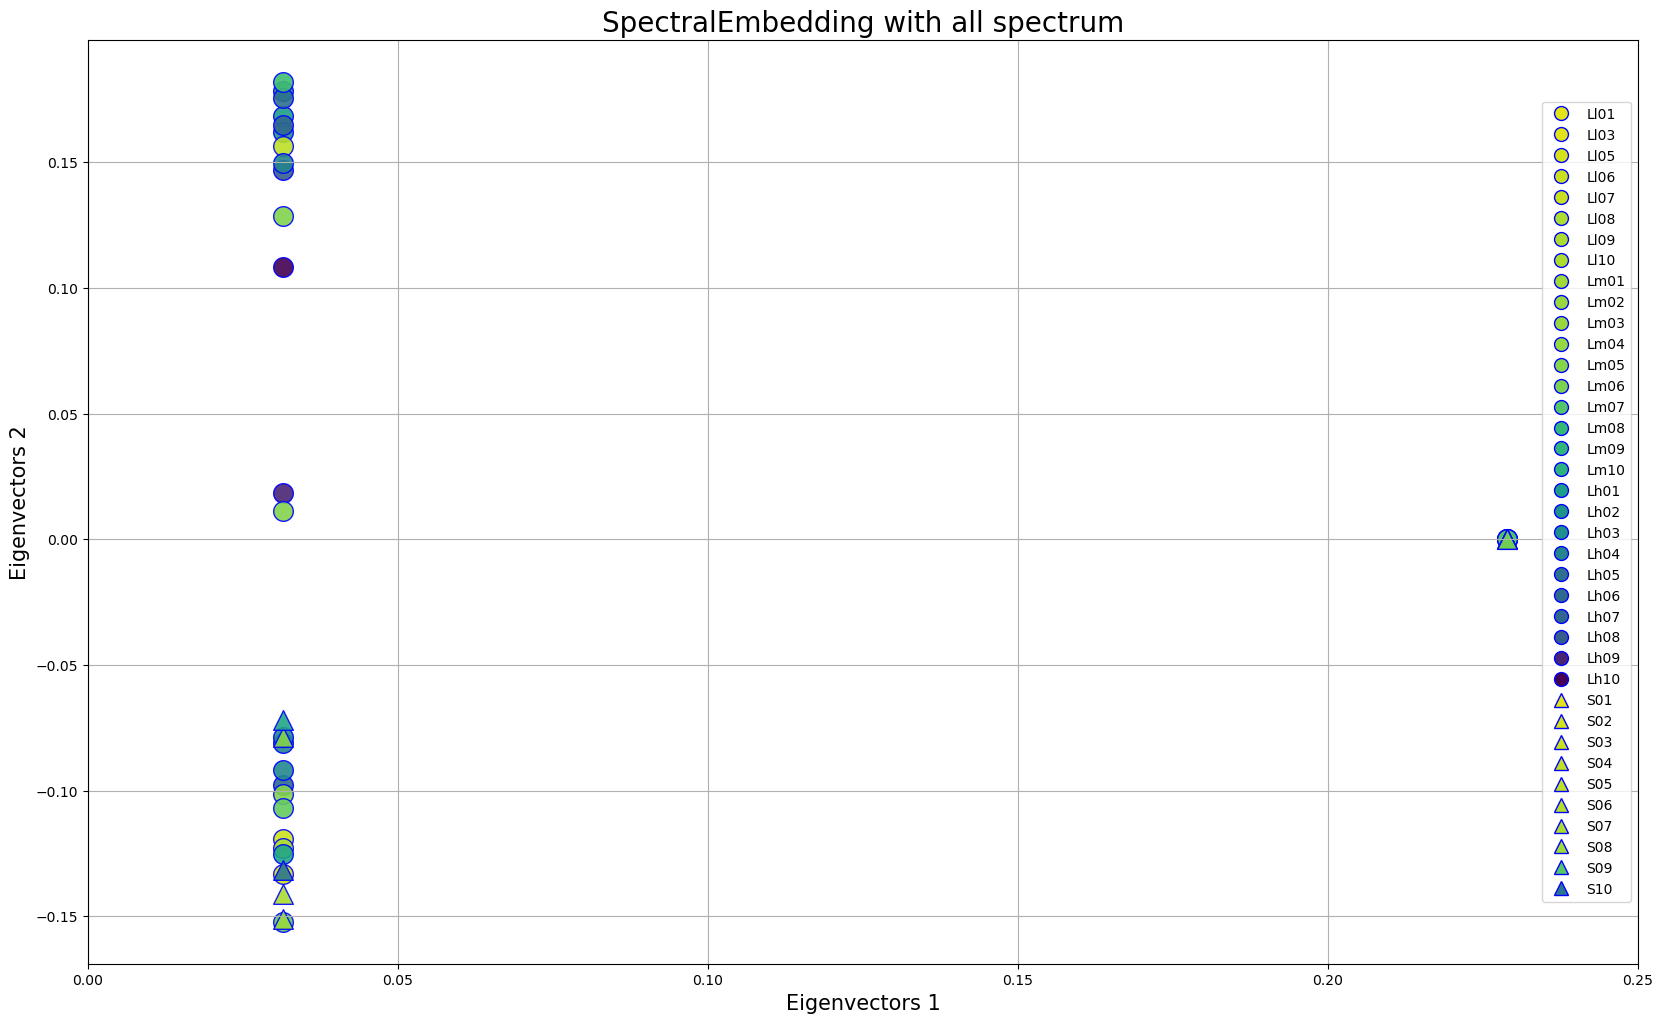

In [29]:
# 画图
# SpectralEmbedding
plt.figure(figsize=(20,12))
plt.xlim(0,0.25)
plt.grid()

# 颜色设置
cmap1=plt.cm.viridis_r
cmap2=plt.cm.Oranges
cmap3=plt.cm.Purples
cmap4=plt.cm.Greens

spec_marker=[]
# digits_str = name_list[0][2:4]
# print(digits_str)
# print(int(digits_str))

for i in range(len(digits_spec)):
    if data_name[i][0]=="L":    # 大麦哲伦云里的
        spec_marker.append("o")
        for j in range(len(name_)):
            if data_name[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    plt.scatter(digits_spec[i, 0], digits_spec[i, 1], s=200,color=color0, label=data_name[i],alpha=0.9,edgecolors=(0,0,1,0.8))
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    plt.scatter(digits_spec[i, 0], digits_spec[i, 1], s=200,color=color0, label=data_name[i],alpha=0.9,edgecolors=(0,0,1,0.8))
                    break
        continue
        
    elif data_name[i][0]=="S":
        spec_marker.append("^")
        for j in range(len(name_)):
            if data_name[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    plt.scatter(digits_spec[i, 0], digits_spec[i, 1], s=200,color=color0, label=data_name[i],alpha=0.9,marker="^",edgecolors=(0,0,1,0.8))
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    plt.scatter(digits_spec[i, 0], digits_spec[i, 1], s=200,color=color0, label=data_name[i],alpha=0.9,marker="^",edgecolors=(0,0,1,0.8))
                    break
        continue

color=[]
for i in range(len(name_L)):
    if name_L[j]>=10:
        color.append(cmap1( name_L[i]/max(name_L)))
    elif name_L[j]<10:
        color.append(cmap1( name_L[j]/15))

# 使用循环生成句柄列表
handles = []
for cat, color, marker in zip(name_, color, spec_marker):
    handle = Line2D(
        [], [], 
        color=color, 
        marker=marker, 
        linestyle="None",  # 无连线
        markersize=10, 
        label=cat,
        markeredgecolor="blue"
    )
    handles.append(handle)

# new_texts = [plt.text(x_, y_ ,text, fontsize=12) for x_, y_,text in zip(digits_spec[:, 1], digits_spec[:, 2],data_name)]
# adjust_text(new_texts,arrowprops=dict(arrowstyle='->',color='red',lw=1))
#plt.legend(loc="right")
#plt.savefig('./picture/SpectralEmbedding(Blues)(38).png')
plt.legend(handles=handles, loc="center right")
plt.title("SpectralEmbedding with all spectrum",fontsize=20)
plt.xlabel("Eigenvectors 1",fontsize=15)
plt.ylabel("Eigenvectors 2",fontsize=15)
plt.savefig('./picture/SpectralEmbedding(viridis)(HCO+).png')
plt.show()

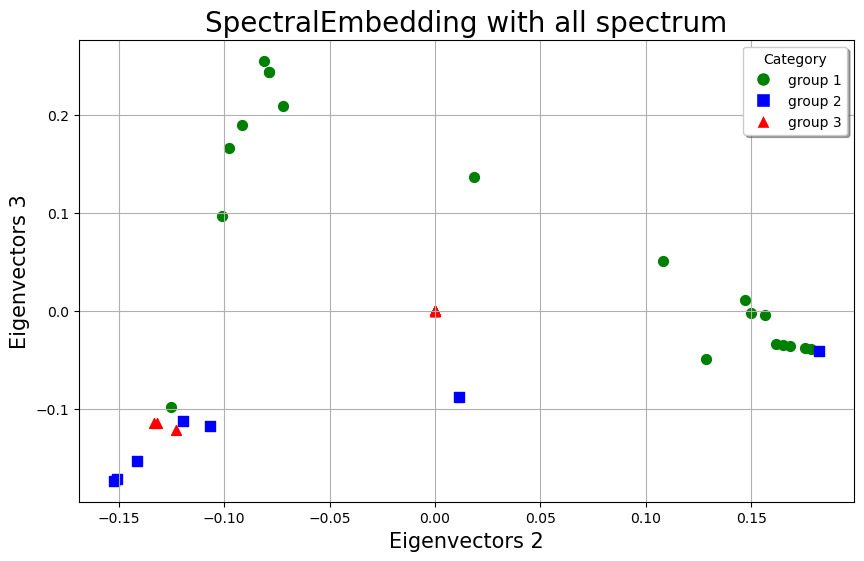

In [34]:
# 与CO的结果进行比较
file_path_color = "data_with_colors(2).txt"

# 假设文件格式：
# 列名: ID   Vsys   RA    Dec
# 数据: 001  250.3  12.5  30.0
# 注释行以 '#' 开头

df_color = pd.read_csv(
    file_path_color,
    sep='\s+',          # 按空格/制表符分隔
    comment='#',        # 忽略注释行
    header=0,           # 第一行为列名
    #names=['ID', 'Vsys', 'RA', 'Dec']  # 可选：手动指定列名
)

# print(df_color) 
na=df_color["name"].tolist()
col=df_color["color"].tolist()
mar=df_color["marker"].tolist()
# print(na)
# print(col)
fig, ax = plt.subplots(figsize=(10,6))
plt.grid()


for i in range(len(digits_spec)):
    count=0
    for j in range(len(na)):
        if name_list[i*5]==na[j]:
            color0=col[j]
            #print(color0)
            ax.scatter(digits_spec[i, 1], digits_spec[i, 2],color=color0,s=50,marker=mar[j] ,label=name_list[i])
            count=1
            break
    if count==0:
        ax.scatter(digits_spec[i, 1], digits_spec[i, 2],color="black",s=50, label=name_list[i],marker="p")
        
        
# 手动创建图例条目
legend_elements = [
    plt.Line2D([], [], marker='o', color='w', markerfacecolor='green', markersize=10, label='group 1'),
    plt.Line2D([], [], marker='s', color='w', markerfacecolor='blue', markersize=10, label='group 2'),
    plt.Line2D([], [], marker='^', color='w', markerfacecolor='red', markersize=10, label='group 3'),
   # plt.Line2D([], [], marker='p', color='w', markerfacecolor='black', markersize=10, label='secondary sources')
]
plt.legend(handles=legend_elements, title="Category", fontsize=10,frameon=True,shadow=True,)

plt.title("SpectralEmbedding with all spectrum",fontsize=20)
plt.xlabel("Eigenvectors 2",fontsize=15)
plt.ylabel("Eigenvectors 3",fontsize=15)
plt.savefig('./picture/SpectralEmbedding(all)(compareCO).png')
plt.show()

In [35]:
# PCA
data_flux=np.array(data_flux)
print(data_flux.shape)
model = PCA(10)  # project from  to 2 dimensions
model.fit(data_flux)
digits_pca = model.transform(data_flux)

(38, 16328)


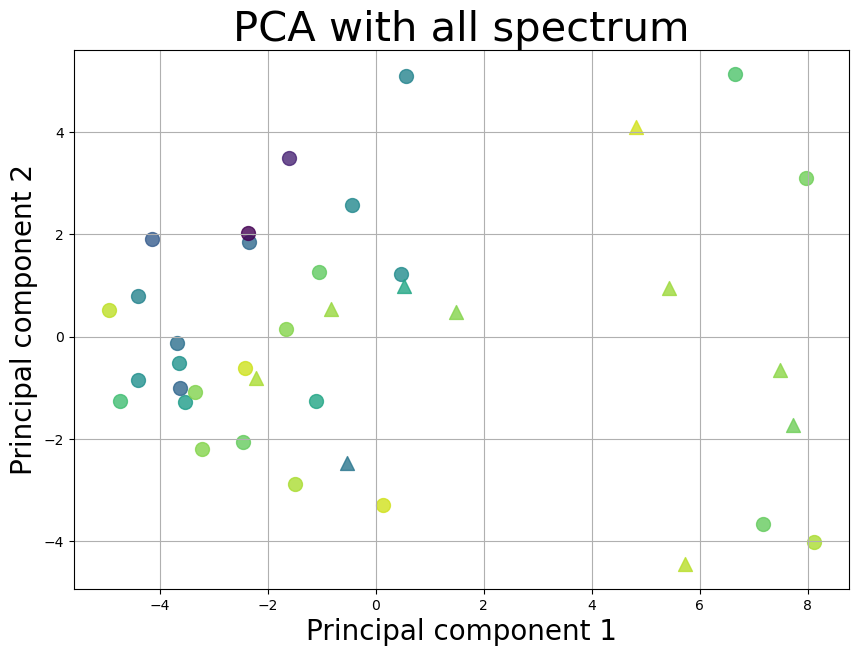

In [42]:
# PCA画图
plt.figure(figsize=(10,7))
plt.grid()
for i in range(len(digits_pca)):
    if data_name[i][0]=="L":    # 大麦哲伦云里的
        for j in range(len(name_)):
            if data_name[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    plt.scatter(digits_pca[i, 0], digits_pca[i, 1], s=100,color=color0, label=data_name[i],alpha=0.8)
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    plt.scatter(digits_pca[i, 0], digits_pca[i, 1], s=100,color=color0, label=data_name[i],alpha=0.8)
                    break
        continue
        
    elif data_name[i][0]=="S":
        for j in range(len(name_)):
            if data_name[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    plt.scatter(digits_pca[i, 0], digits_pca[i, 1], s=100,color=color0, label=data_name[i],alpha=0.8,marker="^")
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    plt.scatter(digits_pca[i, 0], digits_pca[i, 1], s=100,color=color0, label=data_name[i],alpha=0.8,marker="^")
                    break
        continue
    
# new_texts = [plt.text(x_, y_, text, fontsize=12) for x_, y_, text in zip(digits_pca[:, 0], digits_pca[:, 1], data_name)]
# adjust_text(new_texts,arrowprops=dict(arrowstyle='->',color='red',lw=1))
#plt.legend()
plt.title("PCA with all spectrum",fontsize=30)
plt.xlabel("Principal component 1",fontsize=20)
plt.ylabel("Principal component 2",fontsize=20)
plt.savefig('./picture/pca(viridis)(38).png')
plt.show()



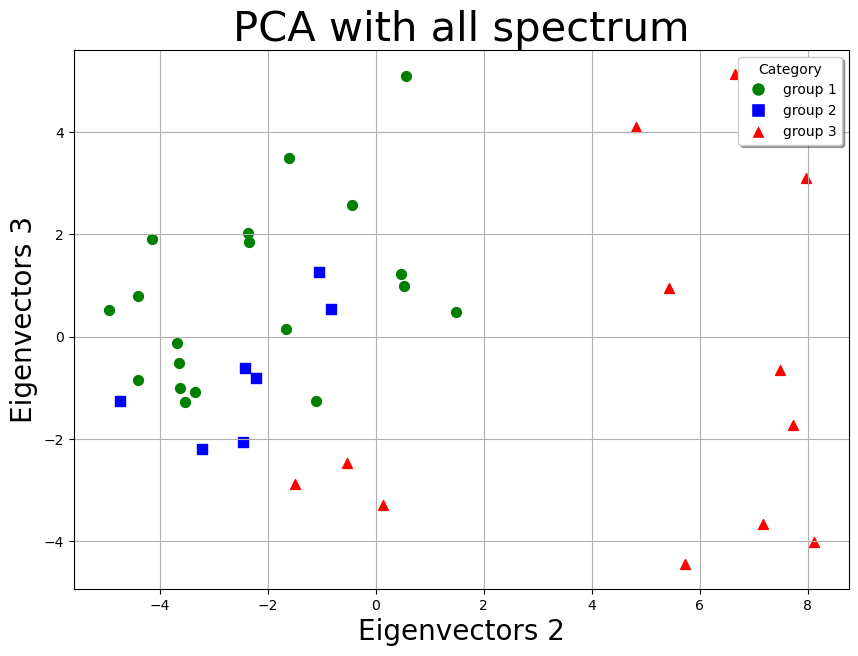

In [41]:
fig, ax = plt.subplots(figsize=(10,7))
plt.grid()

for i in range(len(digits_spec)):
    count=0
    for j in range(len(na)):
        if name_list[i*5]==na[j]:
            color0=col[j]
            #print(color0)
            ax.scatter(digits_pca[i, 0], digits_pca[i, 1],color=color0,s=50,marker=mar[j] ,label=name_list[i])
            count=1
            break


# 手动创建图例条目
legend_elements = [
    plt.Line2D([], [], marker='o', color='w', markerfacecolor='green', markersize=10, label='group 1'),
    plt.Line2D([], [], marker='s', color='w', markerfacecolor='blue', markersize=10, label='group 2'),
    plt.Line2D([], [], marker='^', color='w', markerfacecolor='red', markersize=10, label='group 3'),
   # plt.Line2D([], [], marker='p', color='w', markerfacecolor='black', markersize=10, label='secondary sources')
]
plt.legend(handles=legend_elements, title="Category", fontsize=10,frameon=True,shadow=True,)

plt.title("PCA with all spectrum",fontsize=30)
plt.xlabel("Eigenvectors 2",fontsize=20)
plt.ylabel("Eigenvectors 3",fontsize=20)
plt.savefig('./picture/PCA(all)(compareCO).png')
plt.show()

In [29]:
import pandas as pd

# 假设文件格式：
# 列名: ID   Vsys   RA    Dec
# 数据: 001  250.3  12.5  30.0
# 注释行以 '#' 开头

df_outflow = pd.read_csv(
    "C:\\Users\\zyx\\Desktop\\data\\all_outflow.txt",
    sep='\s+',          # 按空格/制表符分隔
    #comment='#',        # 忽略注释行
    header=0,           # 第一行为列名
    #names=['ID', 'Vsys', 'RA', 'Dec']  # 可选：手动指定列名
)

ccc=df_outflow.iloc[:, 0].tolist()   # df.head()则默认输出前五行数据，在数据量大的时候可以方便检查
name_outflow=[]
print(len(ccc))
for i in range(len(ccc)):
    if i*4<len(ccc):
        ddd=ccc[i*4][1::]
        name_outflow.append(ddd)
    else:
        break
print(name_outflow)
print(len(name_outflow))

148
['Ll01', 'Ll03', 'Ll05', 'Ll06', 'Ll07', 'Ll08', 'Ll09', 'Ll10', 'Lm01', 'Lm02', 'Lm04', 'Lm05', 'Lm07', 'Lm08', 'Lm09', 'Lm10', 'Lh01_1', 'Lh01_2', 'Lh02', 'Lh03', 'Lh04', 'Lh05_1', 'Lh05_2', 'Lh06', 'Lh07', 'Lh08', 'Lh09', 'Lh10', 'S01', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10']
37


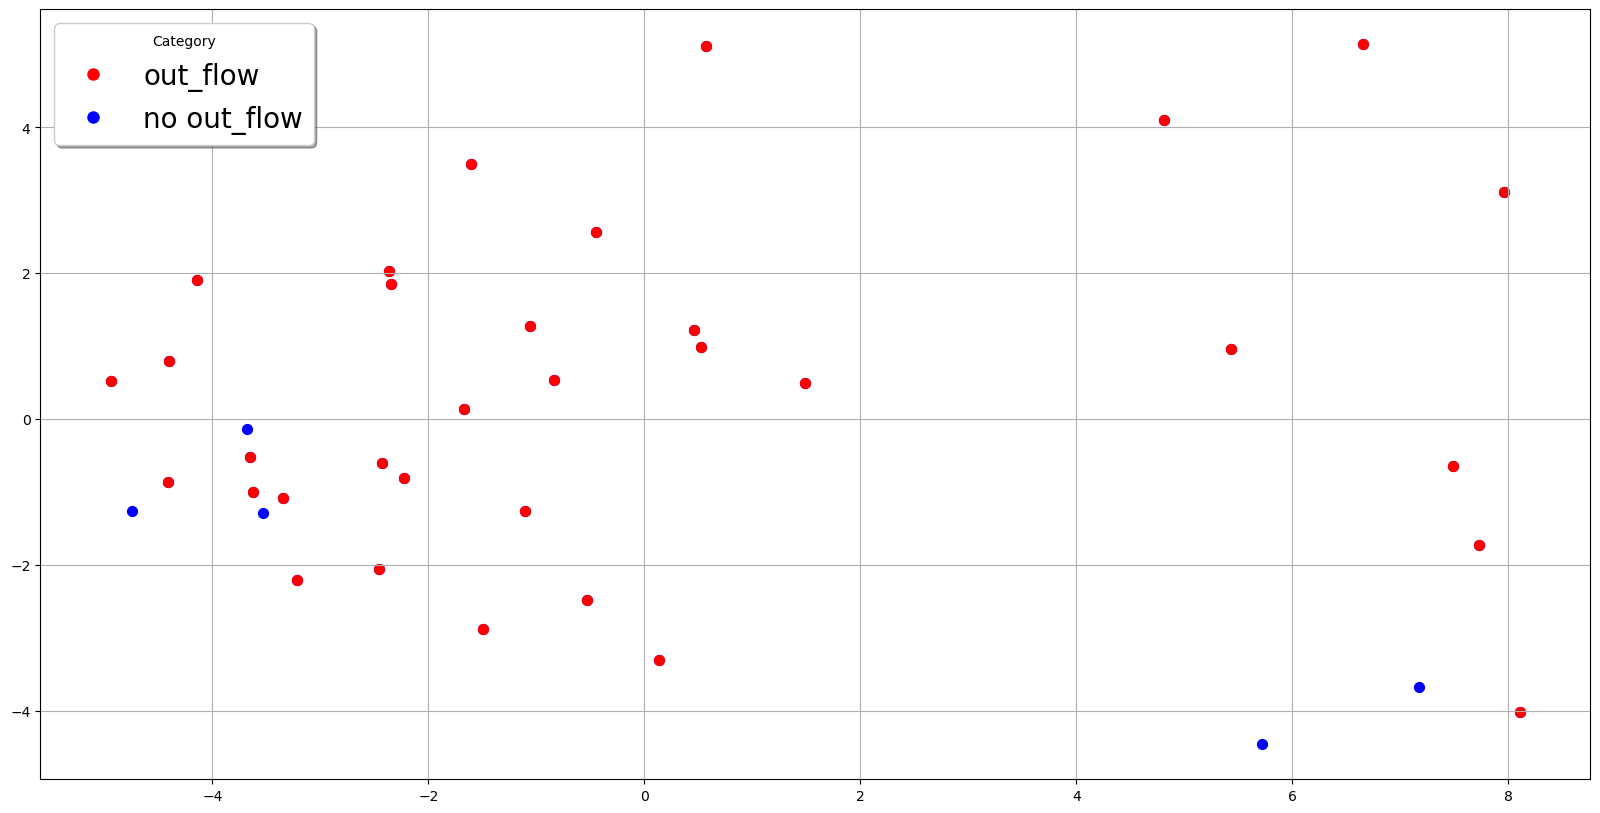

In [30]:
fig, ax = plt.subplots(figsize=(20,10))
ax.grid()
for i in range(len(digits_spec)):
    ax.scatter(digits_pca[i, 0], digits_pca[i, 1],color="Blue",s=50, label=name_list[i])
    for j in range(len(name_outflow)):
        if name_list[i*5]==name_outflow[j]:
            color0="Red"
            #print(color0)
            ax.scatter(digits_pca[i, 0], digits_pca[i, 1],color=color0,s=50, label=name_list[i*5])
            break
            
# 手动创建图例条目
legend_elements = [
    plt.Line2D([], [], marker='o', color='w', markerfacecolor='red', markersize=10, label='out_flow'),
    plt.Line2D([], [], marker='o', color='w', markerfacecolor='blue', markersize=10, label='no out_flow')
]

# 添加自定义图例
plt.legend(handles=legend_elements, title="Category", fontsize=20,frameon=True,shadow=True,)
#ax.legend(loc=1,ncol=2)
plt.show()

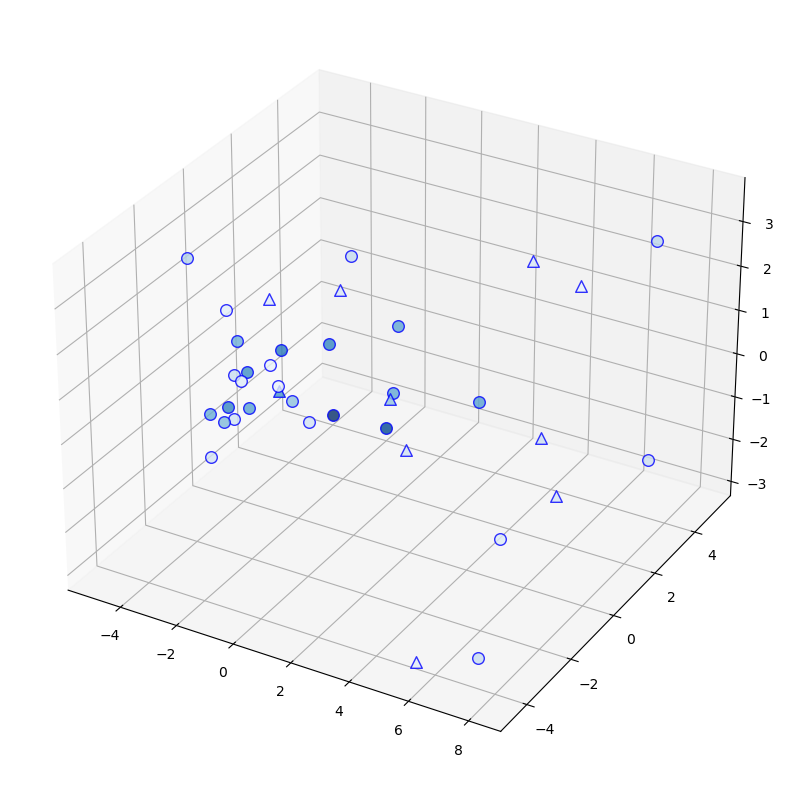

In [31]:
plt.figure(figsize=(10,10))
ax2 = plt.axes(projection='3d')
for i in range(len(digits_pca)):
    if data_name[i][0]=="L":    # 大麦哲伦云里的
        for j in range(len(name_)):
            if data_name[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    ax2.scatter3D(digits_pca[i, 0], digits_pca[i, 1],digits_pca[i, 2], s=70,color=color0, label=data_name[i],alpha=0.8,edgecolors=(0,0,1,0.8))
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    ax2.scatter3D(digits_pca[i, 0], digits_pca[i, 1],digits_pca[i, 2],  s=70,color=color0, label=data_name[i],alpha=0.8,edgecolors=(0,0,1,0.8))
                    break
        continue
        
    elif data_name[i][0]=="S":
        for j in range(len(name_)):
            if data_name[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    ax2.scatter3D(digits_pca[i, 0], digits_pca[i, 1], digits_pca[i, 2], s=70,color=color0, label=data_name[i],alpha=0.8,marker="^",edgecolors=(0,0,1,0.8))
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    ax2.scatter3D(digits_pca[i, 0], digits_pca[i, 1],digits_pca[i, 2],  s=70,color=color0, label=data_name[i],alpha=0.8,marker="^",edgecolors=(0,0,1,0.8))
                    break
        continue
    
# new_texts = [plt.text(x_, y_, text, fontsize=12) for x_, y_, text in zip(digits_pca[:, 0], digits_pca[:, 1], data_name)]
# adjust_text(new_texts,arrowprops=dict(arrowstyle='->',color='red',lw=1))
#plt.legend()
# plt.title("PCA")
# plt.xlabel("Principal component 1")
# plt.ylabel("Principal component 2")
#plt.savefig('./picture/pca(Blues)(38).png')
plt.show()

In [44]:
# 导入所有谱线的信息
file_path = "spectrum_data.txt"

# 假设文件格式：
# 列名: ID   Vsys   RA    Dec
# 数据: 001  250.3  12.5  30.0
# 注释行以 '#' 开头

df_spectrum = pd.read_csv(
    file_path,
    sep='\s+',          # 按空格/制表符分隔
    #comment='#',        # 忽略注释行
    header=0,           # 第一行为列名
    #names=['ID', 'Vsys', 'RA', 'Dec']  # 可选：手动指定列名
)

# print(df_color) 
spectrum_name=df_spectrum["name"].tolist()
spectrum_fre=df_spectrum["rest_frequency"].tolist()
spectrum_color=df_spectrum["color"].tolist()
print(spectrum_name)
print(spectrum_fre)
print(spectrum_color)

['HC15N', '34SO2', 'SO', 'CH3OCH3', 'CH3OH', 'CH3OCH3', '34SO2', '34SO2', 't-HCOOH', 'SO2', 'CO', 'CH3OH', 'SO', 'SO2', 't-HCOOH', 'H13CO+', 'SiO', 'HCO+', 'SO2', '34SO2', 'SO2', 'SO2', 'SO2', 'CH3OCH3', 'SO2', 'SO2', 'SO2', 'SO2', 'SO2', 'SO2', 'SO2', 'SO2', 'CH3OCH3', 'CH3OH', '34SO2', 'SO2']
[344.2003199, 344.2453476, 344.310612, 344.3580659, 344.443433, 344.5153801, 344.581045, 344.8079157, 345.030561, 345.3385391, 345.7959899, 346.202719, 346.528481, 346.6521672, 346.718858, 346.998344, 347.330631, 356.734223, 356.7551893, 357.1021822, 357.16536, 357.24119, 357.38757, 357.4602017, 357.5814483, 357.67178, 357.892442, 357.92596, 357.96289, 358.01309, 358.03808, 358.21564, 358.4519426, 358.605799, 358.9879745, 359.7706815]
['red', 'green', 'orange', 'green', 'green', 'green', 'green', 'green', 'green', 'orange', 'red', 'green', 'orange', 'red', 'green', 'green', 'orange', 'orange', 'red', 'green', 'red', 'red', 'red', 'green', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', '

主成分（特征向量）：
 [[-2.87838457e-04 -4.30154557e-04 -1.58246245e-04 ...  1.39702220e-03
   1.32045871e-03 -0.00000000e+00]
 [ 6.82535347e-04  1.02000161e-03  3.75240533e-04 ... -2.17977128e-03
  -2.06030941e-03  0.00000000e+00]
 [ 9.73831144e-04  1.45532293e-03  5.35387535e-04 ... -3.76410246e-03
  -3.55781168e-03  0.00000000e+00]
 ...
 [-4.28772073e-04 -6.40770047e-04 -2.35727954e-04 ...  3.96799778e-03
   3.75053256e-03  0.00000000e+00]
 [ 7.42138776e-05  1.10907479e-04  4.08008979e-05 ... -8.95705430e-04
  -8.46616497e-04  0.00000000e+00]
 [ 1.25590917e-04  1.87686893e-04  6.90466845e-05 ... -1.73559890e-03
  -1.64047980e-03 -0.00000000e+00]]
解释方差（每个主成分的贡献）： [0.52960721 0.17393453 0.07865388 0.04648874 0.03802877 0.02210238
 0.0193655  0.01328339 0.00893208 0.00838709 0.00710425 0.00567698
 0.00524854 0.00460999 0.00425133 0.00388259 0.00334648 0.0030808
 0.00254698 0.00249256 0.00236146 0.00213672 0.00183296 0.00160392
 0.00139333 0.00126439 0.00121626 0.00115078 0.00106122]


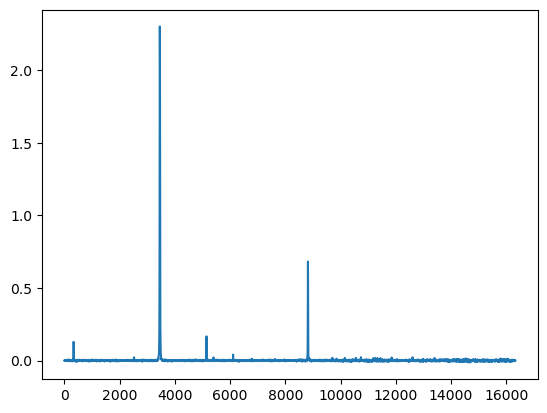

In [45]:
# 5. 输出PCA的主成分和解释方差
print("主成分（特征向量）：\n", model.components_)
print("解释方差（每个主成分的贡献）：", model.explained_variance_ratio_)
component=model.components_
ratio=model.explained_variance_ratio_
mean=model.mean_
plt.plot(mean)
plt.show()

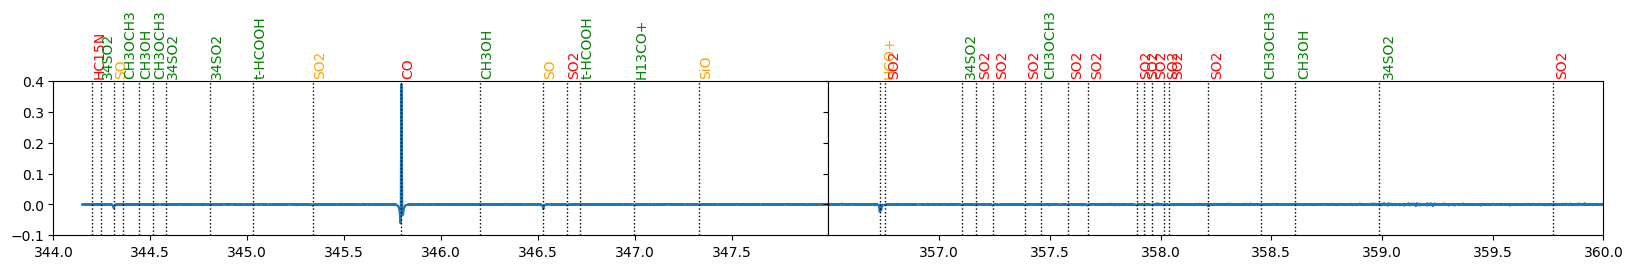

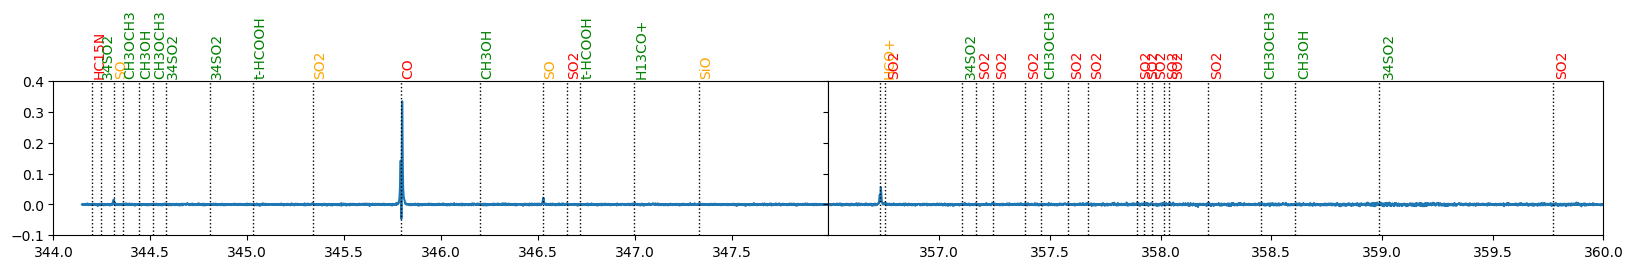

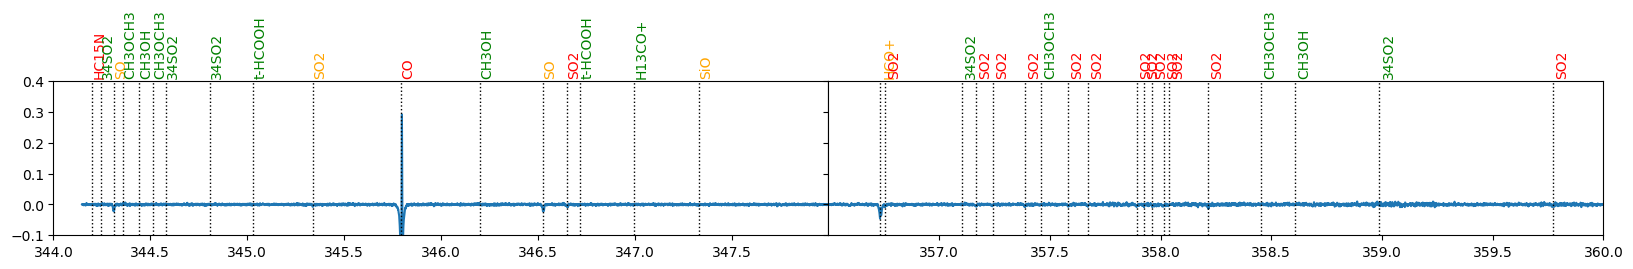

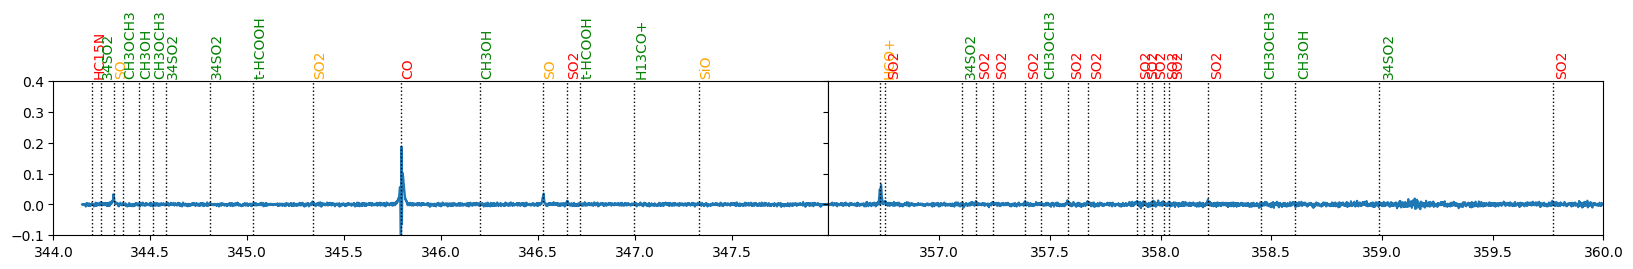

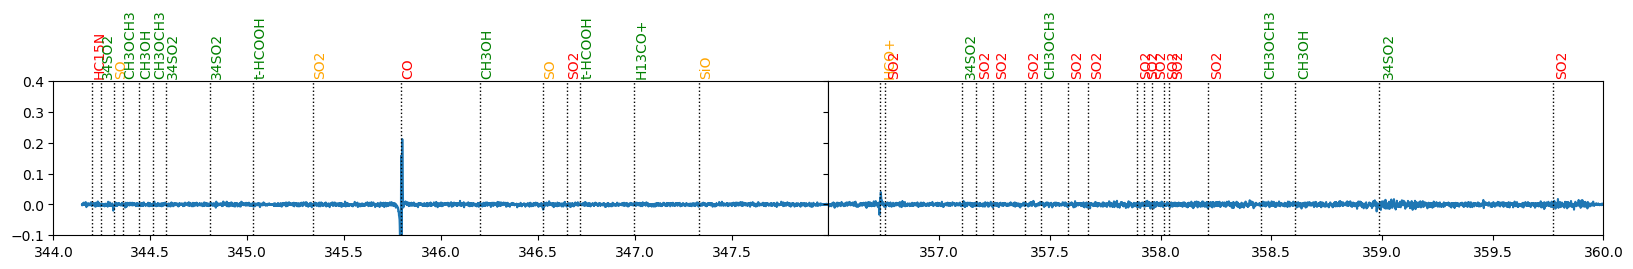

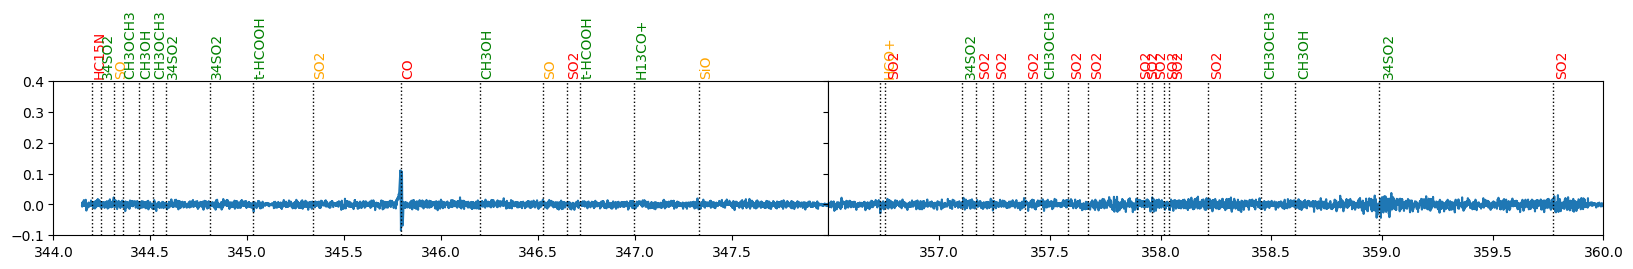

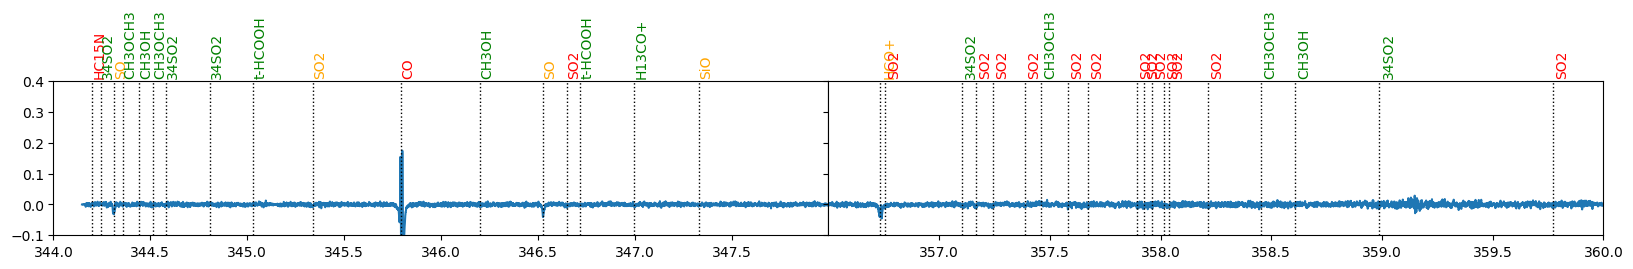

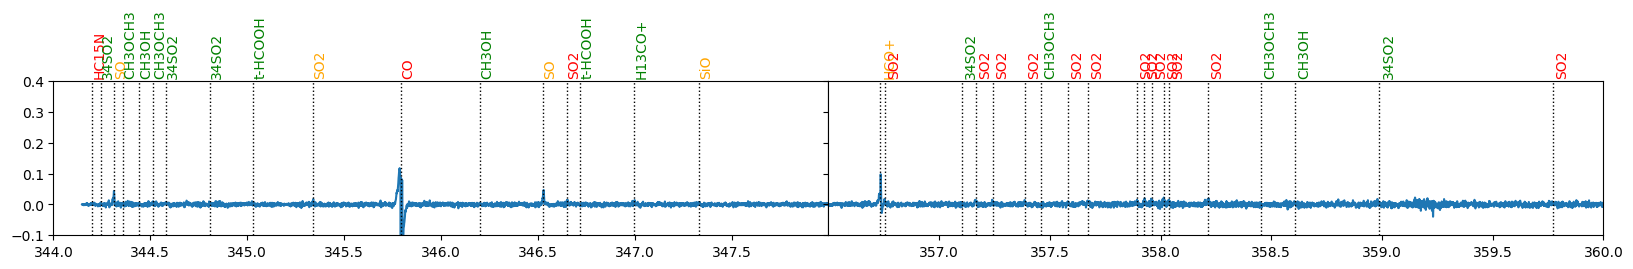

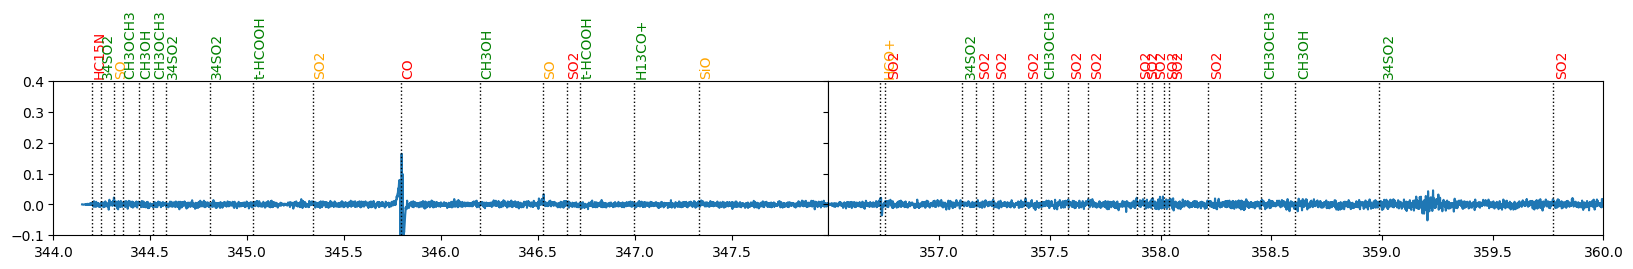

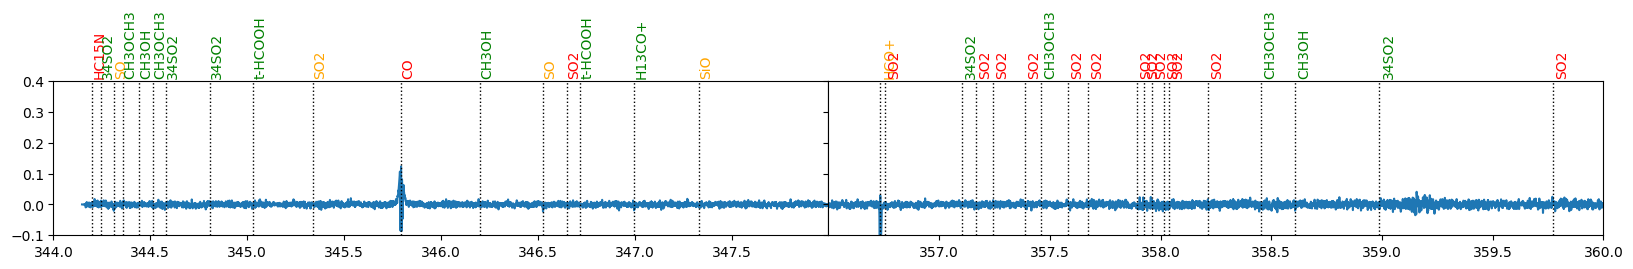

In [46]:
for i in range(10):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 2), gridspec_kw={'wspace': 0},  # 水平间距设为0
                                sharey=True)  # 共享Y轴
    ax1.set_ylim(-0.1, 0.4)
    ax2.set_ylim(-0.1, 0.4)
            
    # 左侧子图
    ax1.plot(data_x[i], component[i])
    ax1.set_xlim(344,348)
    xticks_left = ax1.get_xticks()

    ax1.set_xticks(xticks_left[:-1])               # 排除左图最后一个

    #ax1.set_title("LSB")
    for j in range(len(spectrum_name)):
        if spectrum_fre[j]<348:
            ax1.axvline(x=spectrum_fre[j], color="black", linestyle=":", linewidth=1)
            ax1.text(
                spectrum_fre[j],  # 文本X位置（竖线右侧）
                0.41,  # 文本Y位置
                spectrum_name[j], 
                rotation=90,  # 垂直旋转
                color=spectrum_color[j],
                va="bottom"   # 垂直对齐
                )
    
    # 右侧子图
    ax2.plot(data_x[i], component[i])
    ax2.set_xlim(356.5,360)
    xticks_right = ax2.get_xticks()
    
    ax2.set_xticks(xticks_right[1:])               # 排除右图第一个
    
    #ax2.set_title("USB")
    for j in range(len(spectrum_name)):
        if spectrum_fre[j]>356.5:
            ax2.axvline(x=spectrum_fre[j], color="black", linestyle=":", linewidth=1)
            ax2.text(
                spectrum_fre[j]+0.01,  # 文本X位置（竖线右侧）
                0.41,  # 文本Y位置
                spectrum_name[j], 
                rotation=90,  # 垂直旋转
                color=spectrum_color[j],
                va="bottom"   # 垂直对齐
                )
    plt.show()


In [47]:
# for i in range(10):
#     #fig = plt.figure(figsize=(20, 12))
#     plt.ylim(-0.1, 0.4)
#     data_x_new, data_y_new = [], []
#     data_x=np.array(data_x)
#     component=np.array(component)
#     for k in range(len(data_x[0])):
#         if (data_x[i][k] - data_x[i][k-1]) > 1:
#             data_x_new.extend([np.nan, data_x[i][k]])  # 插入NaN断开
#             data_y_new.extend([np.nan, component[i][k]])
#         else:
#             data_x_new.append(data_x[i][k])
#             data_y_new.append(component[i][k])
            
# #     for j in range(len(spectrum_name)):
# #         #if spectrum_fre[j]>356:
# #             plt.axvline(x=spectrum_fre[j], color="black", linestyle=":", linewidth=1)
# #             plt.text(
# #                 spectrum_fre[j]+0.01,  # 文本X位置（竖线右侧）
# #                 0.41,  # 文本Y位置
# #                 spectrum_name[j], 
# #                 rotation=90,  # 垂直旋转
# #                 color=spectrum_color[j],
# #                 va="bottom"   # 垂直对齐
# #                 )
#     plt.plot(data_x_new,data_y_new)
#     plt.show()

In [ ]:
# 尝试合成大谱线
# difference1=[]
# difference2=[]
# difference3=[]
# for i in range(len(digits_pca)):  # 第i根谱线的预测
#     predic1=digits_pca[i,0]*ratio[0]*component[0]+digits_pca[i,1]*ratio[1]*component[1]+digits_pca[i,2]*ratio[2]*component[2]
#     predic2=(digits_pca[i,0]*ratio[0]*component[0]+digits_pca[i,1]*ratio[1]*component[1]+digits_pca[i,2]*ratio[2]*component[2]
#              +digits_pca[i,3]*ratio[3]*component[3])
#     predic3=(digits_pca[i,0]*ratio[0]*component[0]+digits_pca[i,1]*ratio[1]*component[1]+digits_pca[i,2]*ratio[2]*component[2]
#              +digits_pca[i,3]*ratio[3]*component[3]+digits_pca[i,4]*ratio[4]*component[4])
#     sum1=0
#     sum2=0
#     sum3=0
    
#     for j in range(len(predic1)):   #第i根谱线长为j，把所有点的差值求出来
#         sum1+=abs(predic1[j]-data_flux[i][j])
#         sum2+=abs(predic2[j]-data_flux[i][j])
#         sum3+=abs(predic3[j]-data_flux[i][j])
#     difference1.append(sum1)
#     difference2.append(sum2)
#     difference3.append(sum3)
#     print(sum1/sum(data_flux[i]))
# plt.plot(difference1,marker=".",color="blue",label="3")
# plt.plot(difference2,marker=".",color="green",label="4")
# plt.plot(difference3,marker=".",color="orange",label="5")
# plt.show()

digits_reconstructed = digits_pca @ component + mean
mse = np.mean((data_flux - digits_reconstructed) ** 2)
print(f"重建均方误差: {mse}")
x=list(range(0,len(data_flux[0]),1))
for i in range(len(digits_pca)):
    plt.figure(figsize=(20,10))
    plt.plot(data_flux[i],label="initial",color="blue",alpha=0.8)
    plt.plot(digits_reconstructed[i],label="reconstructed",color="red",alpha=0.4)
#     # 标记重叠区域（例如差异小于阈值）
#     threshold = 0.1
#     overlap_mask = np.abs(data_flux[i] - digits_reconstructed[i]) < threshold
#     plt.fill_between(x,data_flux[i], digits_reconstructed[i], where=overlap_mask, color="green", alpha=0.8, label="Overlap Region")

    #plt.ylim(-0.01,0.05)
    plt.legend()
    plt.show()

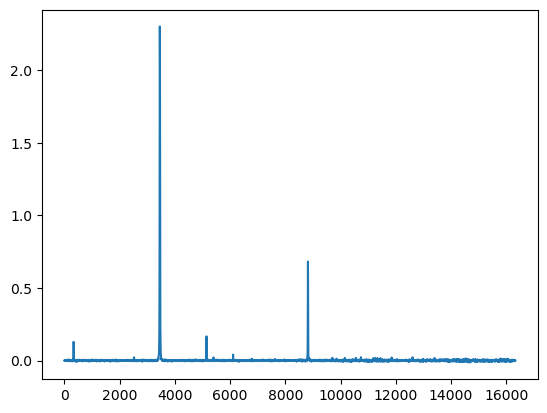

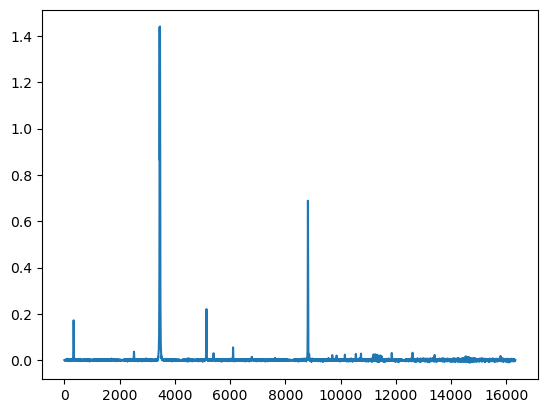

In [35]:
# 重构函数
def reconstruct(n_components):
    return digits_pca[:, :n_components] @ component[:n_components, :] + mean

for i in range(2):
    reconstructed=reconstruct(i)[6]
    plt.plot(reconstructed)
    plt.show()

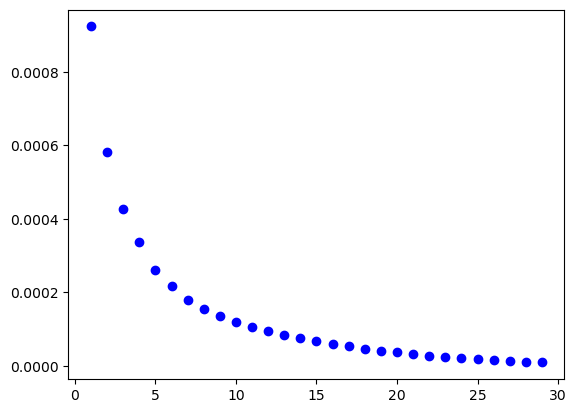

In [36]:
# PCA
for n in range(1,30):
    data_flux=np.array(data_flux)
    model = PCA(n)  # project from  to 2 dimensions
    model.fit(data_flux)
    digits_pca = model.transform(data_flux)
    component=model.components_
    ratio=model.explained_variance_ratio_
    mean=model.mean_
    digits_reconstructed = digits_pca @ component + mean
    mse = np.mean((data_flux - digits_reconstructed) ** 2)
    plt.scatter(n,mse,color="blue")

plt.show()

In [37]:
def noise_sigma(raw_data,a):
    noise=raw_data[a:a+100]   
    plt.plot(noise)
    plt.show()
    return noise

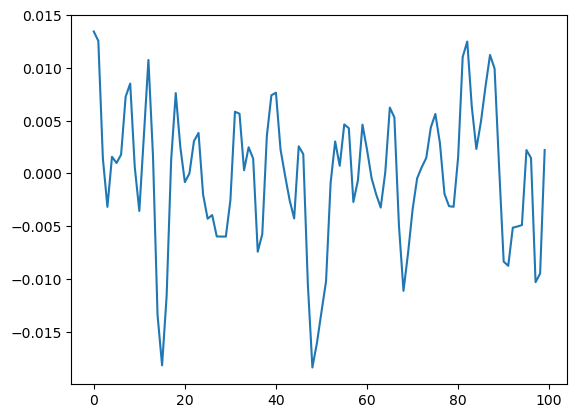

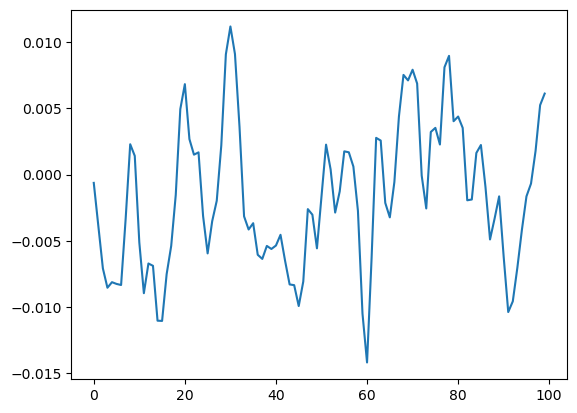

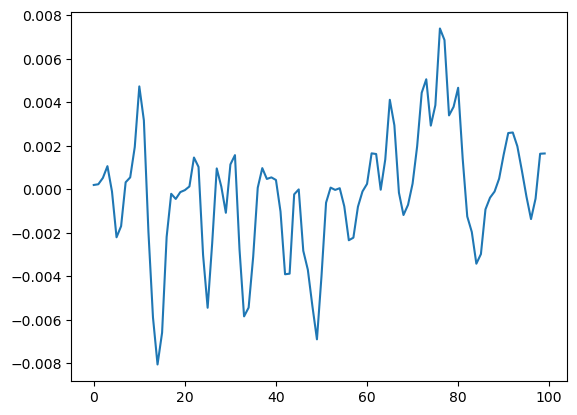

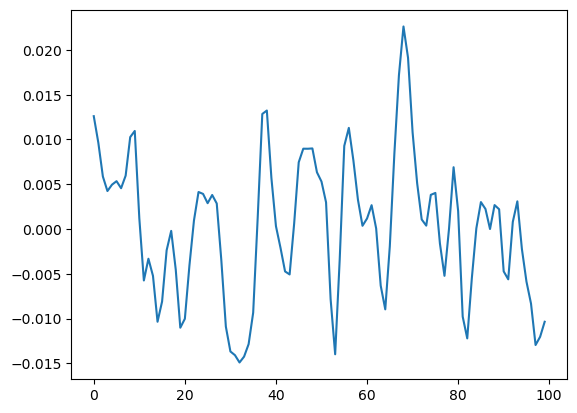

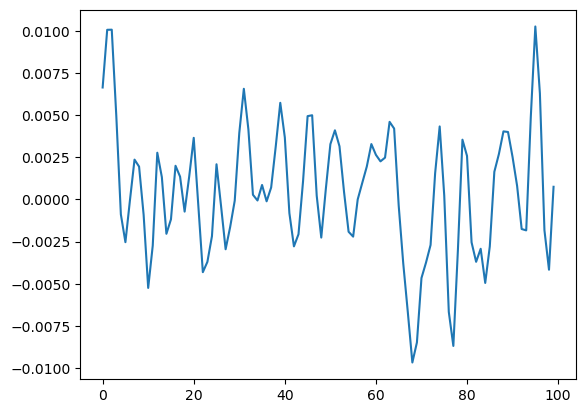

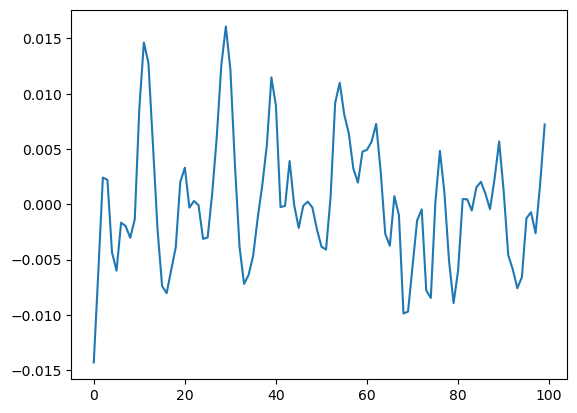

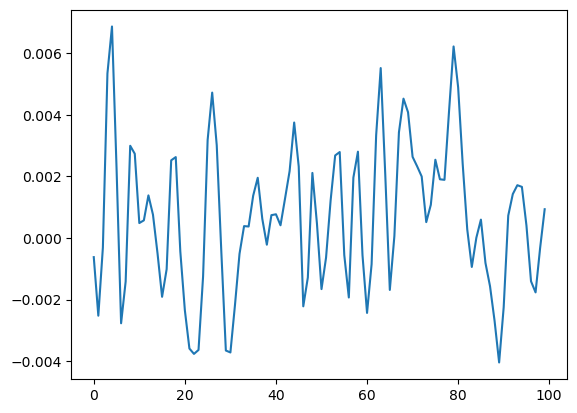

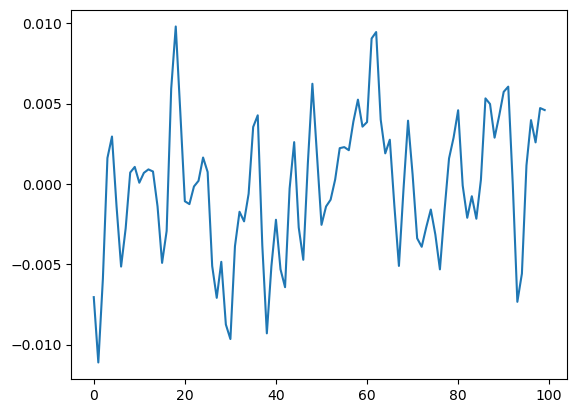

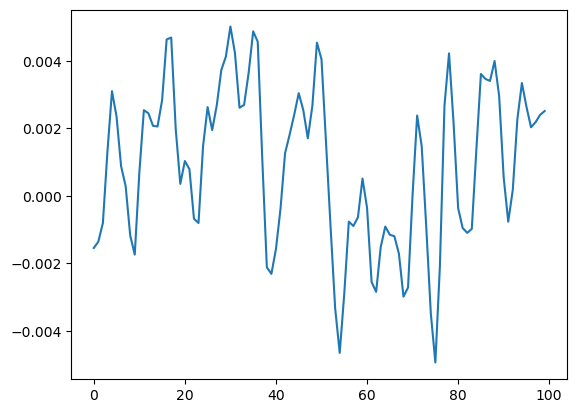

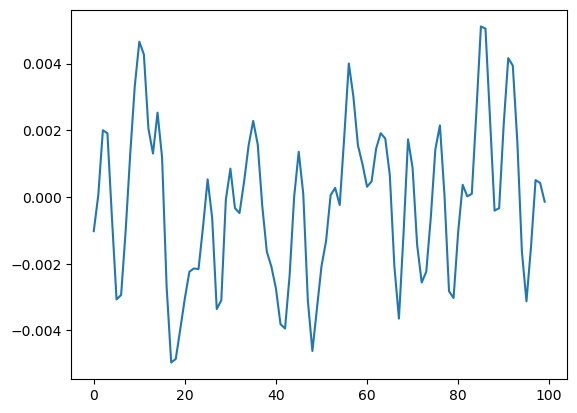

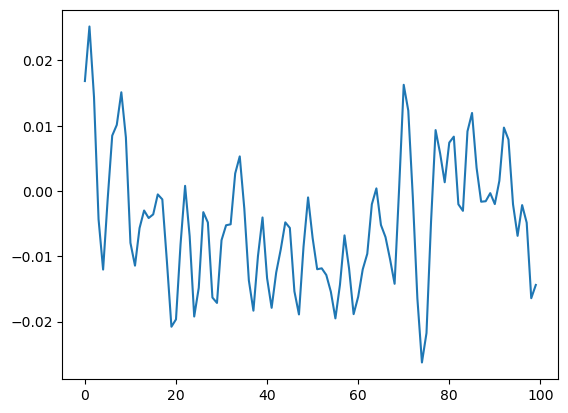

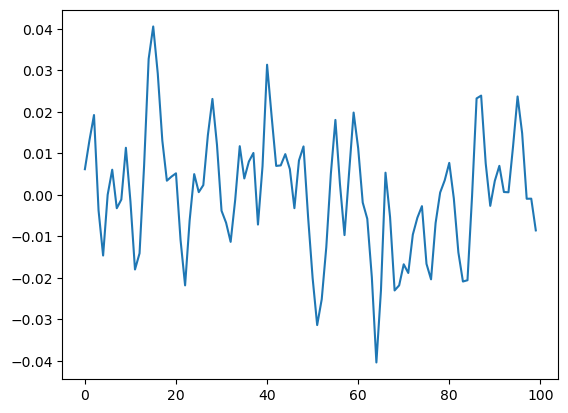

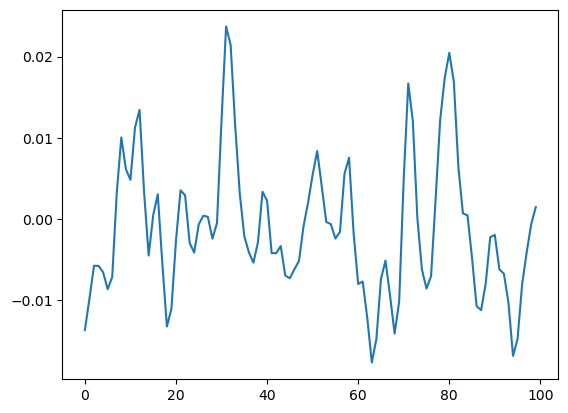

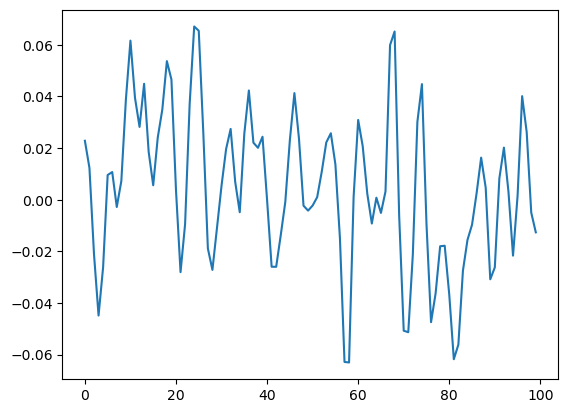

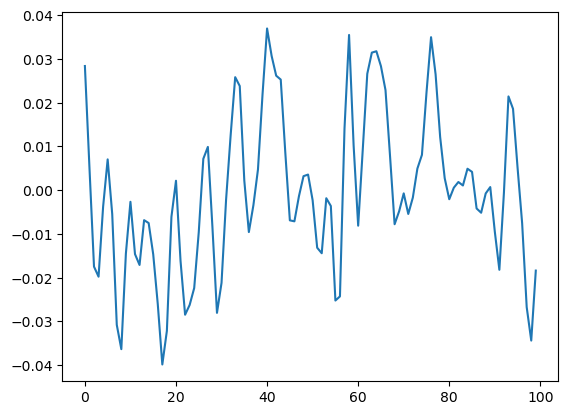

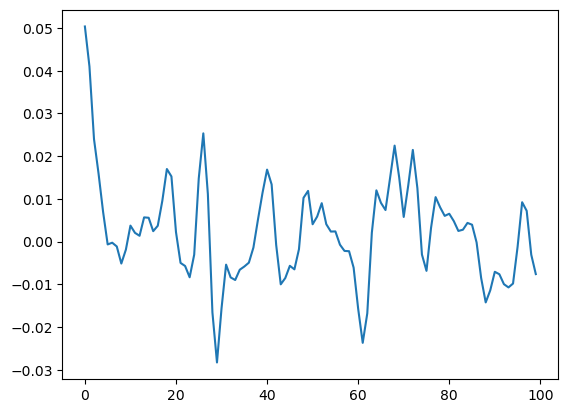

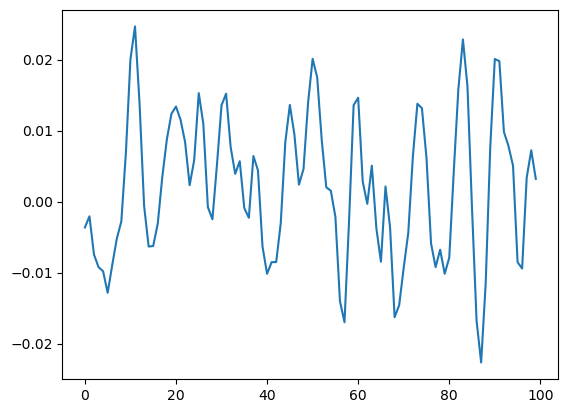

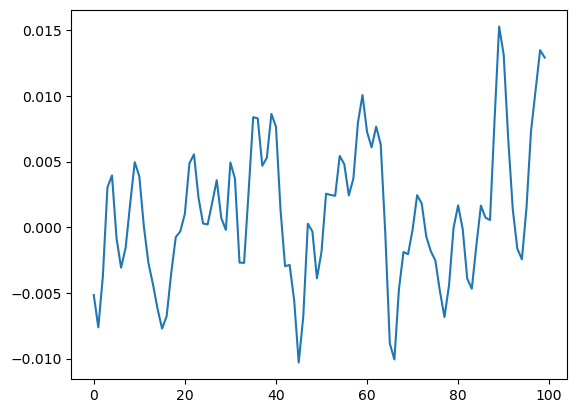

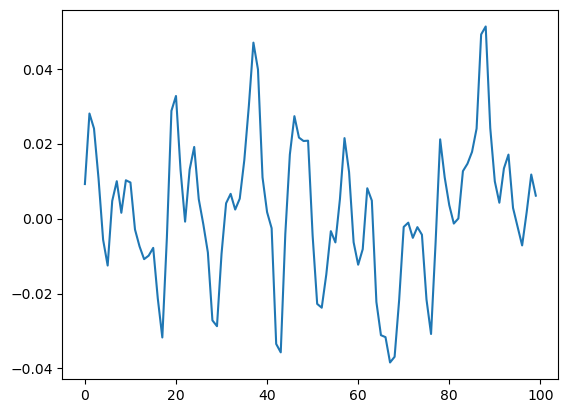

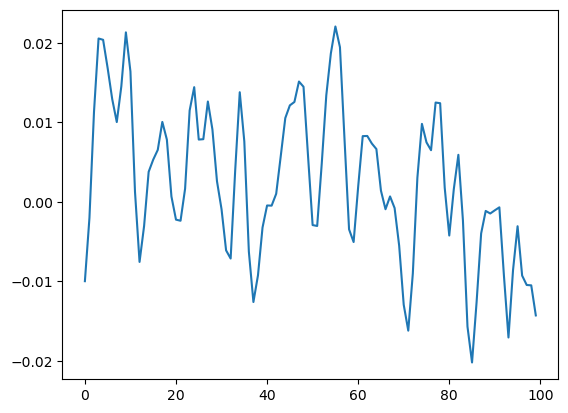

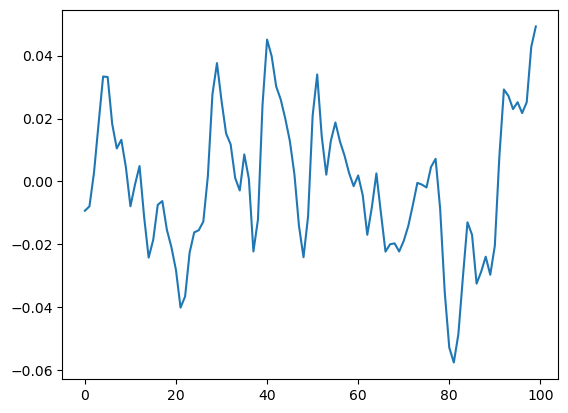

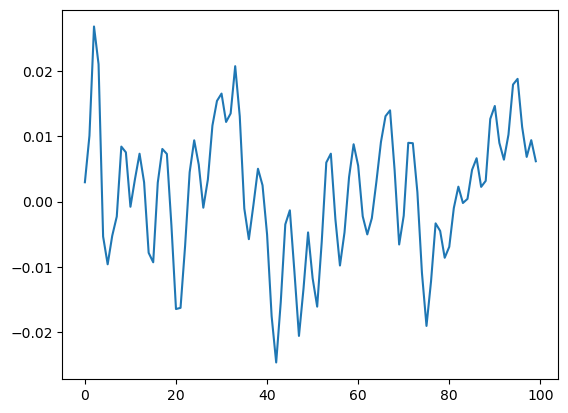

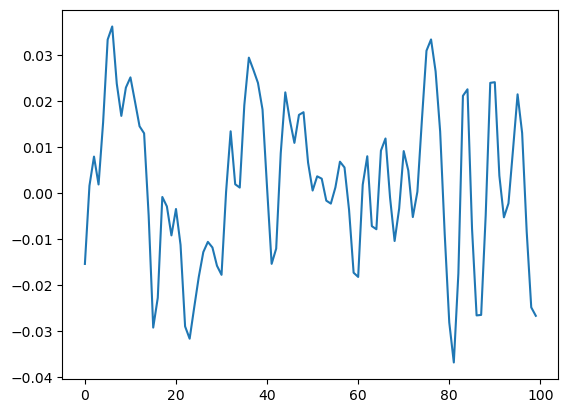

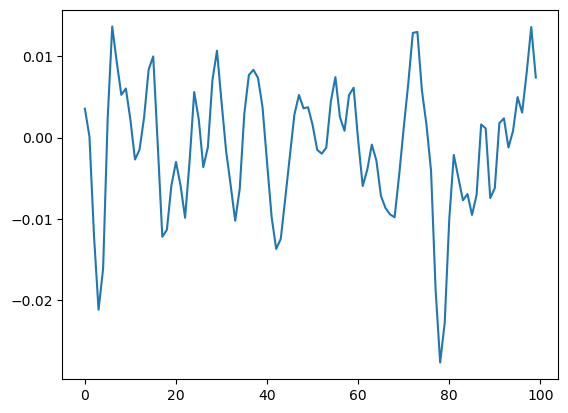

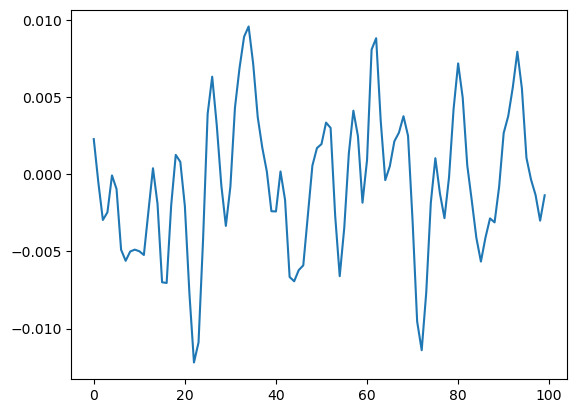

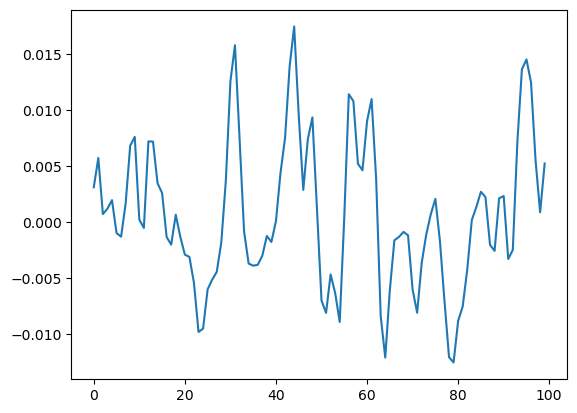

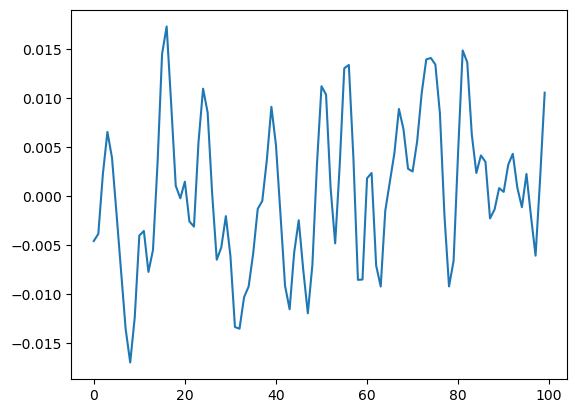

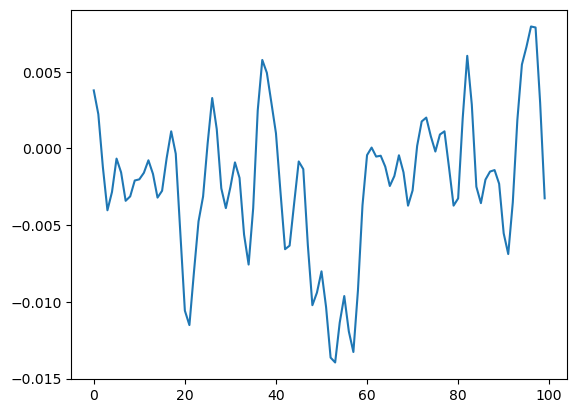

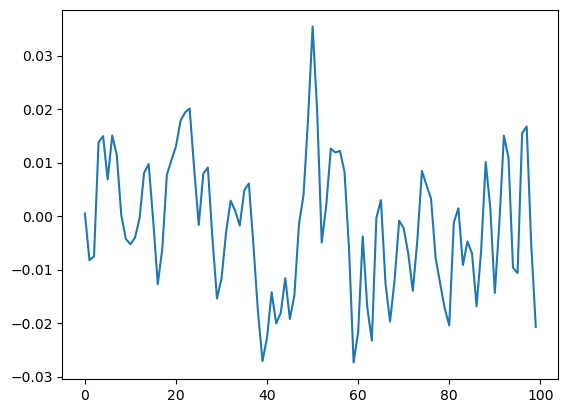

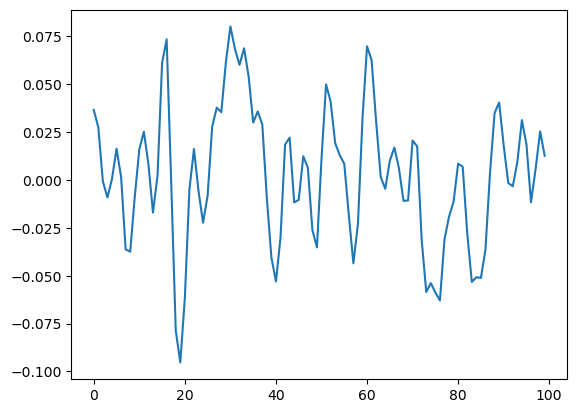

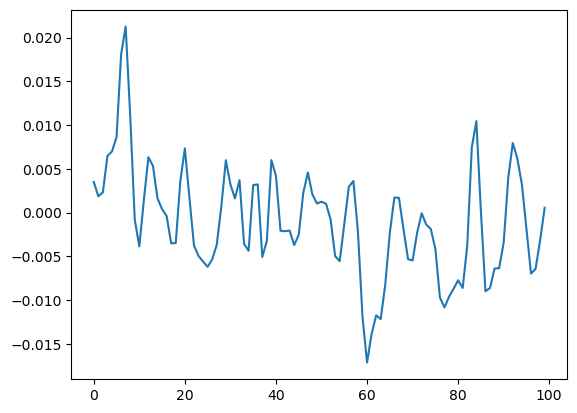

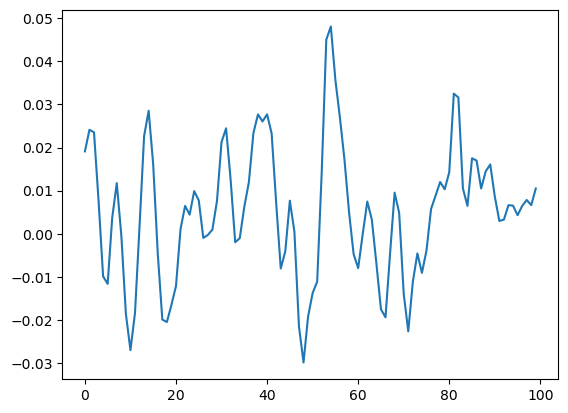

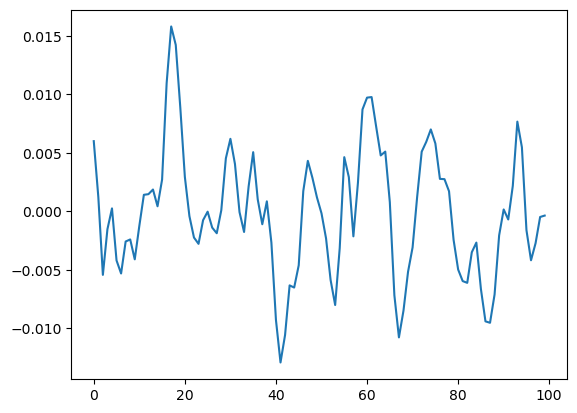

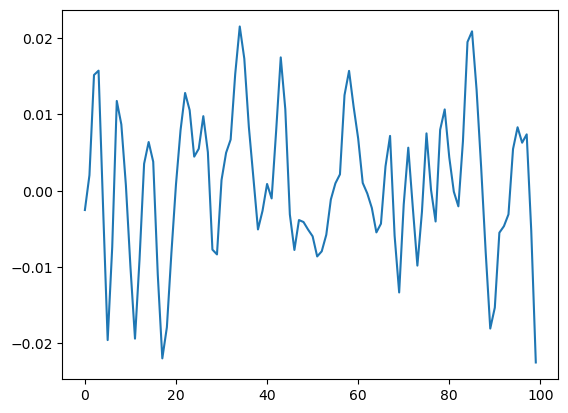

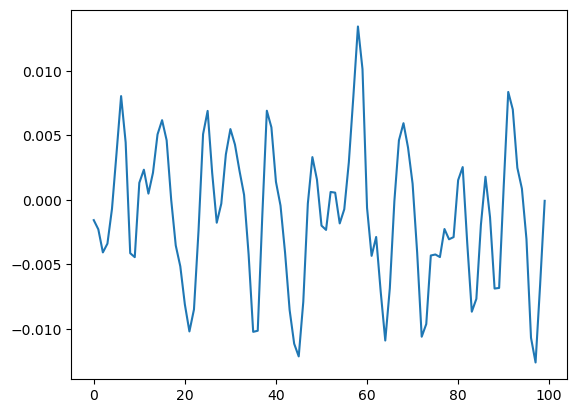

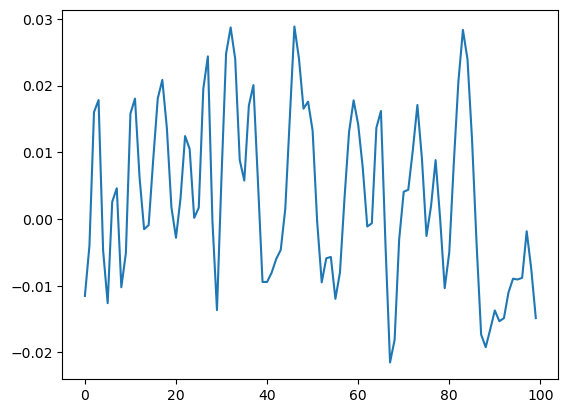

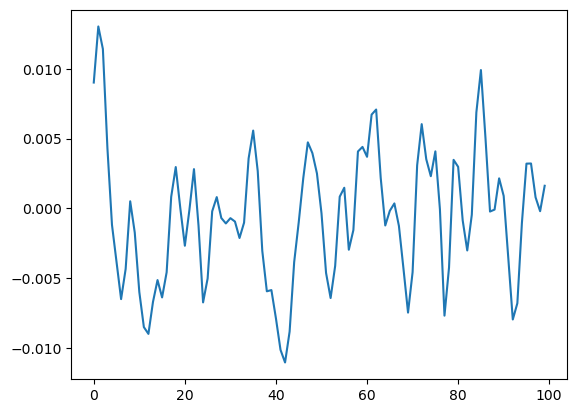

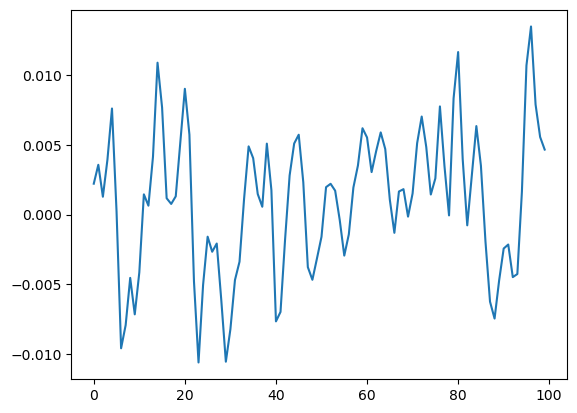

In [38]:
# 计算每一条谱线噪声的σ
noise_list=[]
for i in range(len(data_flux)):
    noise_y=noise_sigma(data_flux[i],1000)
    noise_level=np.std(noise_y)
    noise_list.append(noise_level)
    

In [39]:
# 把CO扣除掉，再降维看看

# 去掉CO数据（把噪声3σ上的删掉）
def remove_3sigma3(list1,list2,noise):
    list3=copy.deepcopy(list2)
#     a=max(list2)
#     n_a=list2.index(a)
    # 检测峰及其突出度
    peaks, properties = find_peaks(list3, prominence=0.8)
    print(peaks)
    left_peak=0
    right_peak=0
    left_peak=list2.index(max(list2))
    right_peak=list2.index(max(list2))
    
    #记录峰宽
    width_left=0
    width_right=0
# # 把左边的降到0以外的都去掉
#     for i in range(left_peak-1,-1,-1):
#         if  list3[i]<=0:
#             print("去除噪声（左边）")
#             for j in range(i+1):
#                 list3[j]=0
#             break
# # 把右边的降到0以外的都去掉
#     for i in range( right_peak,len(list3)):
#         if list3[i]<=0:
#             print("去除噪声（右边）")
#             for j in range(i,len(list3)):
#                 list3[j]=0
#             break
    print(len(list3))
# 从最大值开始往左边找
    for i in range(left_peak-1,-1,-1):
        if list3[i]<noise*3:
            print("去除峰值（左边）")
            width_left=i
            for j in range(i,left_peak):
                list3[j]=0
            break
# 从最大值开始往右边找
    for i in range( right_peak,len(list3)):
        if list3[i]<noise*3 :
            width_right=i
            print("去除峰值（右边）")
            for j in range(right_peak,i):
                list3[j]=0
            break
    return list3,width_right-width_left

[3452]
16328
去除峰值（左边）
去除峰值（右边）


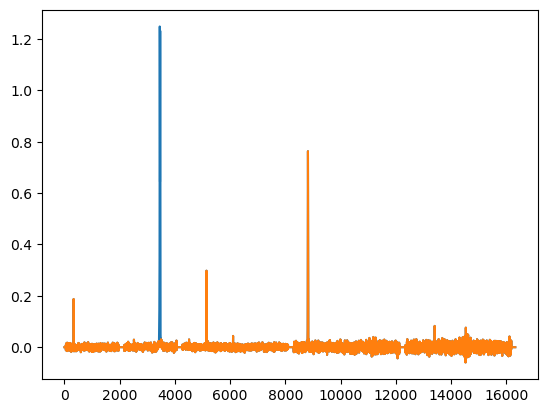

[3462]
16328
去除峰值（左边）
去除峰值（右边）


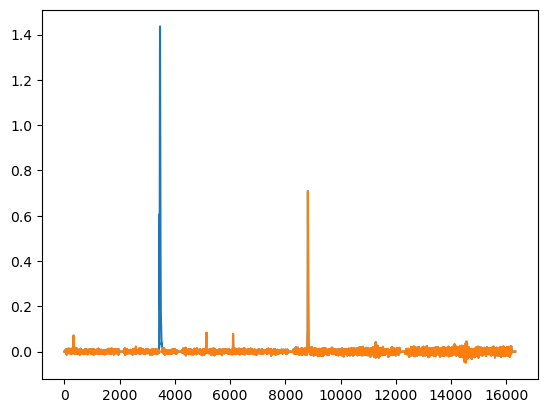

[3451]
16328
去除峰值（左边）
去除峰值（右边）


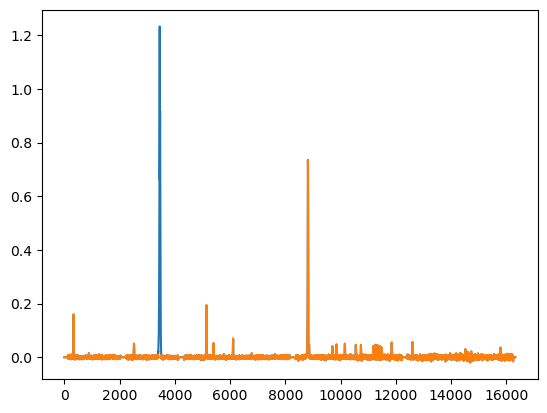

[3450 8820]
16328
去除峰值（左边）
去除峰值（右边）


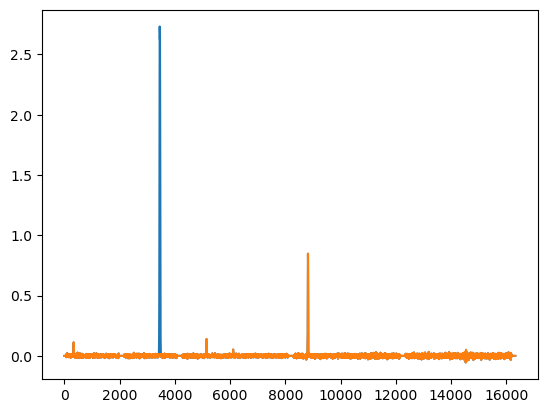

[3465 8824]
16328
去除峰值（左边）
去除峰值（右边）


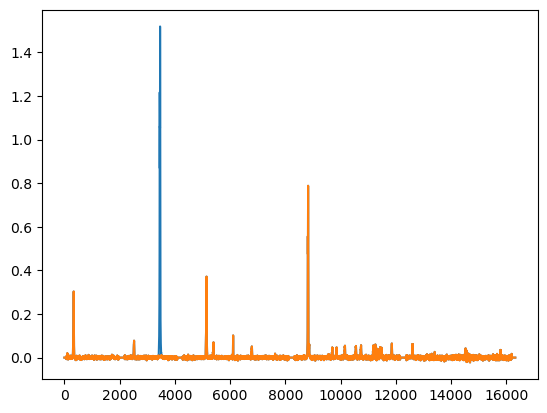

[3464 8821]
16328
去除峰值（左边）
去除峰值（右边）


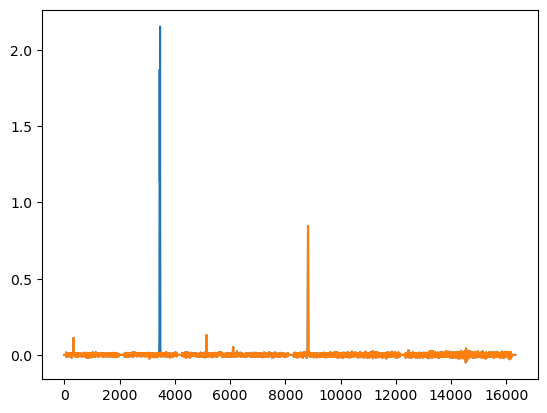

[3452]
16328
去除峰值（左边）
去除峰值（右边）


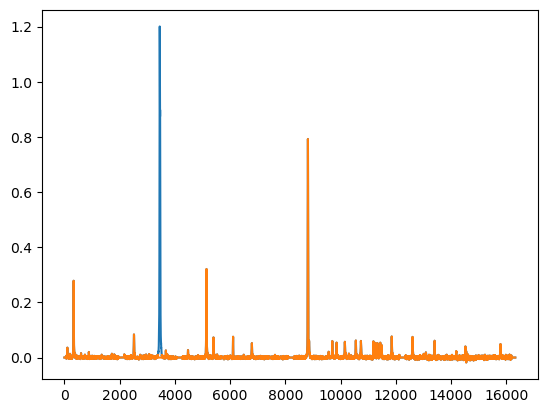

[3448 3460 8814]
16328
去除峰值（左边）
去除峰值（右边）


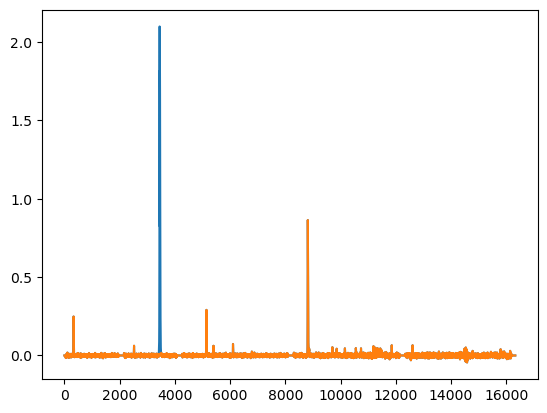

[3455 8820]
16328
去除峰值（左边）
去除峰值（右边）


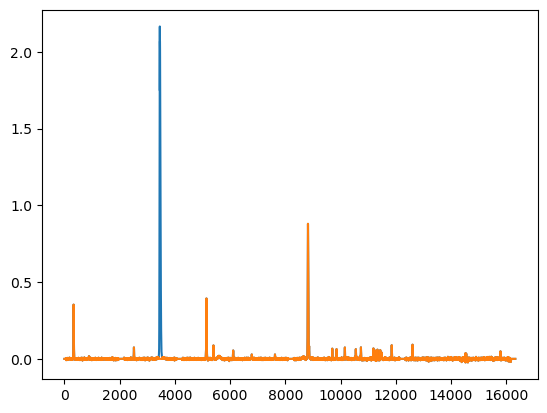

[3457 8821]
16328
去除峰值（左边）
去除峰值（右边）


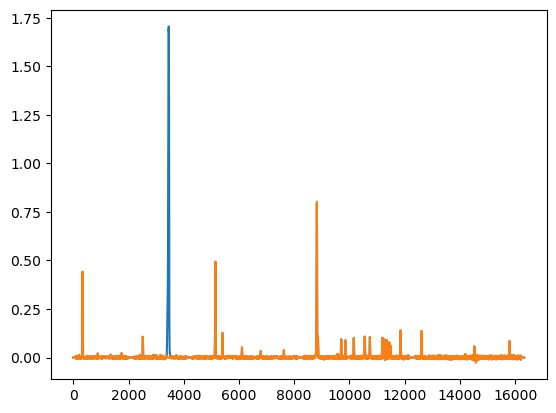

[3457]
16328
去除峰值（左边）
去除峰值（右边）


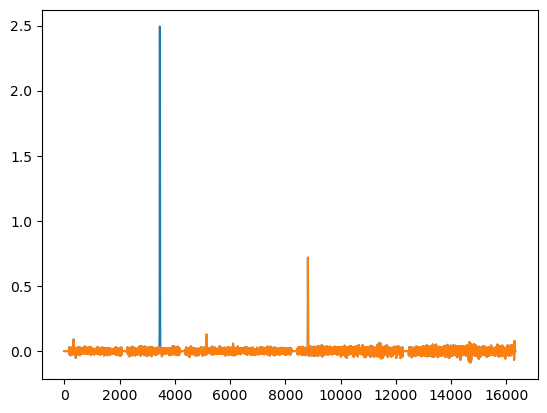

[3451 3462]
16328
去除峰值（左边）
去除峰值（右边）


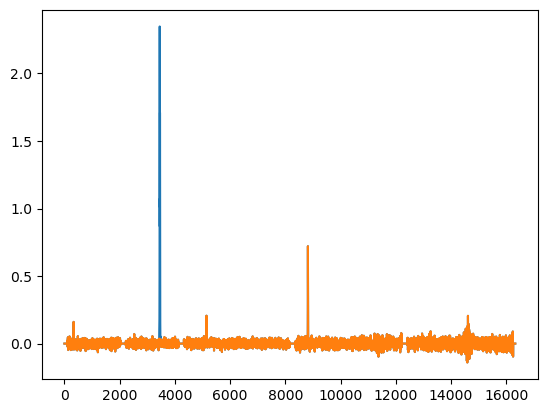

[3449 3462]
16328
去除峰值（左边）
去除峰值（右边）


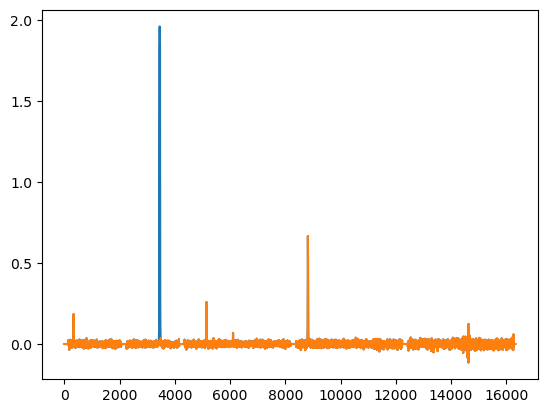

[3456]
16328
去除峰值（左边）
去除峰值（右边）


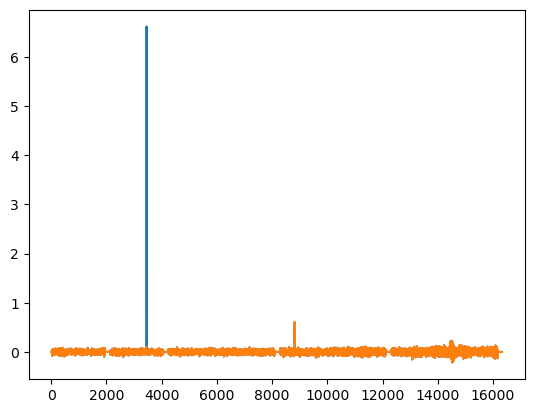

[3452 3459 8819]
16328
去除峰值（左边）
去除峰值（右边）


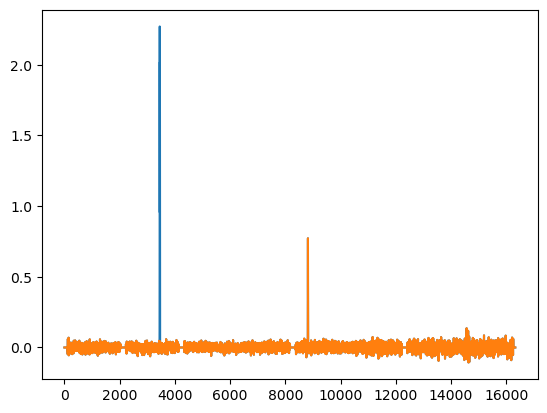

[3454]
16328
去除峰值（左边）
去除峰值（右边）


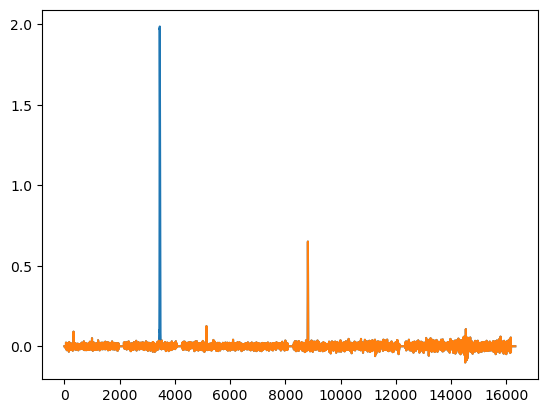

[3451]
16328
去除峰值（左边）
去除峰值（右边）


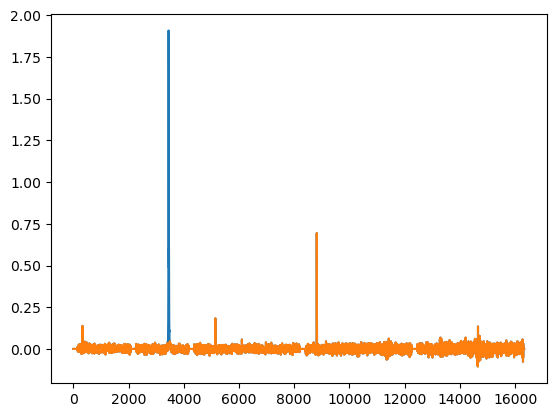

[3453]
16328
去除峰值（左边）
去除峰值（右边）


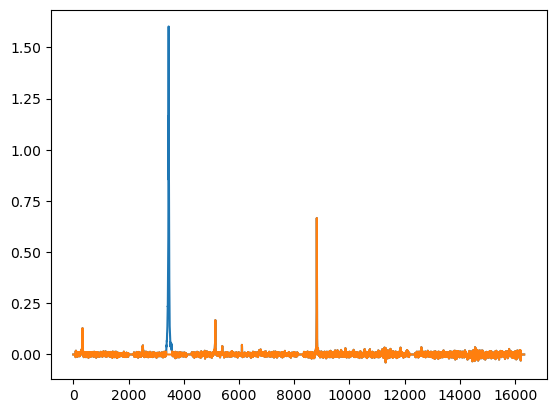

[3454 8819]
16328
去除峰值（左边）
去除峰值（右边）


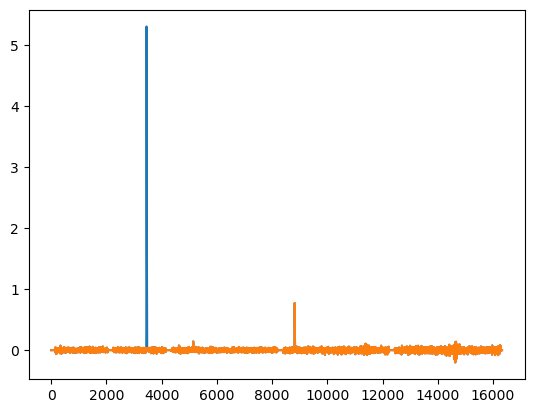

[3451]
16328
去除峰值（左边）
去除峰值（右边）


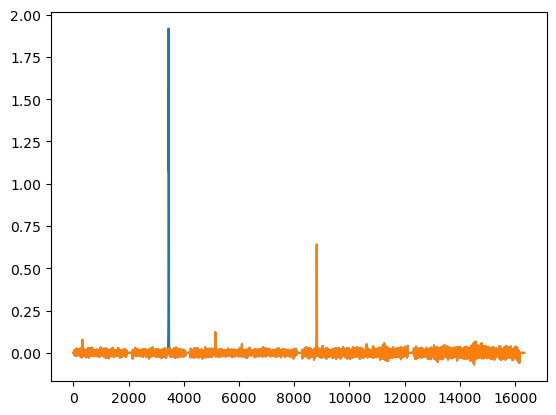

[3455 8819]
16328
去除峰值（左边）
去除峰值（右边）


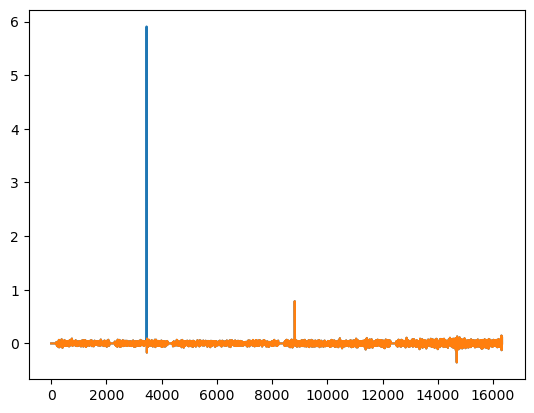

[3462]
16328
去除峰值（左边）
去除峰值（右边）


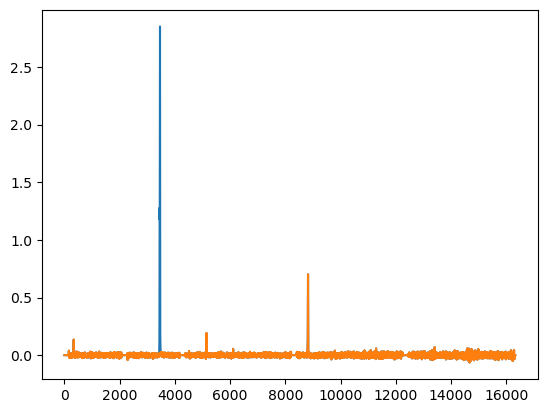

[3462 8821]
16328
去除峰值（左边）
去除峰值（右边）


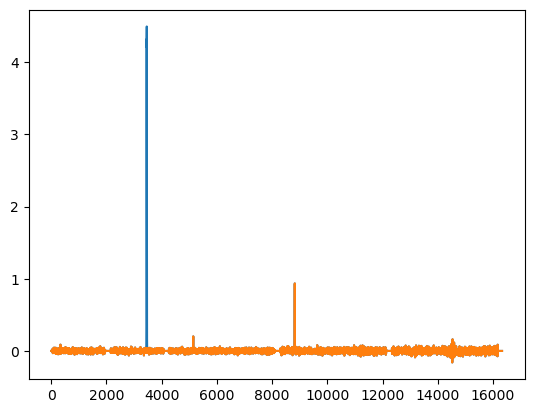

[3464]
16328
去除峰值（左边）
去除峰值（右边）


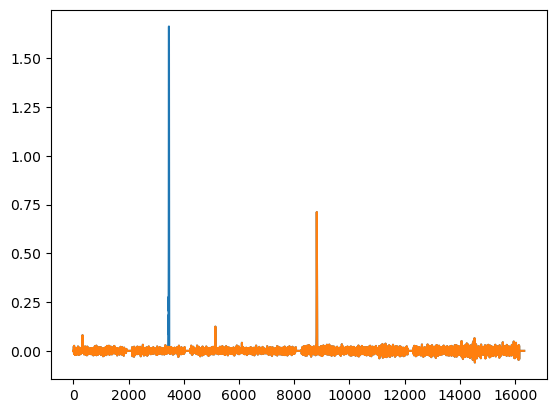

[3454]
16328
去除峰值（左边）
去除峰值（右边）


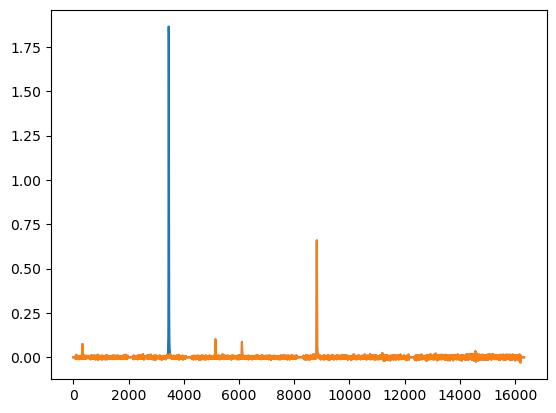

[3452 8819]
16328
去除峰值（左边）
去除峰值（右边）


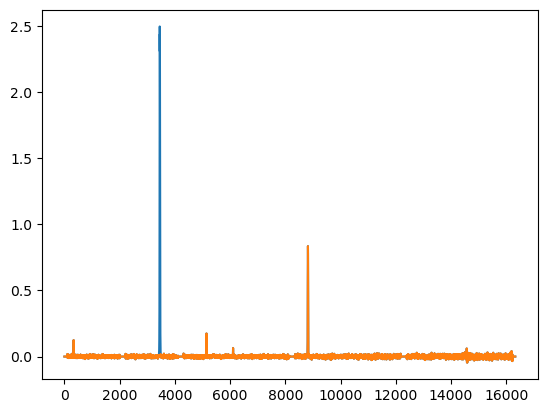

[3465]
16328
去除峰值（左边）
去除峰值（右边）


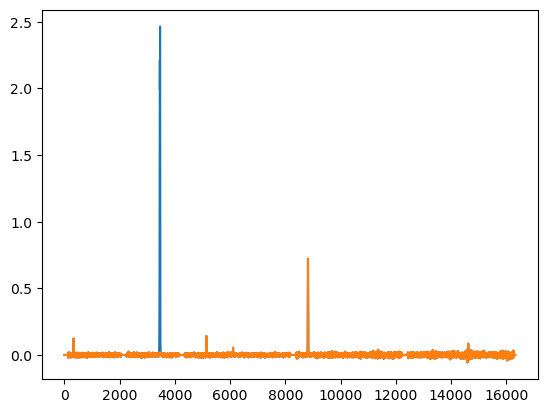

[3449]
16328
去除峰值（左边）
去除峰值（右边）


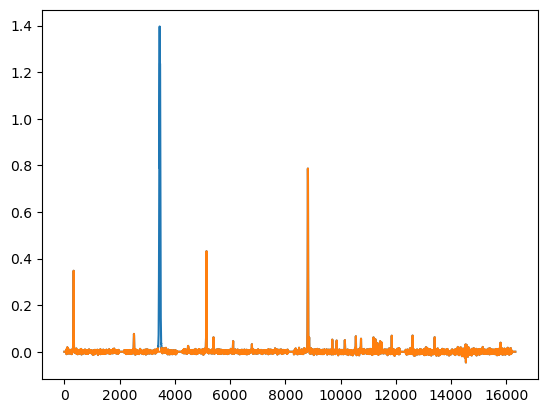

[3460]
16328
去除峰值（左边）
去除峰值（右边）


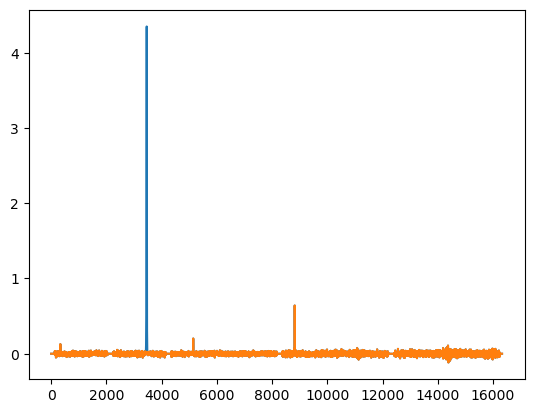

[3454]
16328
去除峰值（左边）
去除峰值（右边）


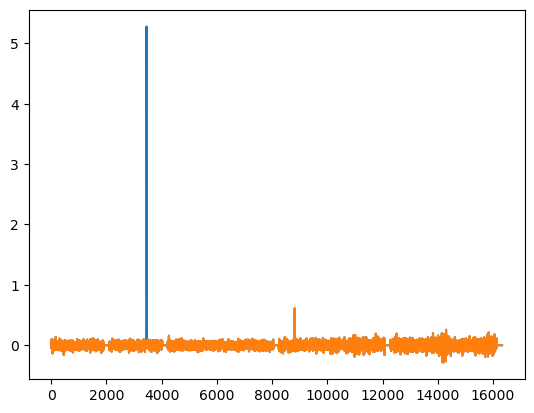

[3460]
16328
去除峰值（左边）
去除峰值（右边）


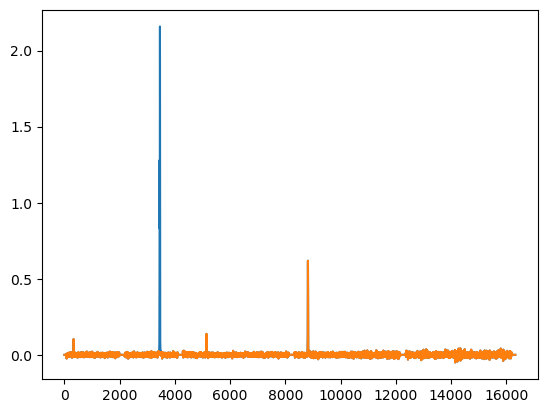

[3460]
16328
去除峰值（左边）
去除峰值（右边）


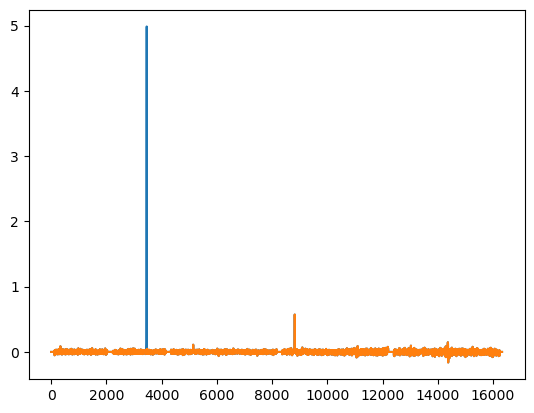

[3460]
16328
去除峰值（左边）
去除峰值（右边）


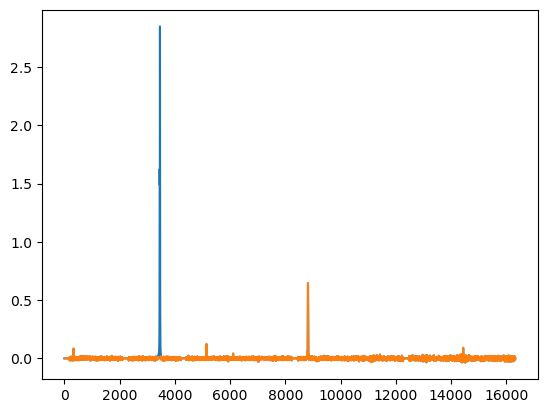

[3456]
16328
去除峰值（左边）
去除峰值（右边）


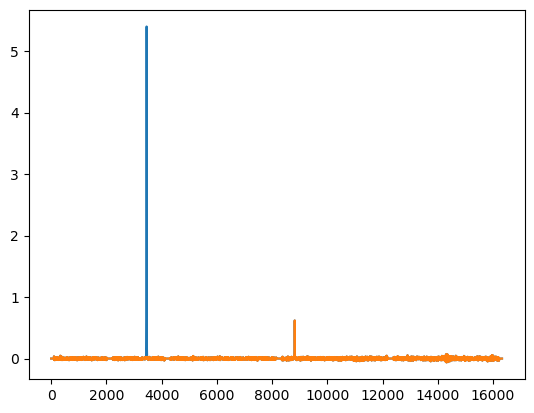

[3455]
16328
去除峰值（左边）
去除峰值（右边）


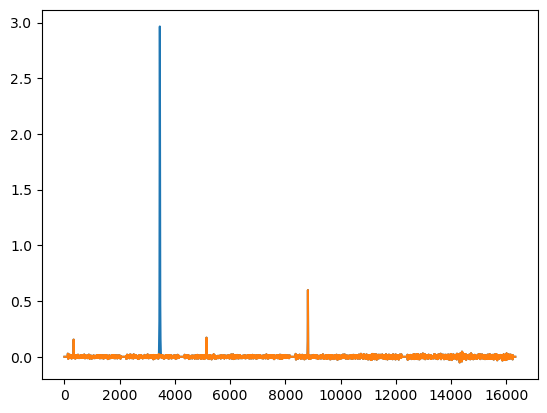

[3457]
16328
去除峰值（左边）
去除峰值（右边）


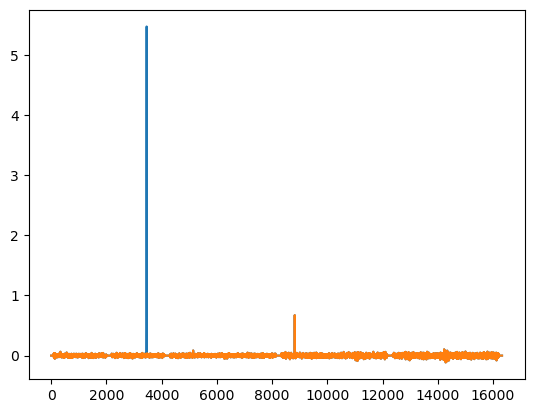

[3454]
16328
去除峰值（左边）
去除峰值（右边）


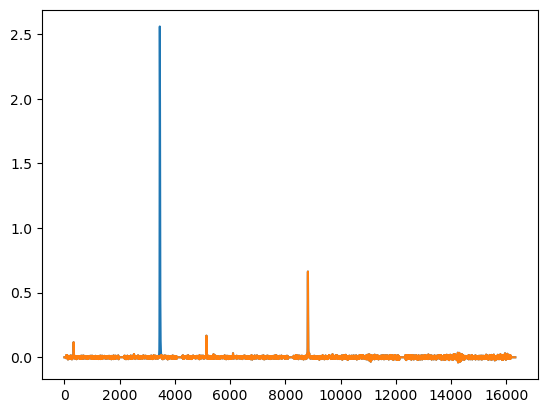

[3458]
16328
去除峰值（左边）
去除峰值（右边）


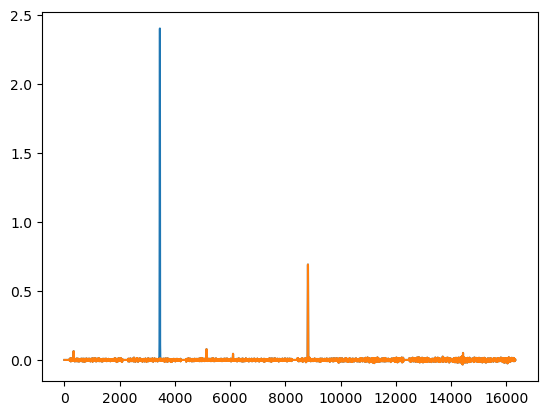

In [40]:
data_flux_outCO=[]
width_all=[]
for i in range(len(data_flux)):
    new_flux,width=remove_3sigma3(list(data_x[i]),list(data_flux[i]),noise_list[i])
    data_flux_outCO.append(new_flux)
    width_all.append(width)


In [41]:
# SpectralEmbedding
spec2=SpectralEmbedding(n_components=3)
digits_spec2=spec2.fit_transform(data_flux_outCO)

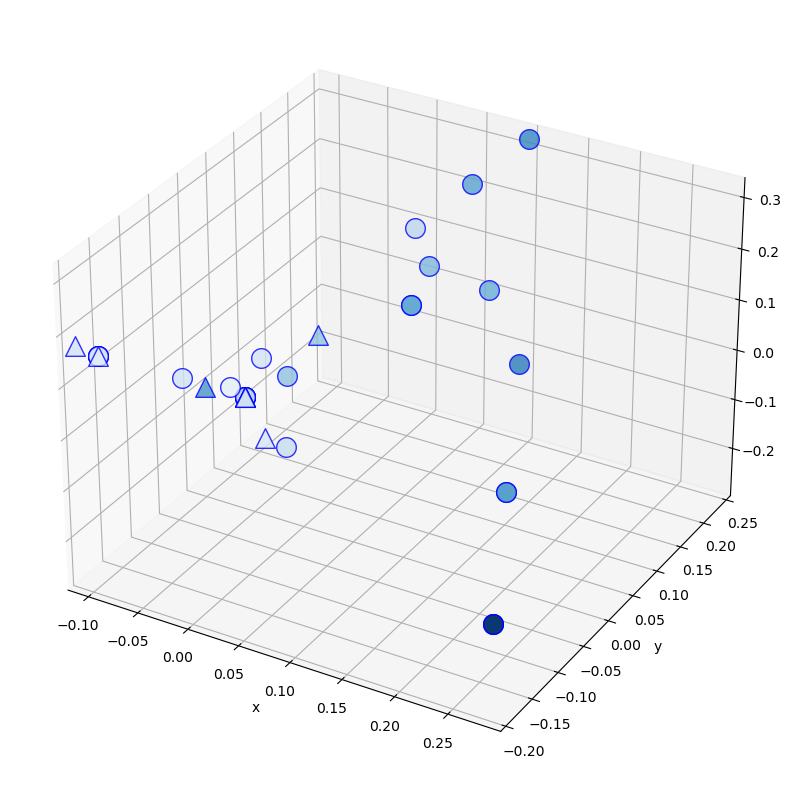

In [42]:
# 3D画图
# SpectralEmbedding
plt.figure(figsize=(10,10))


# 颜色设置
cmap1=plt.cm.Blues
cmap2=plt.cm.Oranges
cmap3=plt.cm.Purples
cmap4=plt.cm.Greens

ax3 = plt.axes(projection='3d')

# digits_str = name_list[0][2:4]
# print(digits_str)
# print(int(digits_str))

for i in range(len(digits_spec)):
    if data_name[i][0]=="L":    # 大麦哲伦云里的
        for j in range(len(name_)):
            if data_name[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    ax3.scatter3D(digits_spec2[i, 0], digits_spec2[i, 1],digits_spec2[i, 2], s=200,color=color0, label=data_name[i],alpha=0.8,edgecolors=(0,0,1,0.8))
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    ax3.scatter3D(digits_spec2[i, 0], digits_spec2[i, 1],digits_spec2[i, 2], s=200,color=color0, label=data_name[i],alpha=0.8,edgecolors=(0,0,1,0.8))
                    break
        continue
        
    elif data_name[i][0]=="S":
        for j in range(len(name_)):
            if data_name[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    ax3.scatter3D(digits_spec2[i, 0], digits_spec2[i, 1],digits_spec2[i, 2], s=200,color=color0, label=data_name[i],alpha=0.8,marker="^",edgecolors=(0,0,1,0.8))
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    ax3.scatter3D(digits_spec2[i, 0], digits_spec2[i, 1],digits_spec2[i, 2], s=200,color=color0, label=data_name[i],alpha=0.8,marker="^",edgecolors=(0,0,1,0.8))
                    break
        continue

ax3.set_ylim([-0.2, 0.25])
ax3.set_xlabel('x')
ax3.set_ylabel('y')
ax3.set_zlabel('z')

# new_texts = [plt.text(x_, y_, text, fontsize=12) for x_, y_, text in zip(digits_spec[:, 0], digits_spec[:, 1], data_name)]
# adjust_text(new_texts,arrowprops=dict(arrowstyle='->',color='red',lw=1))
#plt.legend(loc="right")
#plt.savefig('./picture/SpectralEmbedding(Blues)(38).png')
plt.show()

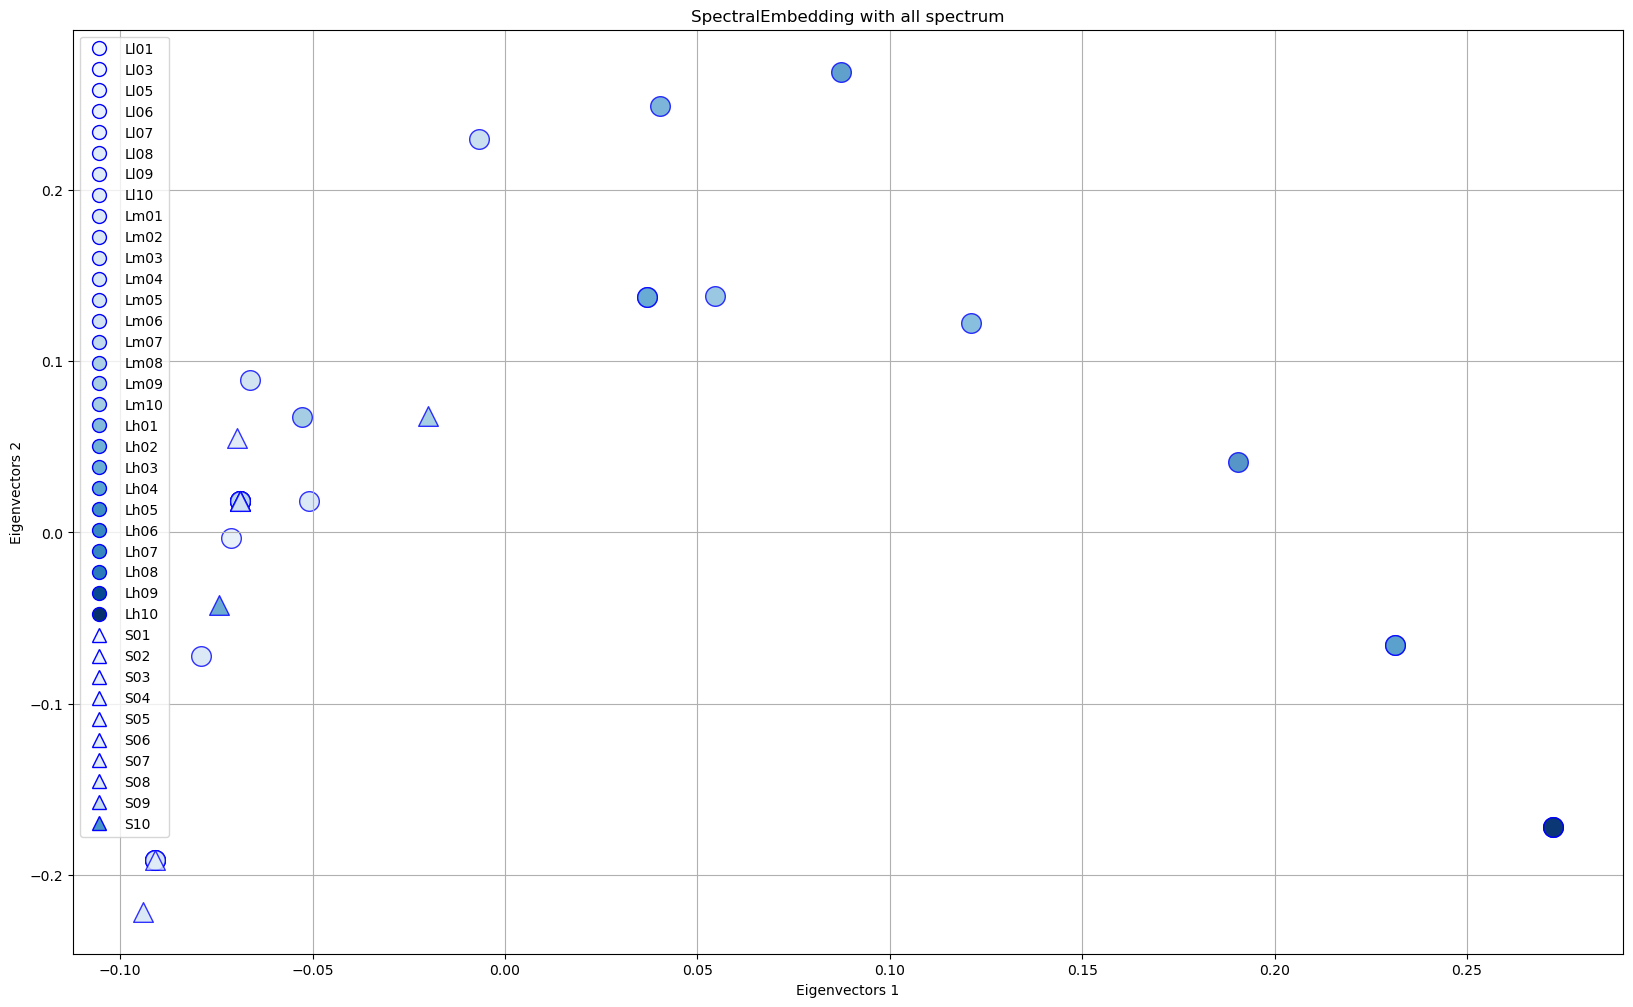

In [72]:
# 2D画图
# SpectralEmbedding
plt.figure(figsize=(20,12))
plt.grid()

# 颜色设置
cmap1=plt.cm.Blues
cmap2=plt.cm.Oranges
cmap3=plt.cm.Purples
cmap4=plt.cm.Greens

spec_marker=[]
# digits_str = name_list[0][2:4]
# print(digits_str)
# print(int(digits_str))

for i in range(len(digits_spec)):
    if data_name[i][0]=="L":    # 大麦哲伦云里的
        spec_marker.append("o")
        for j in range(len(name_)):
            if data_name[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    plt.scatter(digits_spec2[i, 0], digits_spec2[i, 1], s=200,color=color0, label=data_name[i],alpha=0.8,edgecolors=(0,0,1,0.8))
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    plt.scatter(digits_spec2[i, 0], digits_spec2[i, 1], s=200,color=color0, label=data_name[i],alpha=0.8,edgecolors=(0,0,1,0.8))
                    break
        continue
        
    elif data_name[i][0]=="S":
        spec_marker.append("^")
        for j in range(len(name_)):
            if data_name[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    plt.scatter(digits_spec2[i, 0], digits_spec2[i, 1], s=200,color=color0, label=data_name[i],alpha=0.8,marker="^",edgecolors=(0,0,1,0.8))
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    plt.scatter(digits_spec2[i, 0], digits_spec2[i, 1], s=200,color=color0, label=data_name[i],alpha=0.8,marker="^",edgecolors=(0,0,1,0.8))
                    break
        continue

color=[]
for i in range(len(name_L)):
    if name_L[j]>=10:
        color.append(cmap1( name_L[i]/max(name_L)))
    elif name_L[j]<10:
        color.append(cmap1( name_L[j]/15))

# 使用循环生成句柄列表
handles = []
for cat, color, marker in zip(name_, color, spec_marker):
    handle = Line2D(
        [], [], 
        color=color, 
        marker=marker, 
        linestyle="None",  # 无连线
        markersize=10, 
        label=cat,
        markeredgecolor="blue"
    )
    handles.append(handle)

# new_texts = [plt.text(x_, y_ ,text, fontsize=12) for x_, y_,text in zip(digits_spec[:, 1], digits_spec[:, 2],data_name)]
# adjust_text(new_texts,arrowprops=dict(arrowstyle='->',color='red',lw=1))
#plt.legend(loc="right")
#plt.savefig('./picture/SpectralEmbedding(Blues)(38).png')
plt.legend(handles=handles, loc="best")
plt.title("SpectralEmbedding with all spectrum")
plt.xlabel("Eigenvectors 1")
plt.ylabel("Eigenvectors 2")
# plt.savefig('./picture/SpectralEmbedding(Blues)(HCO+).png')
plt.show()

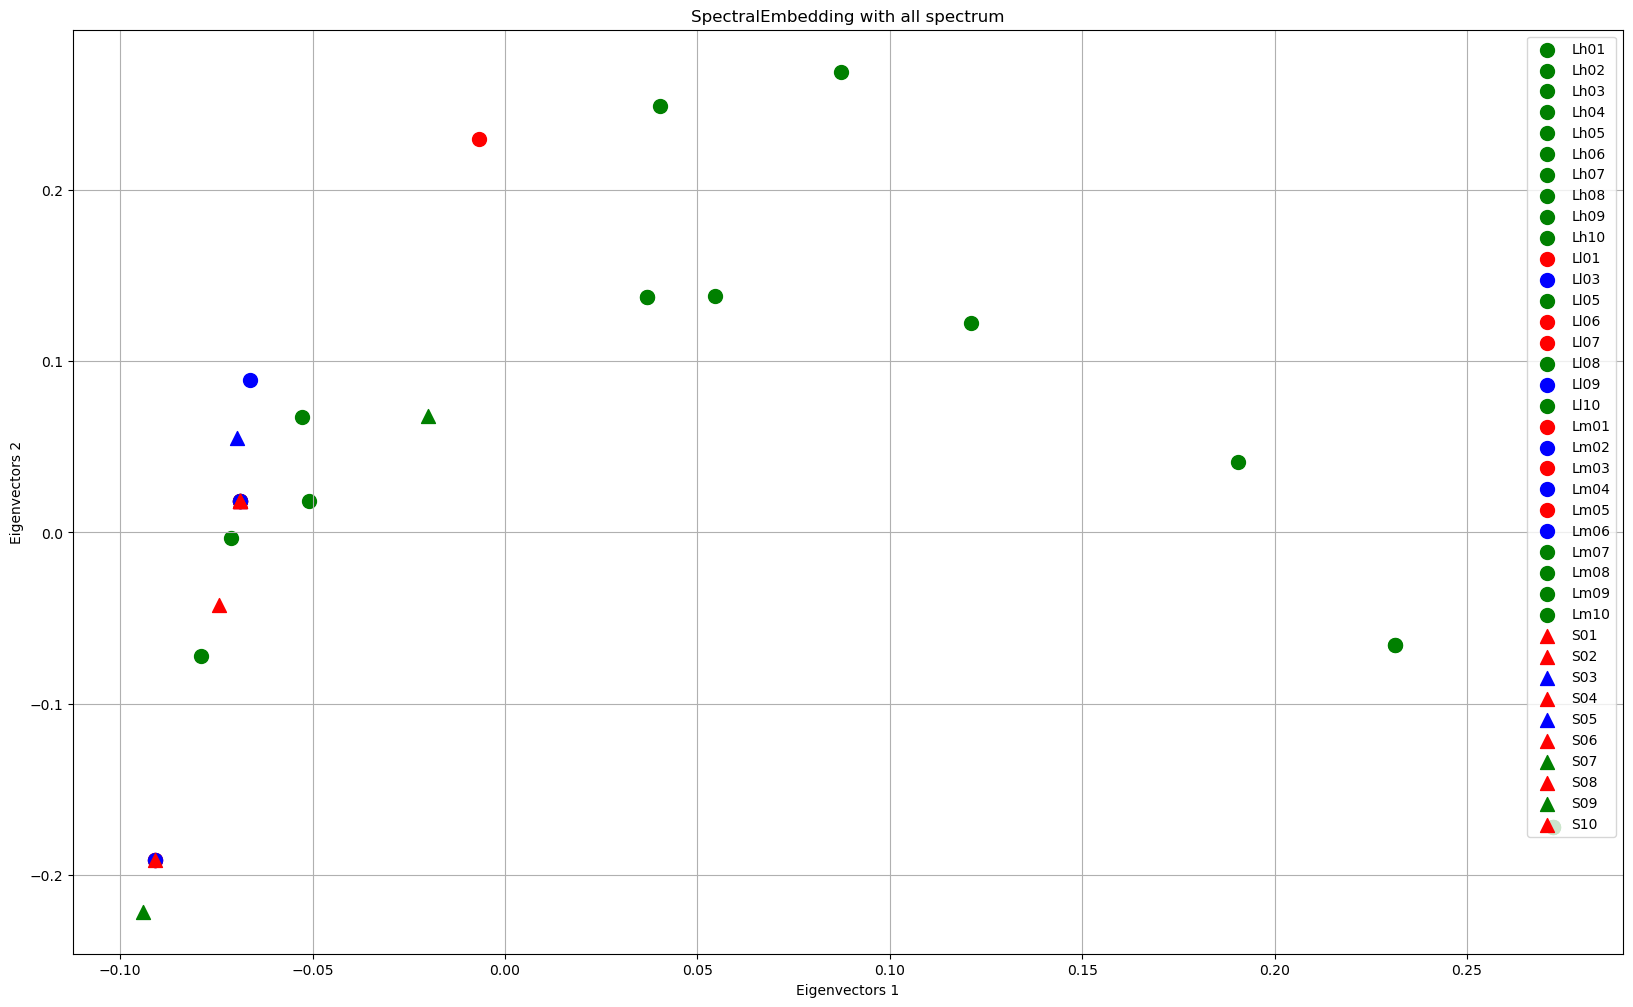

In [81]:
# 与CO的结果进行比较
file_path_color = "data_with_colors(2).txt"

# 假设文件格式：
# 列名: ID   Vsys   RA    Dec
# 数据: 001  250.3  12.5  30.0
# 注释行以 '#' 开头

df_color = pd.read_csv(
    file_path_color,
    sep='\s+',          # 按空格/制表符分隔
    comment='#',        # 忽略注释行
    header=0,           # 第一行为列名
    #names=['ID', 'Vsys', 'RA', 'Dec']  # 可选：手动指定列名
)

# print(df_color) 
na=df_color["name"].tolist()
col=df_color["color"].tolist()
# print(na)
# print(col)
fig, ax = plt.subplots(figsize=(20,12))
plt.grid()
#ax.set_xlim(-0.16,0.22)

for i in range(len(digits_spec)):
    count=0
    for j in range(len(na)):
        if name_list[i*5]==na[j]:
            color0=col[j]
            #print(color0)
            if name_list[i*5][0]=="L":
                ax.scatter(digits_spec2[i, 0], digits_spec2[i, 1],color=color0,s=100, label=name_list[i*5])
                count=1
                break
            elif name_list[i*5][0]=="S":
                ax.scatter(digits_spec2[i, 0], digits_spec2[i, 1],color=color0,s=100, label=name_list[i*5],marker="^")
                count=1
                break
ax.legend(loc=1)
plt.title("SpectralEmbedding with all spectrum")
plt.xlabel("Eigenvectors 1")
plt.ylabel("Eigenvectors 2")
plt.show()

In [82]:
# PCA
data_flux_outCO=np.array(data_flux_outCO)
print(data_flux_outCO.shape)
model2 = PCA(10)  # project from  to 2 dimensions
model2.fit(data_flux_outCO)
digits_pca2 = model2.transform(data_flux_outCO)

(38, 16328)


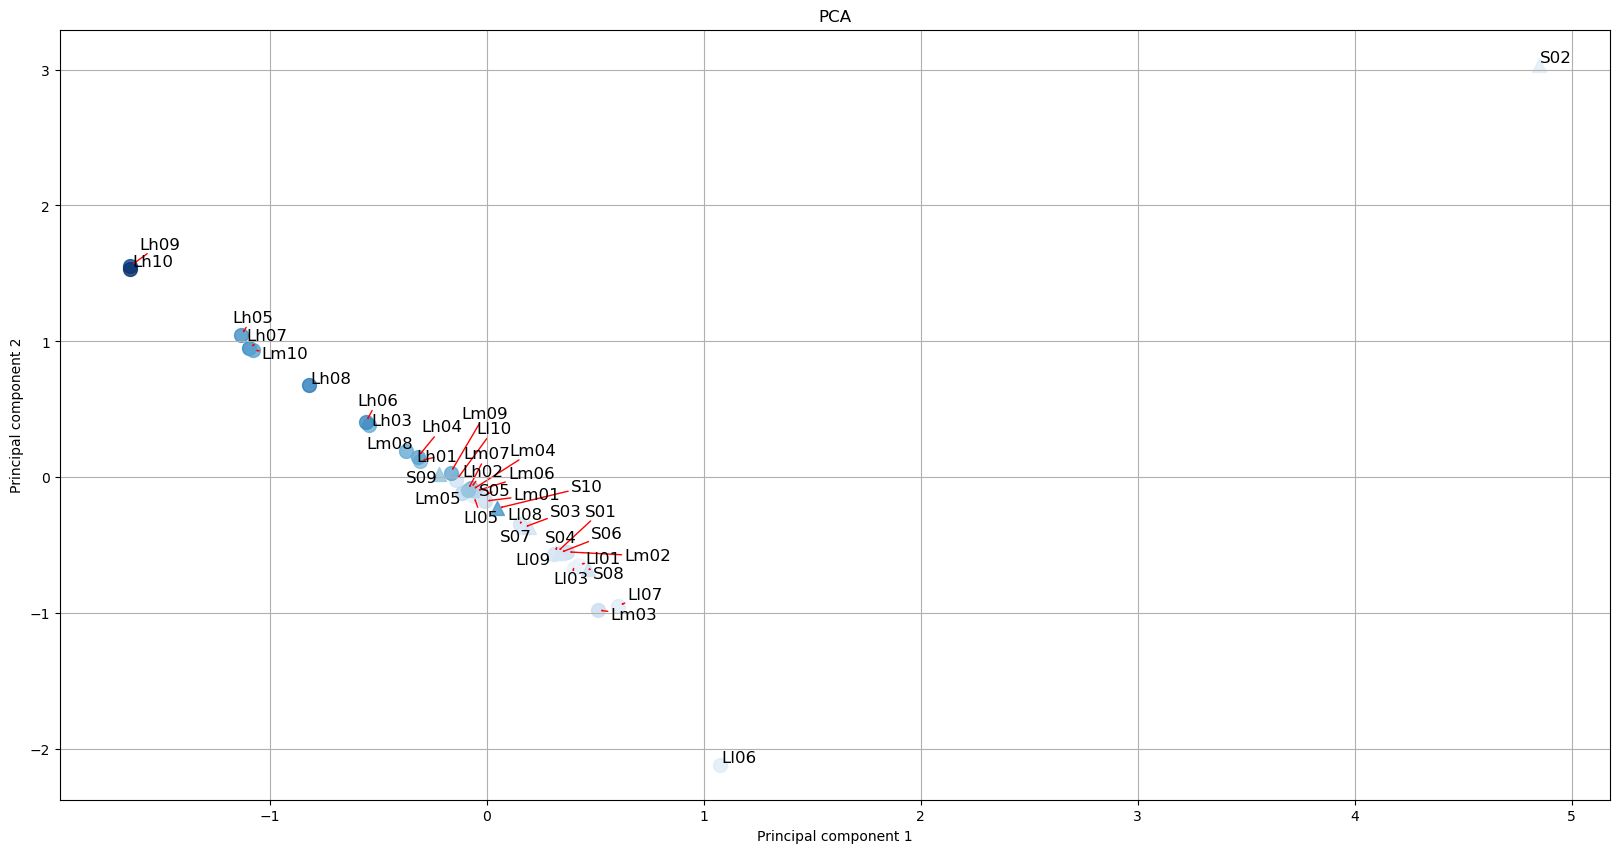

In [105]:
# PCA画图
plt.figure(figsize=(20,10))
plt.grid()
for i in range(len(digits_pca)):
    if data_name[i][0]=="L":    # 大麦哲伦云里的
        for j in range(len(name_)):
            if data_name[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    plt.scatter(digits_pca2[i, 0], digits_pca2[i, 1], s=100,color=color0, label=data_name[i],alpha=0.8)
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    plt.scatter(digits_pca2[i, 0], digits_pca2[i, 1], s=100,color=color0, label=data_name[i],alpha=0.8)
                    break
        continue
        
    elif data_name[i][0]=="S":
        for j in range(len(name_)):
            if data_name[i][0:4]==name_[j]:
                if name_L[j]>=10:
                    color0=cmap1( name_L[j]/max(name_L))
                    plt.scatter(digits_pca2[i, 0], digits_pca2[i, 1], s=100,color=color0, label=data_name[i],alpha=0.8,marker="^")
                    break
                elif name_L[j]<10:
                    color0=cmap1( name_L[j]/15)
                    plt.scatter(digits_pca2[i, 0], digits_pca2[i, 1], s=100,color=color0, label=data_name[i],alpha=0.8,marker="^")
                    break
        continue
    
new_texts = [plt.text(x_, y_, text, fontsize=12) for x_, y_, text in zip(digits_pca2[:, 0], digits_pca2[:, 1], data_name)]
adjust_text(new_texts,arrowprops=dict(arrowstyle='->',color='red',lw=1))
#plt.legend()
plt.title("PCA")
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
#plt.savefig('./picture/pca(Blues)(38).png')
plt.show()

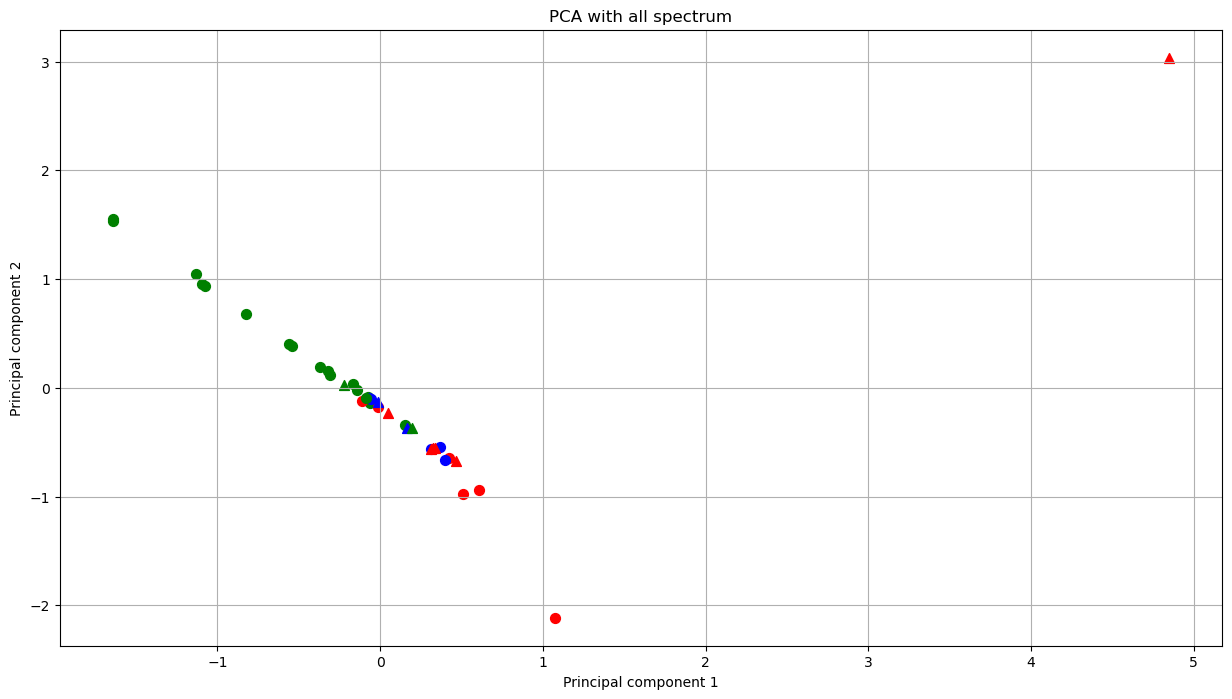

In [97]:
fig, ax = plt.subplots(figsize=(15,8))
plt.grid()

for i in range(len(digits_pca2)):
    count=0
    for j in range(len(na)):
        if name_list[i*5]==na[j]:
            color0=col[j]
            #print(color0)
            if name_list[i*5][0]=="L":
                ax.scatter(digits_pca2[i, 0], digits_pca2[i, 1],color=color0,s=50, label=name_list[i*5])
                count=1
                break
            if name_list[i*5][0]=="S":
                ax.scatter(digits_pca2[i, 0], digits_pca2[i, 1],color=color0,s=50, label=name_list[i*5],marker="^")
                count=1
                break


# ax.legend(loc="best")
plt.title("PCA with all spectrum")
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.show()

In [101]:
# 5. 输出PCA的主成分和解释方差
print("主成分（特征向量）：\n", model2.components_)
print("解释方差（每个主成分的贡献）：", model2.explained_variance_ratio_)
component2=model2.components_
ratio2=model2.explained_variance_ratio_
mean2=model2.mean_

主成分（特征向量）：
 [[-4.21788143e-03 -6.30333050e-03 -2.31888368e-03 ...  1.71583806e-03
   1.62180194e-03  0.00000000e+00]
 [-3.59017761e-03 -5.36527078e-03 -1.97378812e-03 ... -4.46723566e-03
  -4.22240982e-03 -0.00000000e+00]
 [-5.69899589e-04 -8.51675306e-04 -3.13316265e-04 ... -7.53206949e-03
  -7.11927613e-03 -0.00000000e+00]
 ...
 [-1.56103892e-04 -2.33286412e-04 -8.58219401e-05 ...  1.36126747e-03
   1.28666352e-03 -0.00000000e+00]
 [-1.86227071e-04 -2.78303408e-04 -1.02382896e-04 ...  3.10976935e-03
   2.93933914e-03  0.00000000e+00]
 [ 6.36161146e-05  9.50698595e-05  3.49745180e-05 ... -5.17667539e-04
  -4.89296886e-04  0.00000000e+00]]
解释方差（每个主成分的贡献）： [0.21294203 0.15655109 0.09657233 0.06482102 0.04829119 0.04263898
 0.03825212 0.03703181 0.03213067 0.02935344]


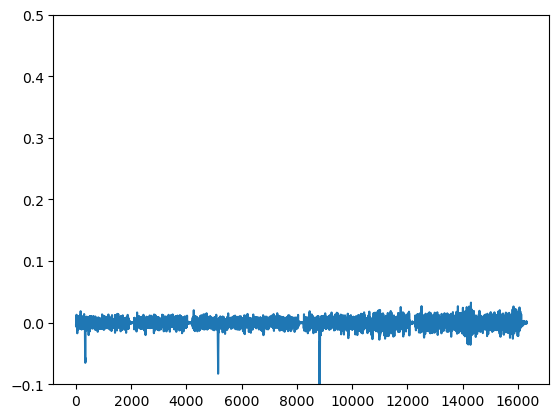

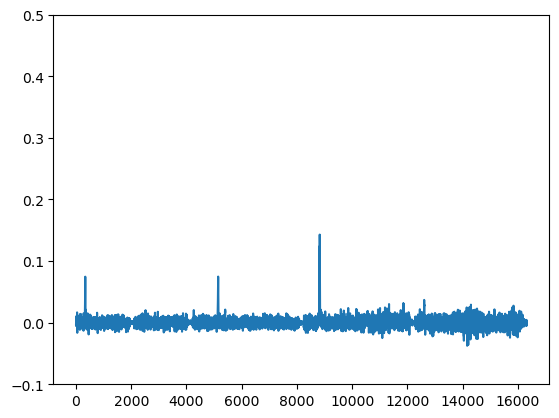

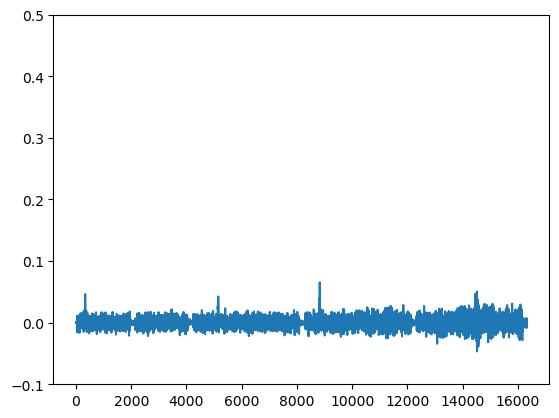

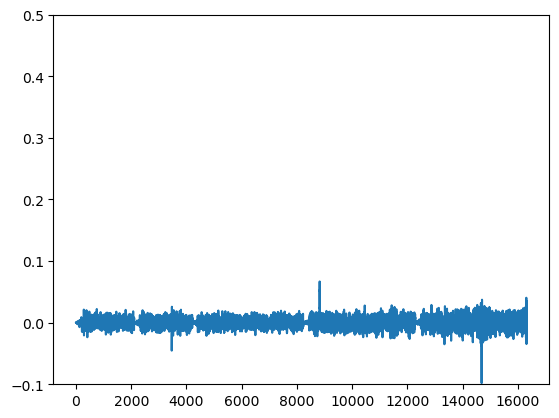

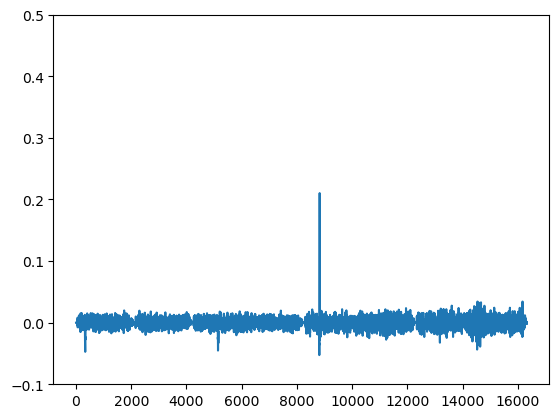

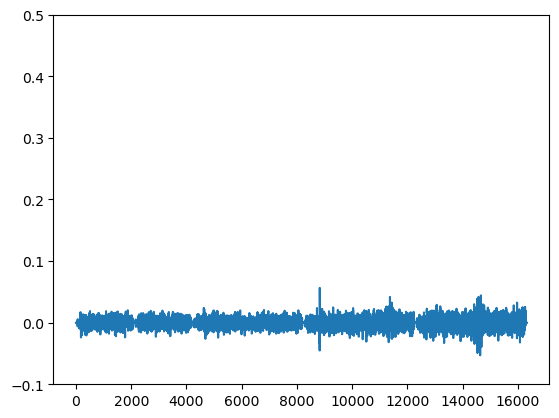

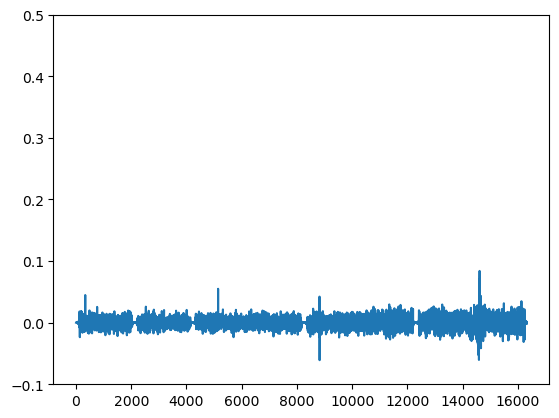

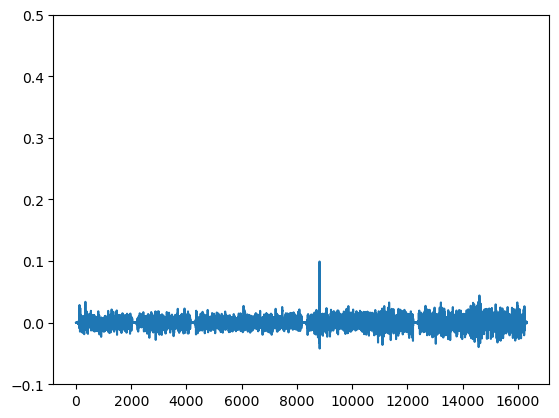

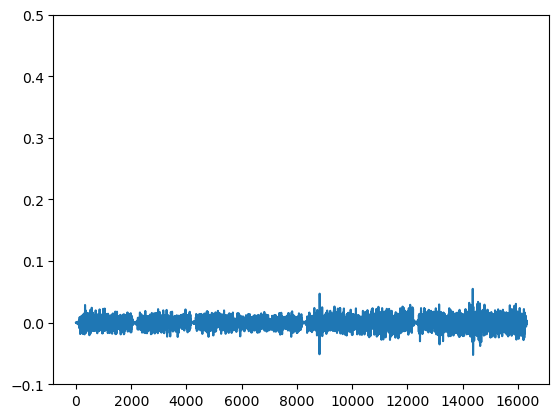

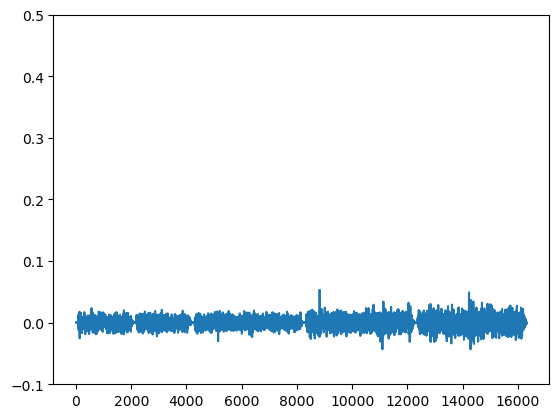

In [100]:
for i in range(10):
    plt.ylim(-0.1,0.5)
    plt.plot(component2[i])
    plt.show()

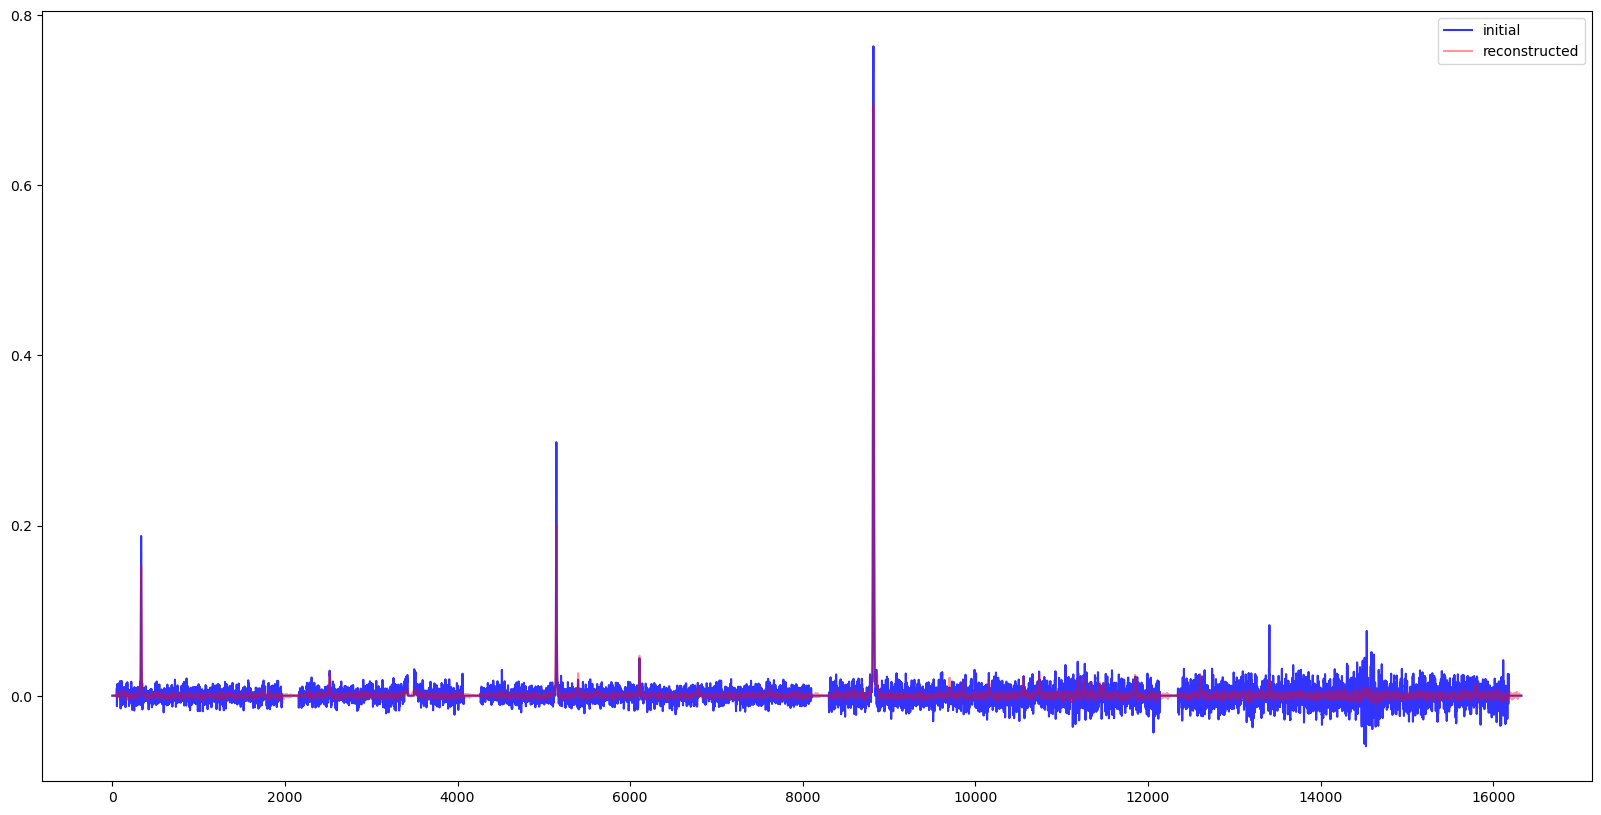

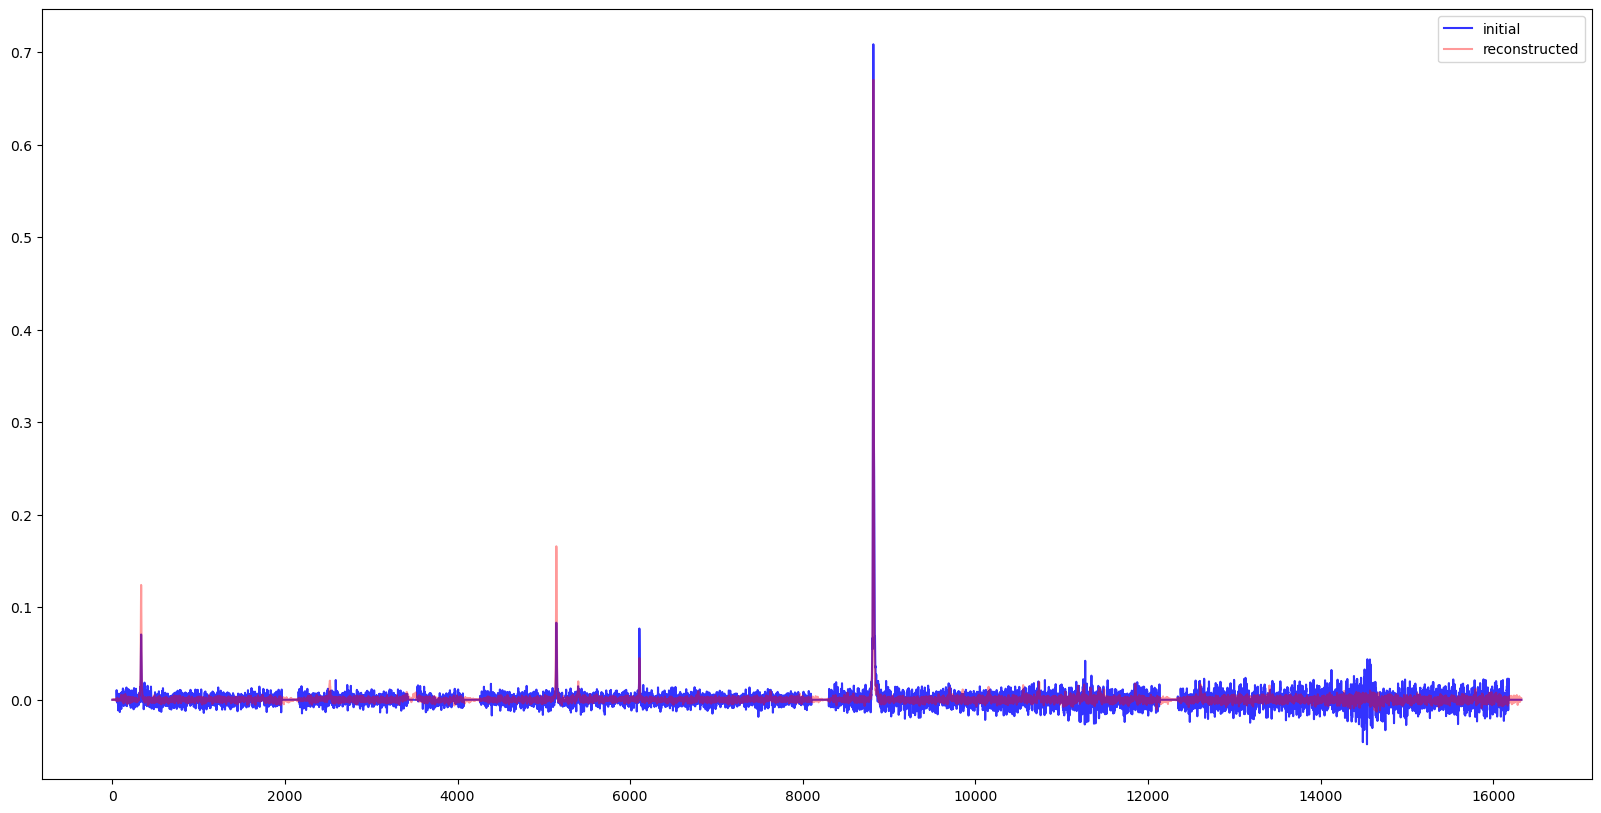

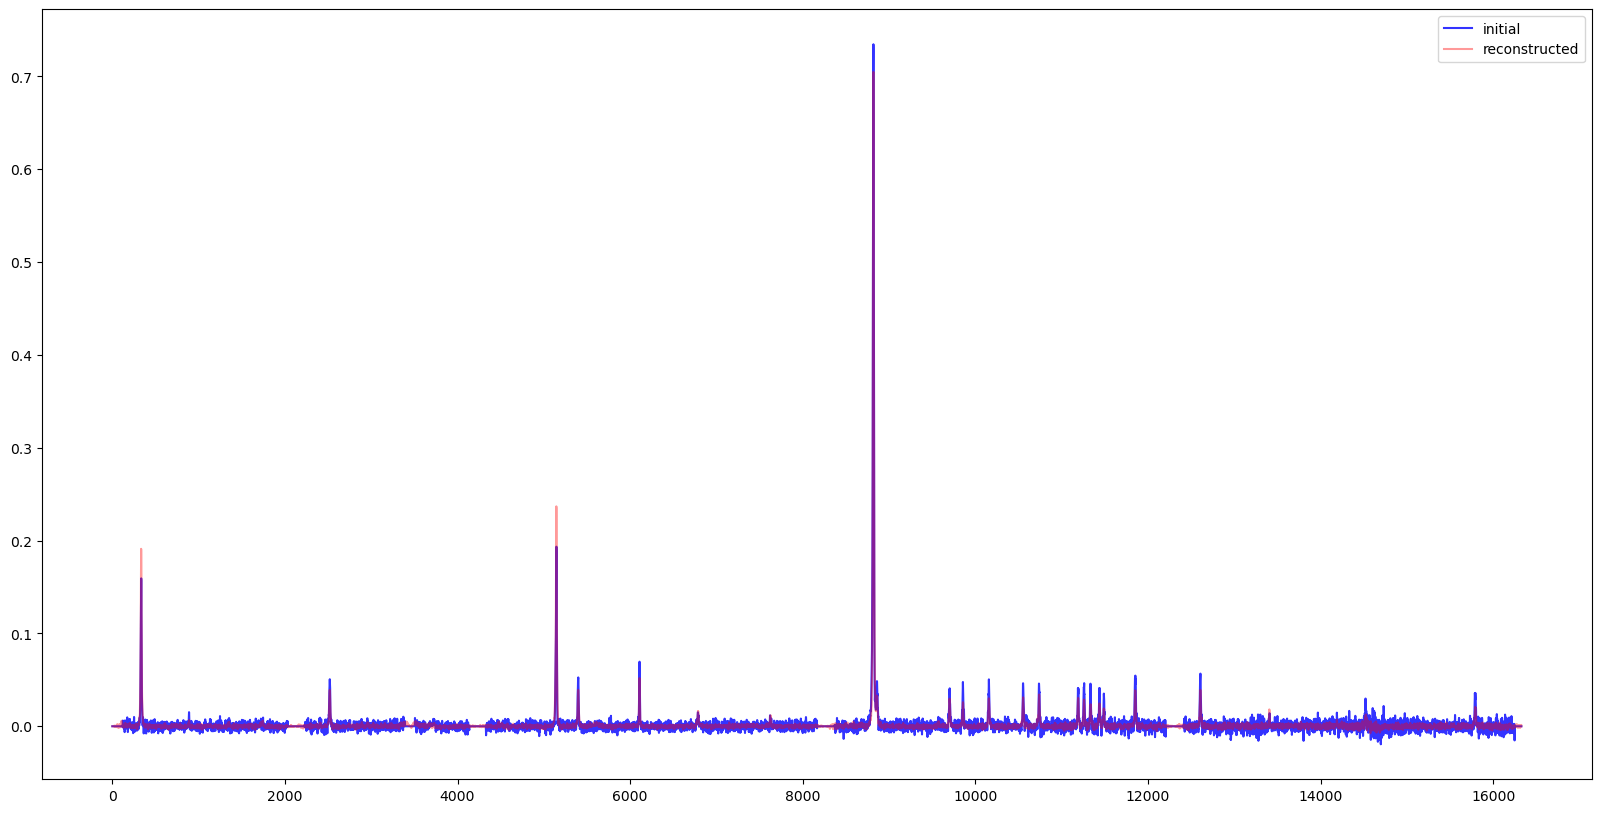

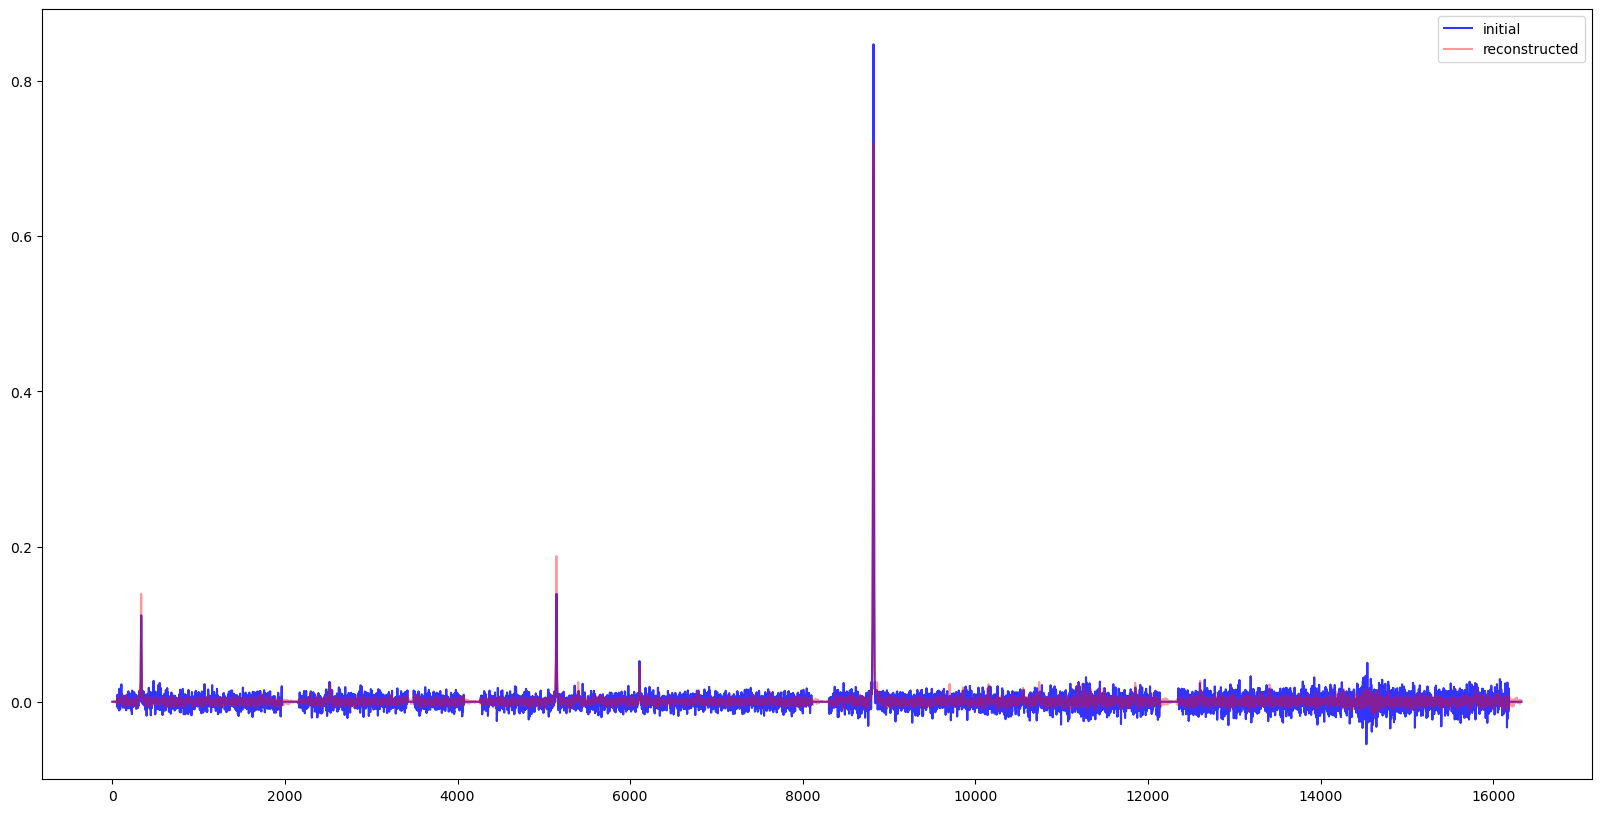

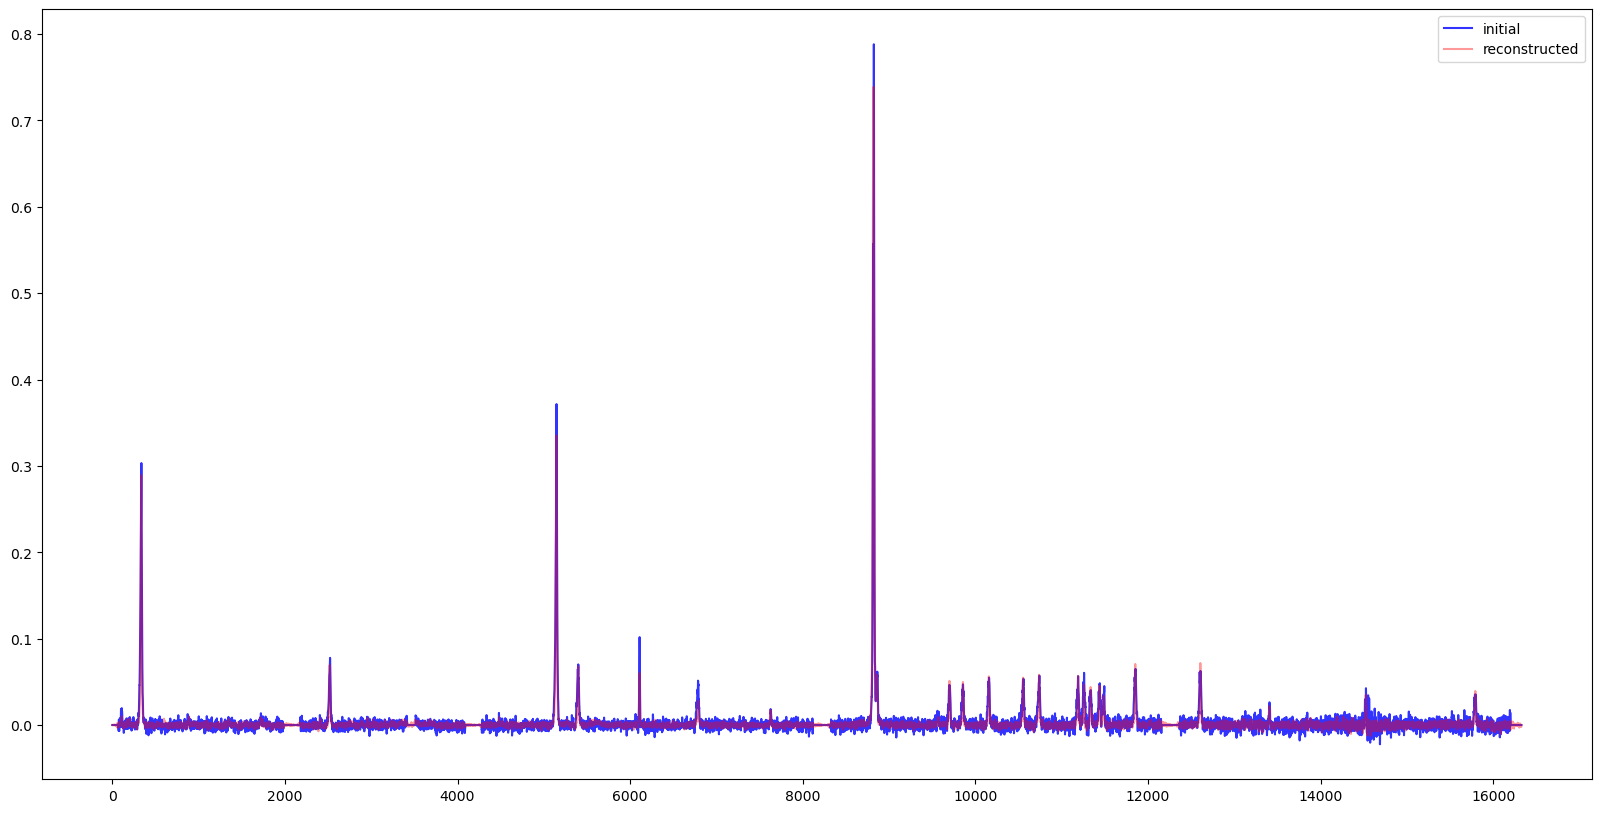

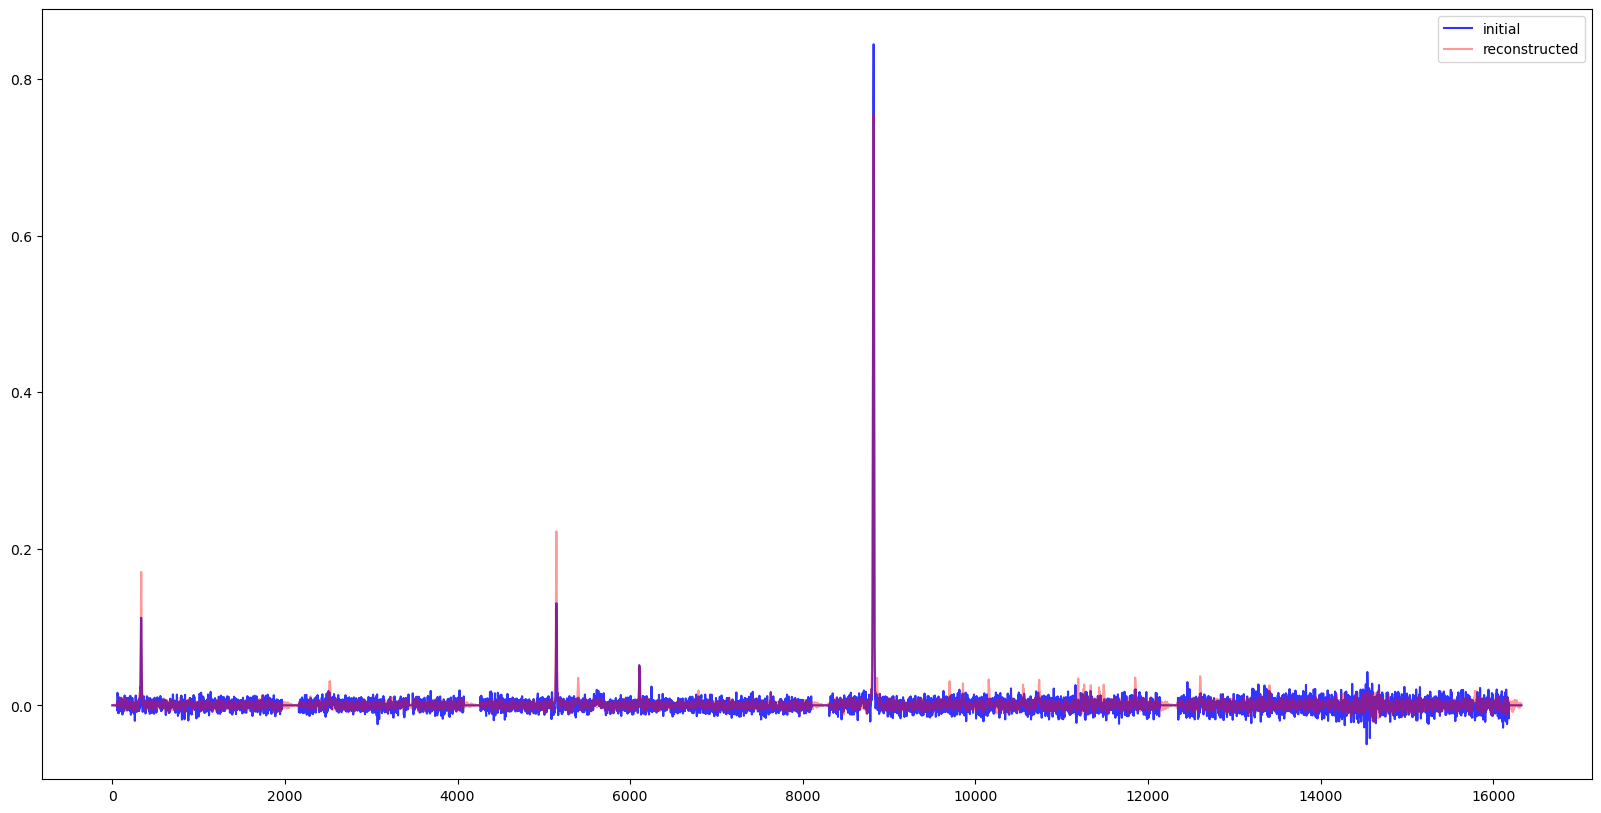

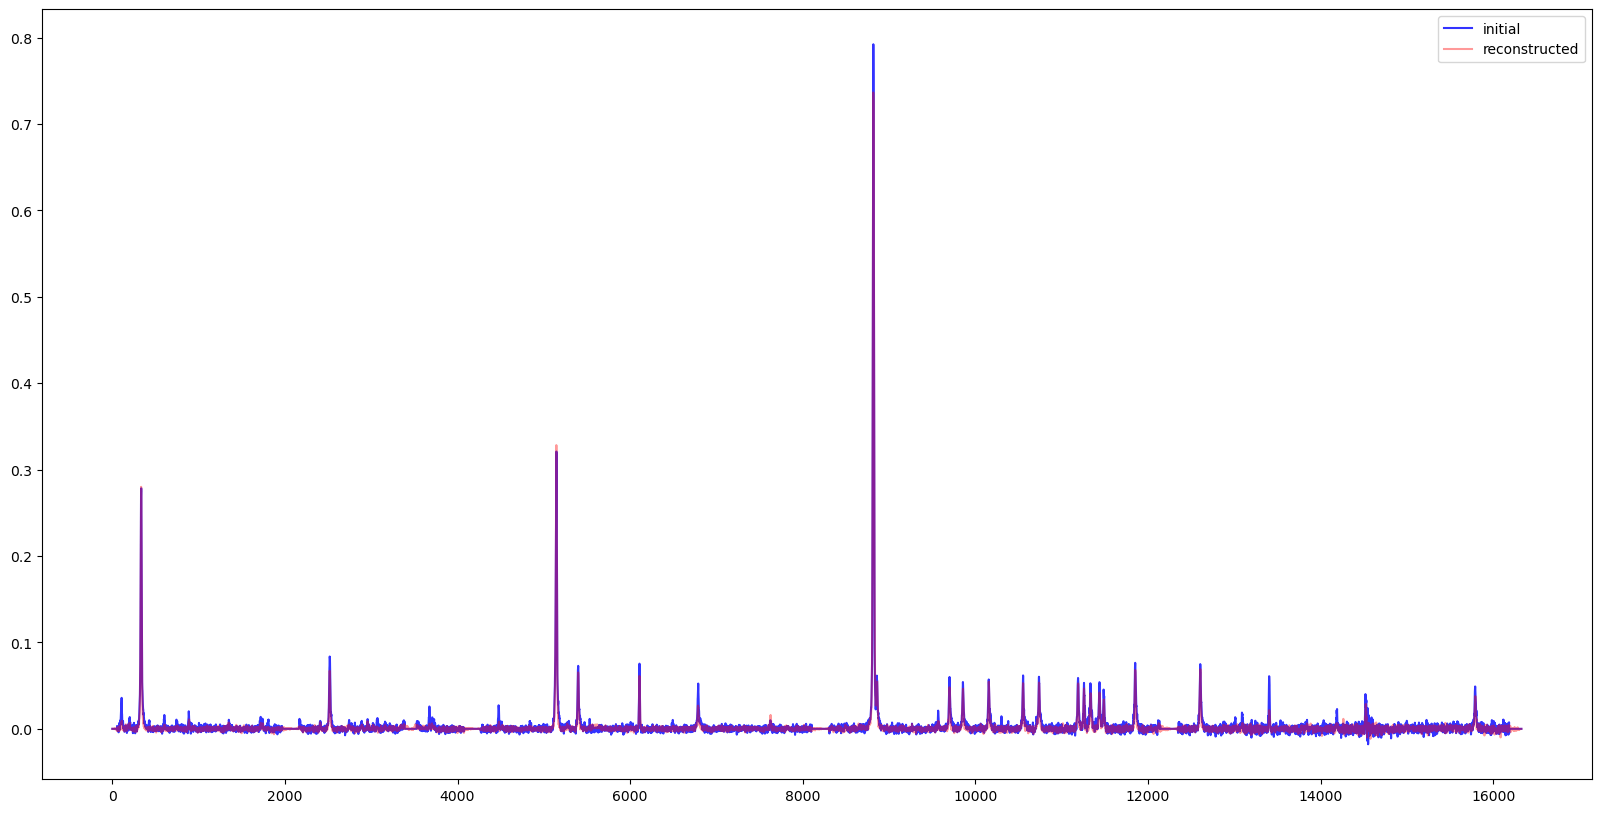

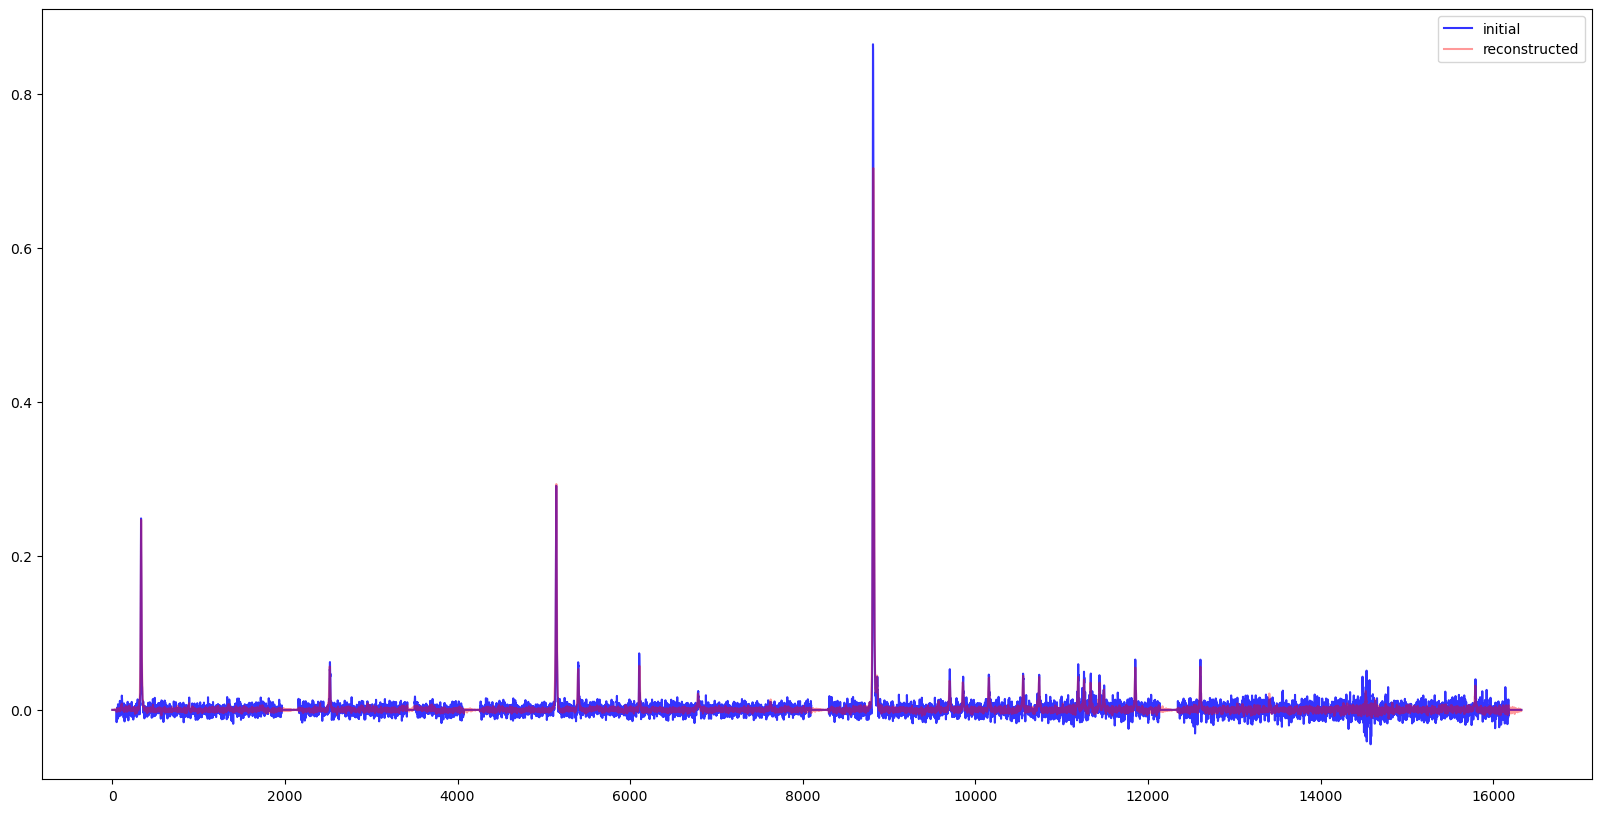

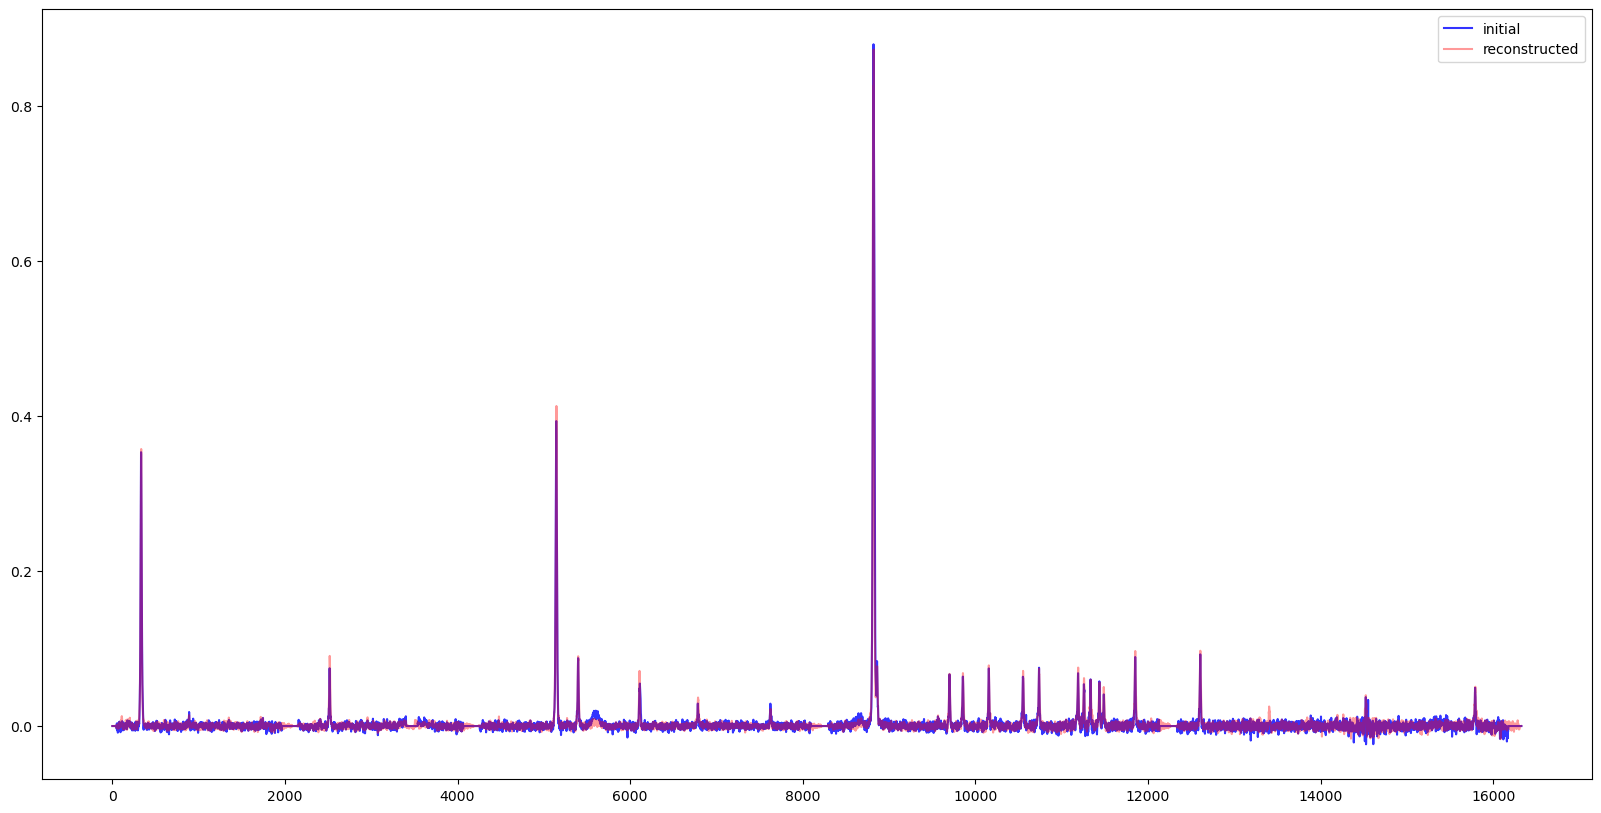

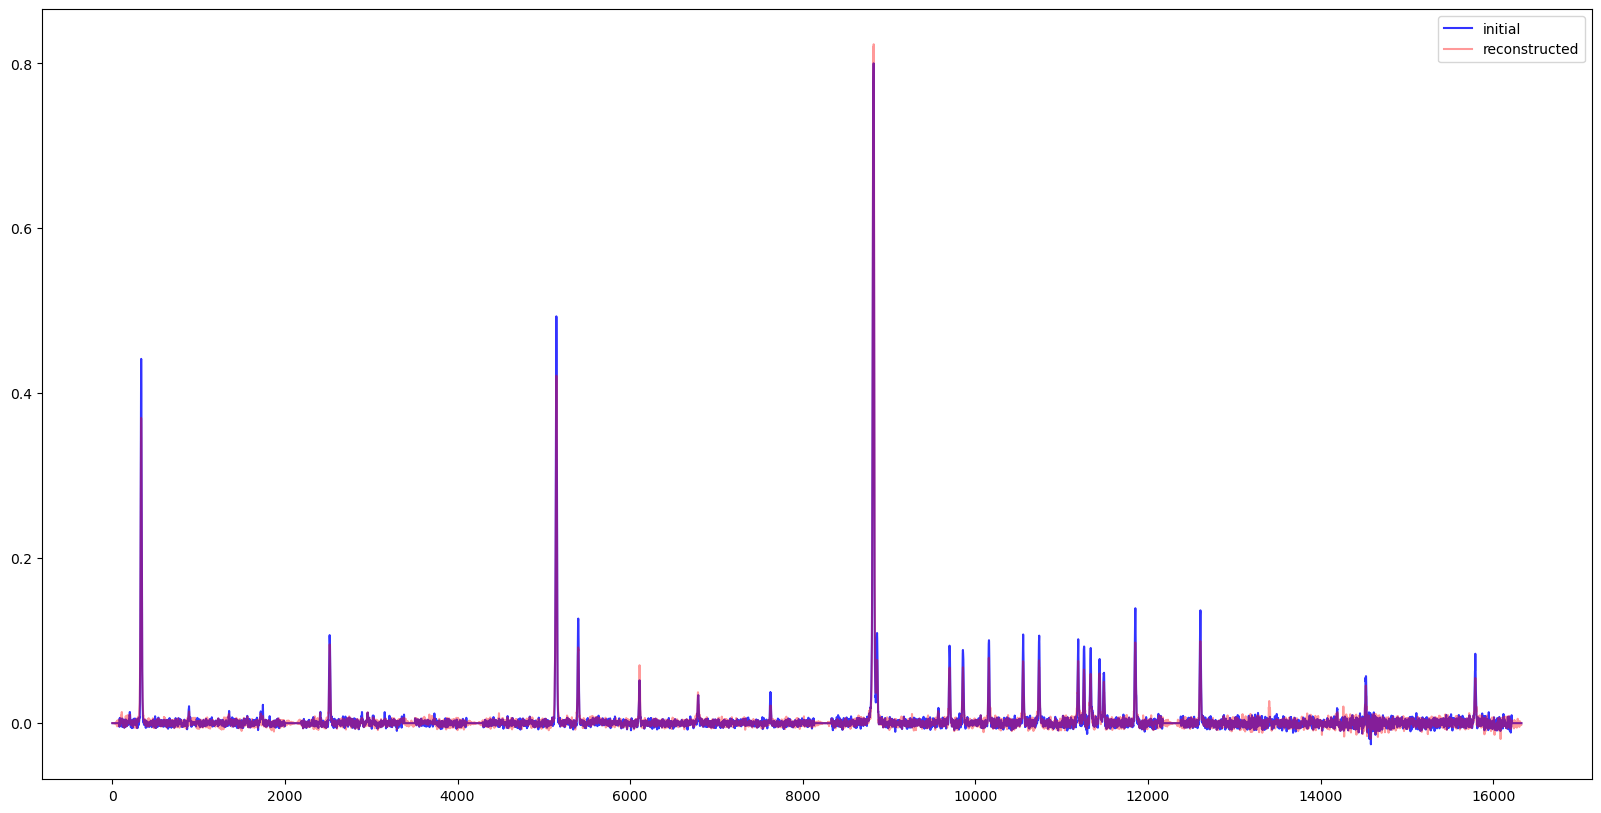

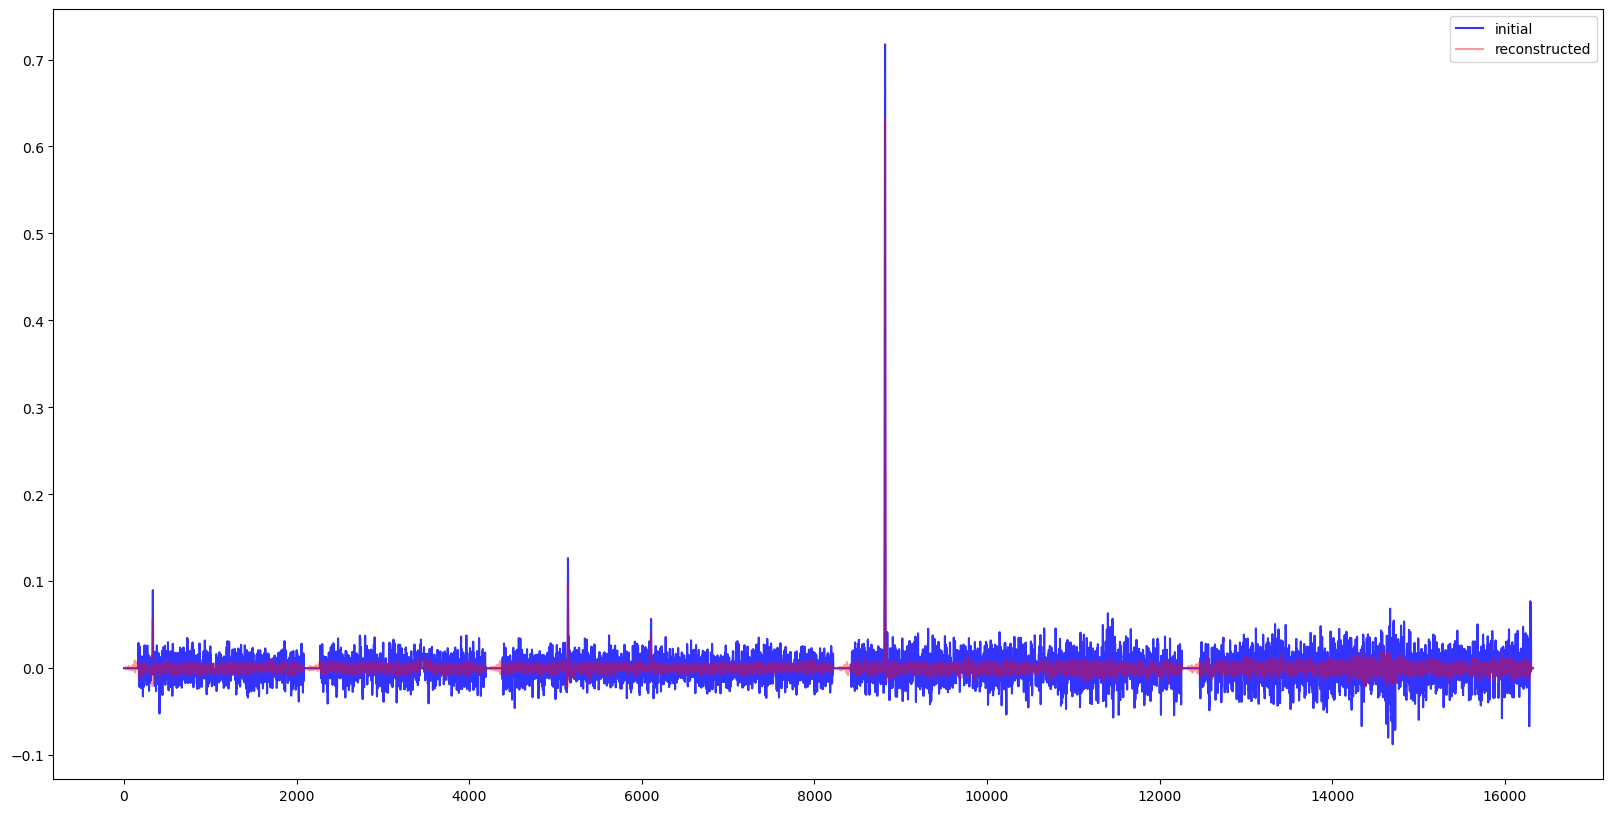

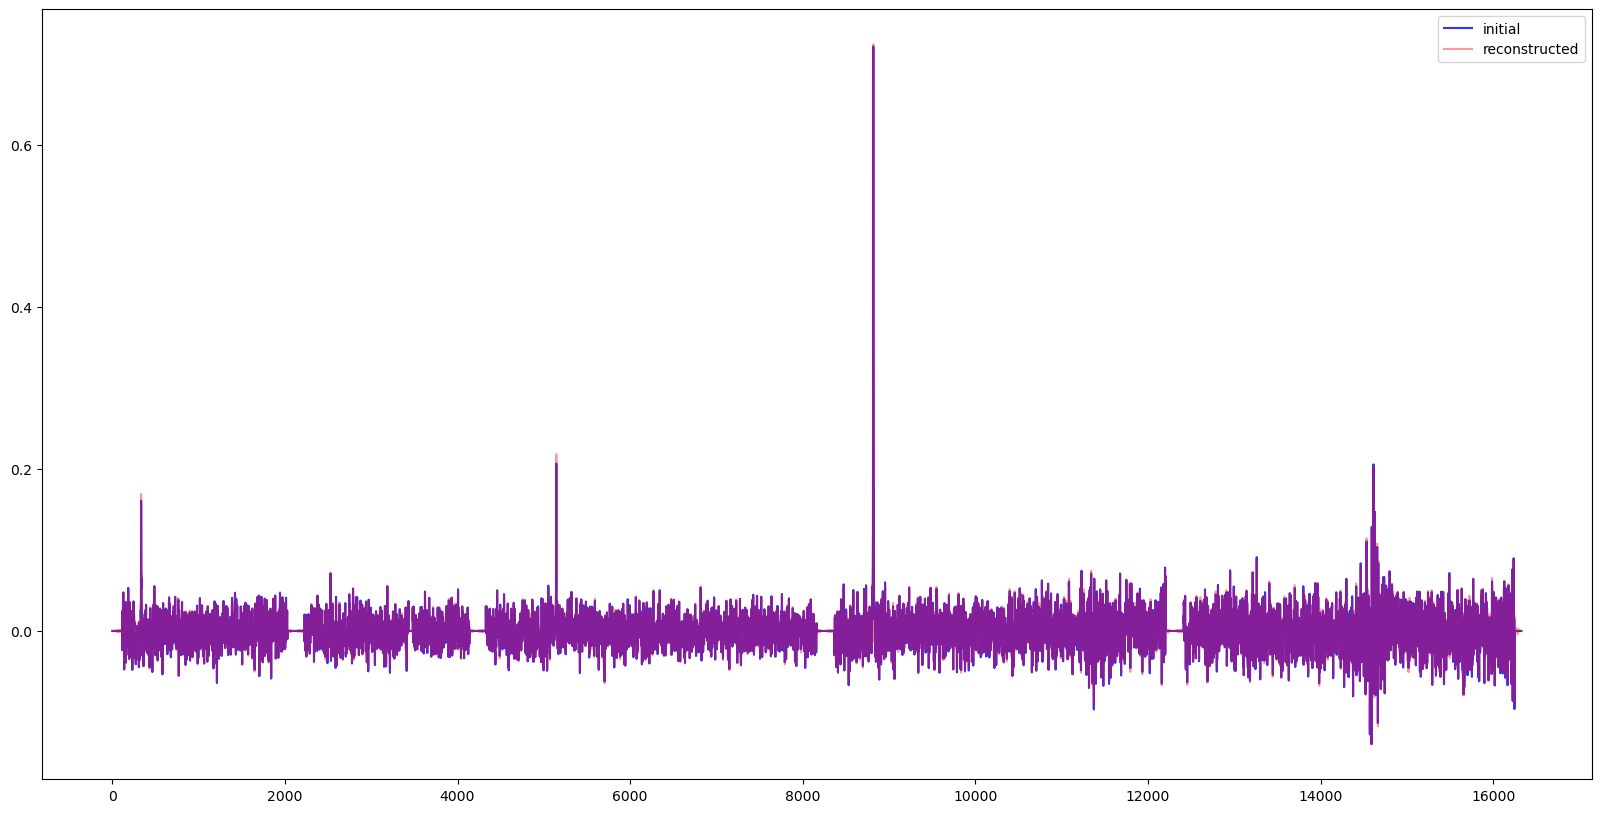

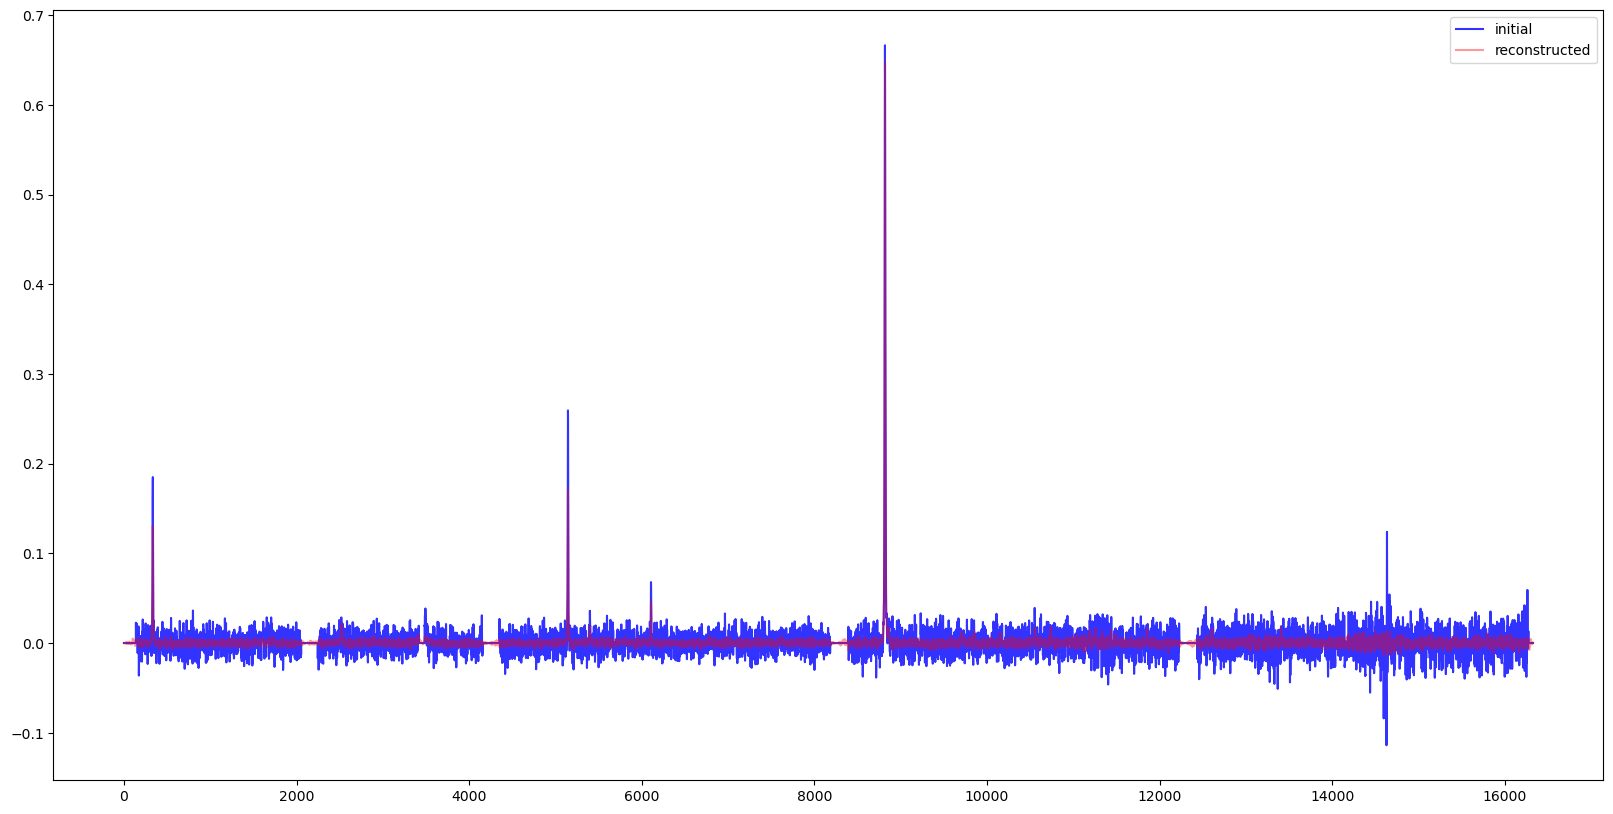

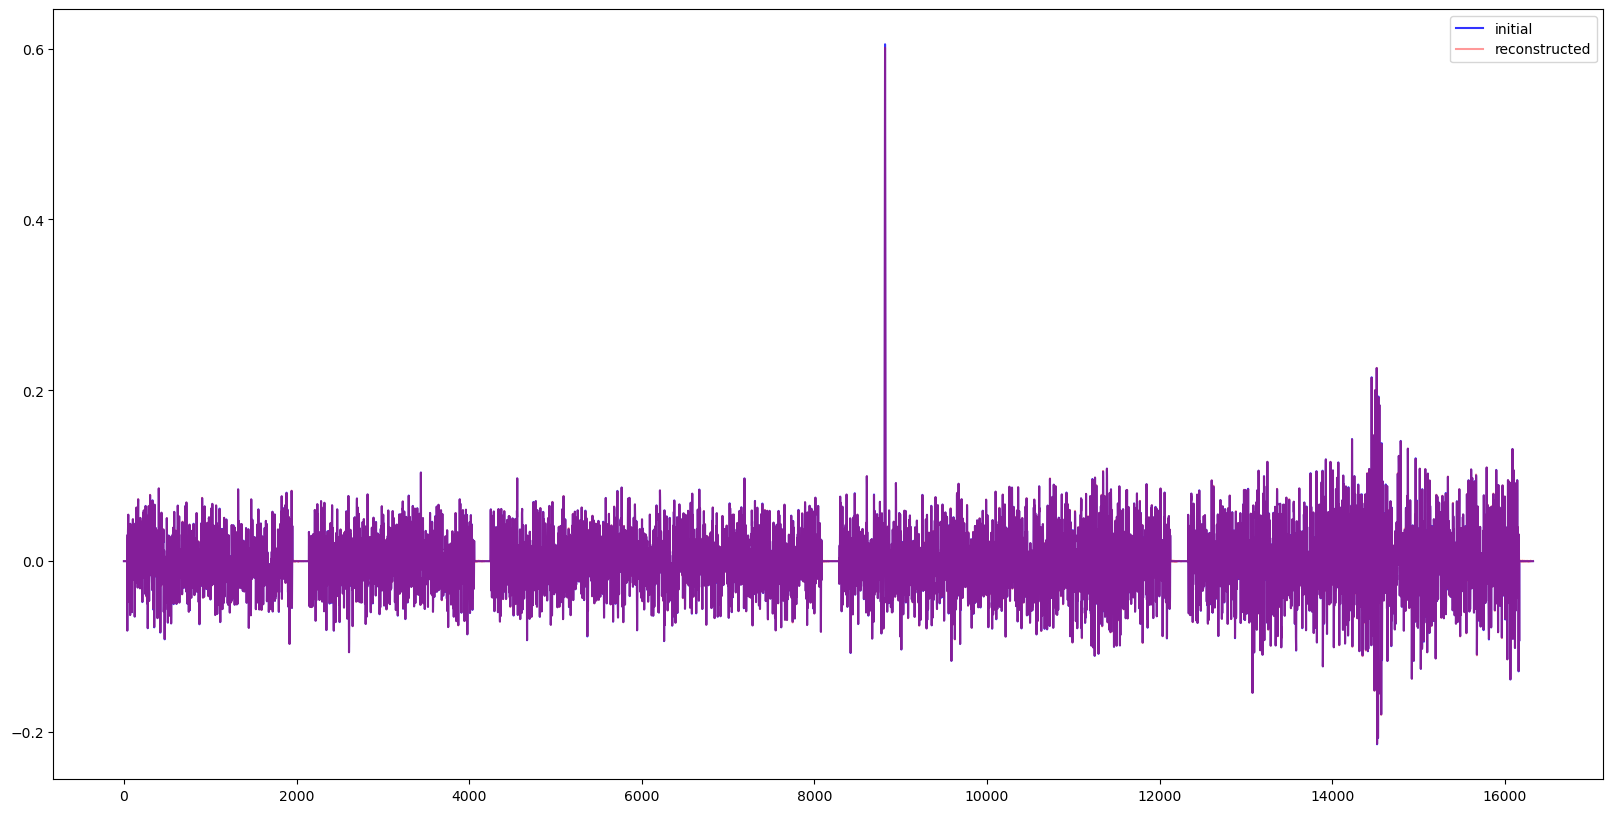

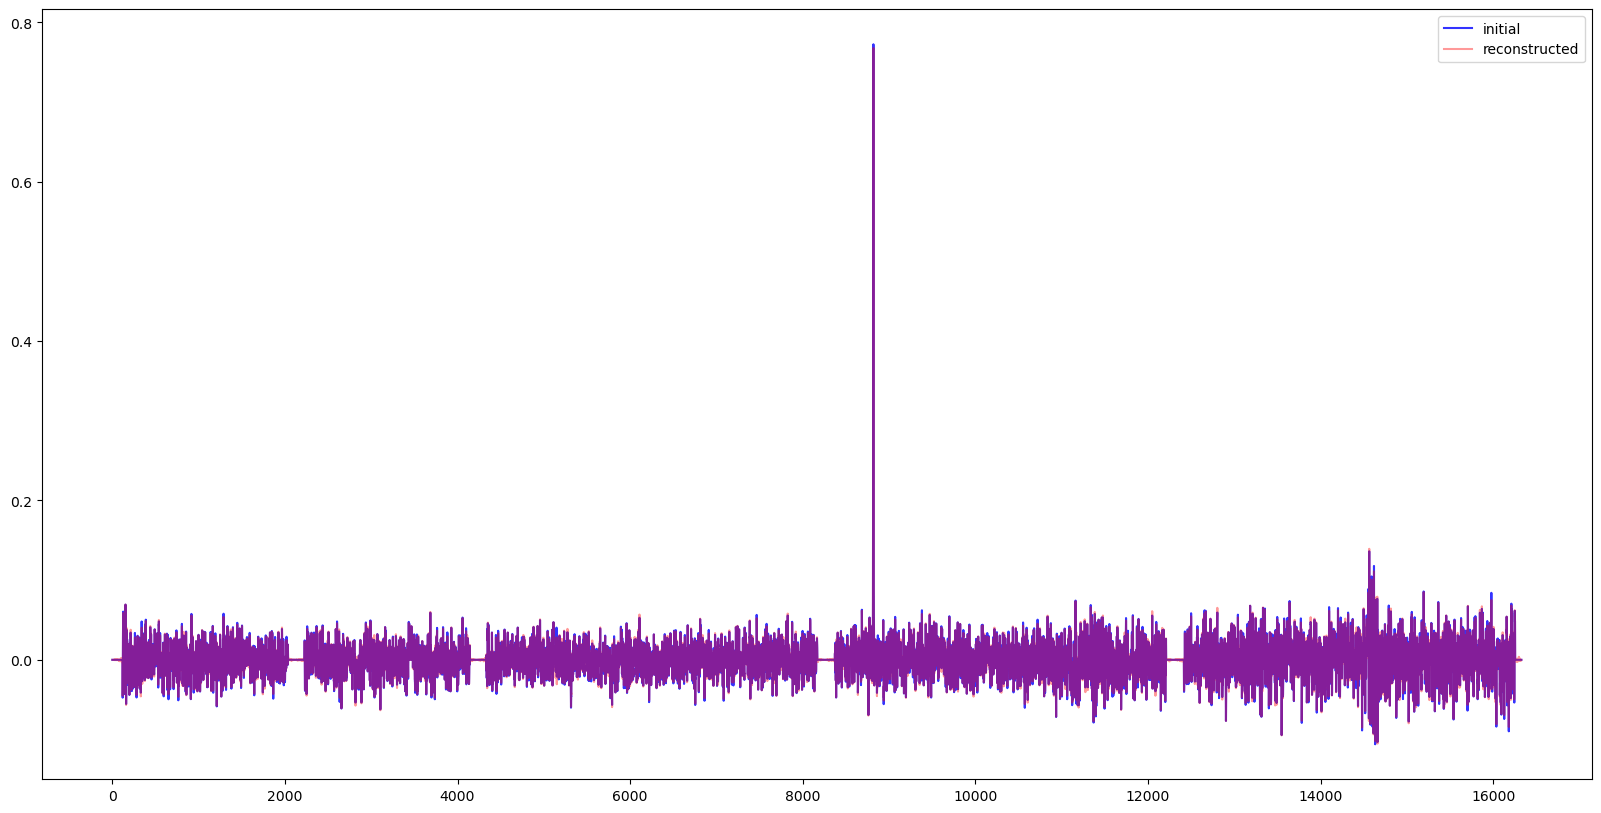

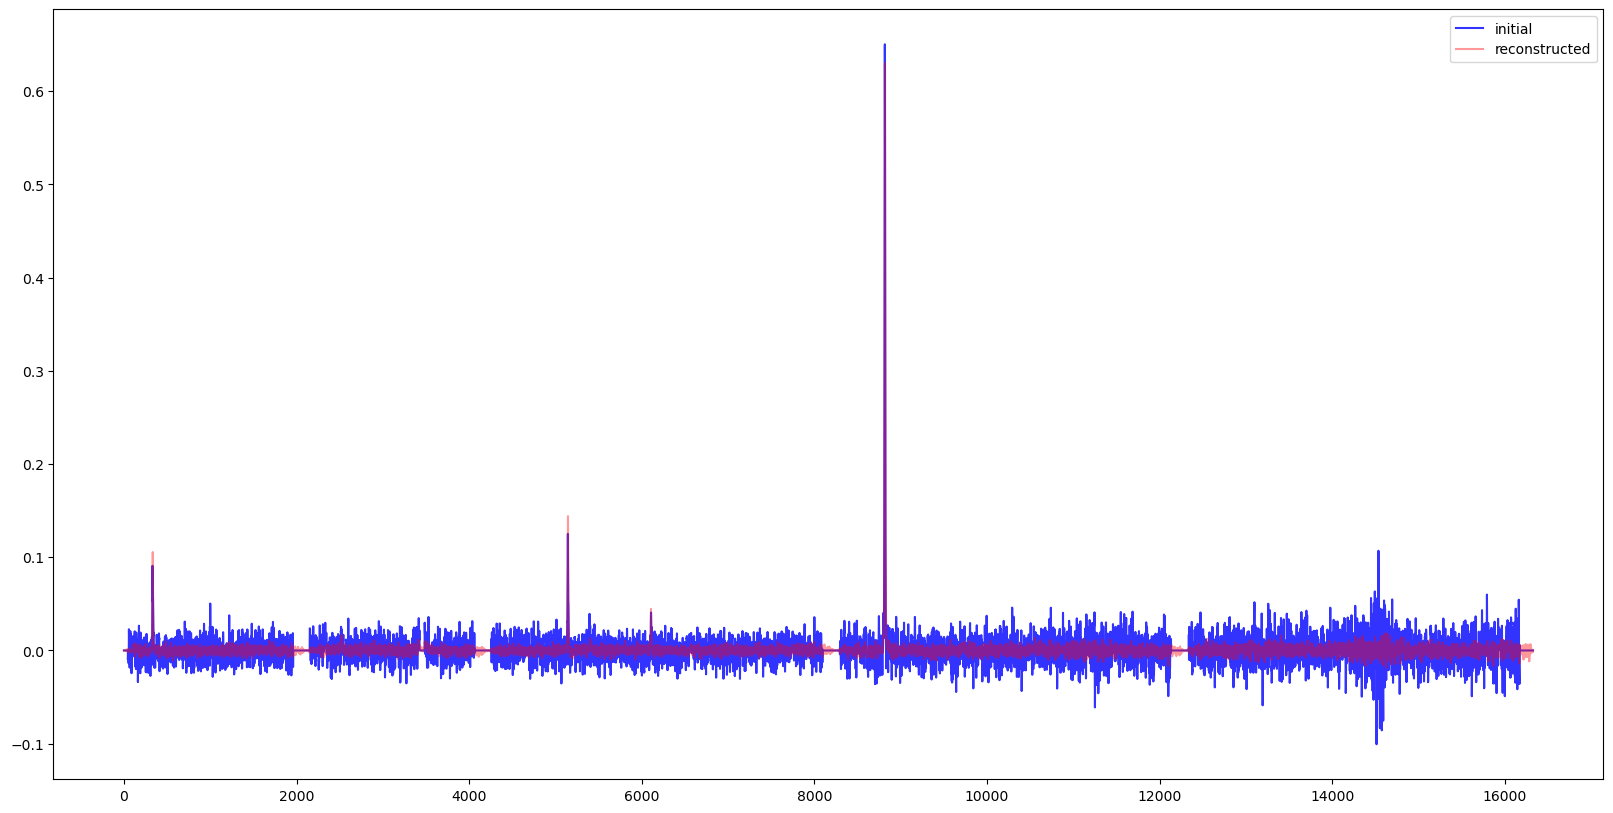

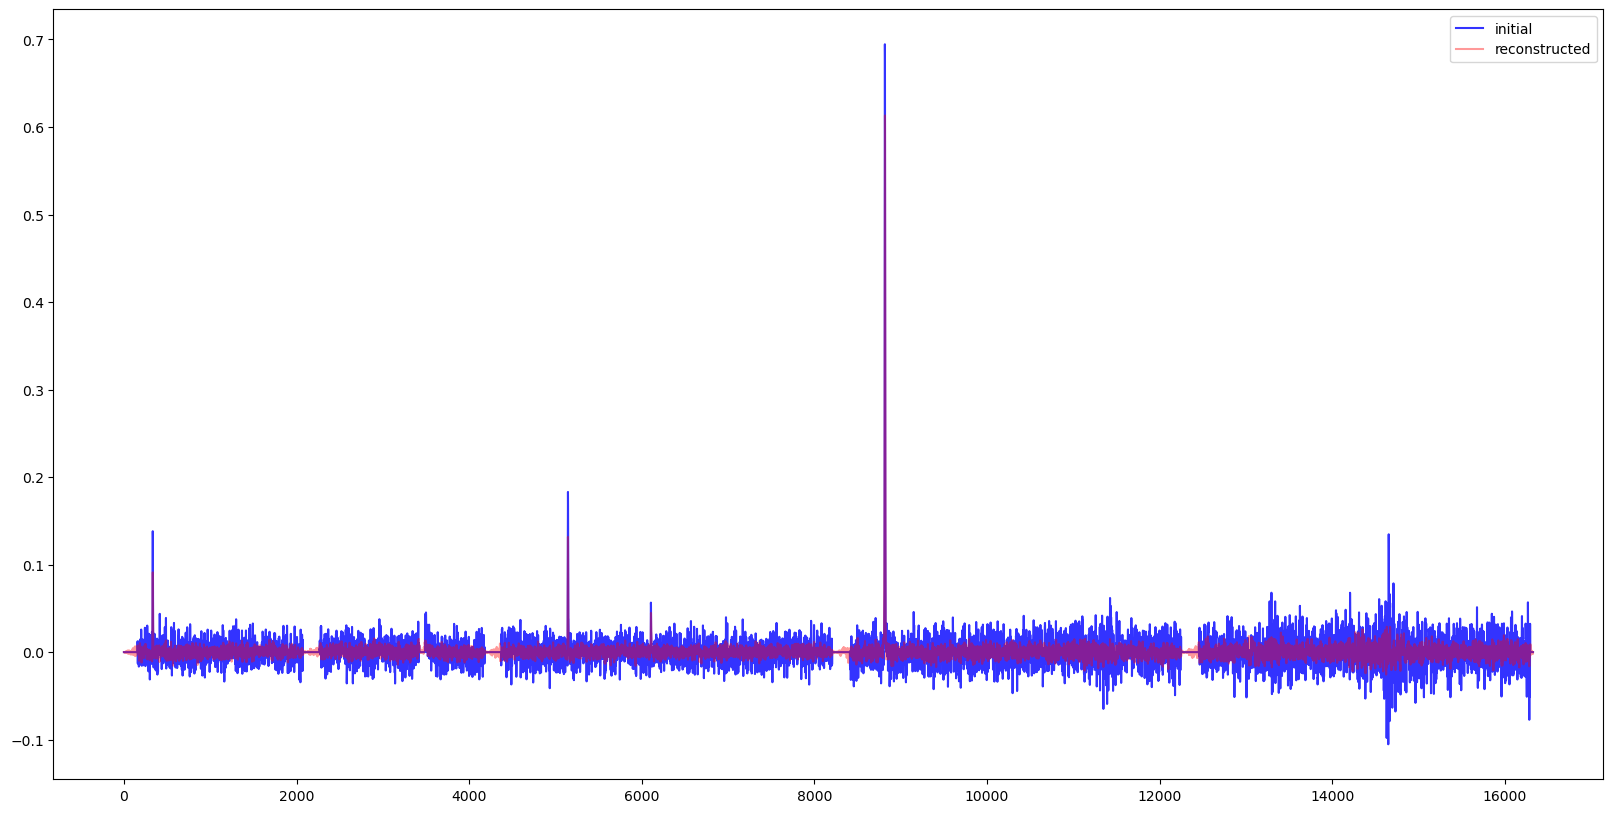

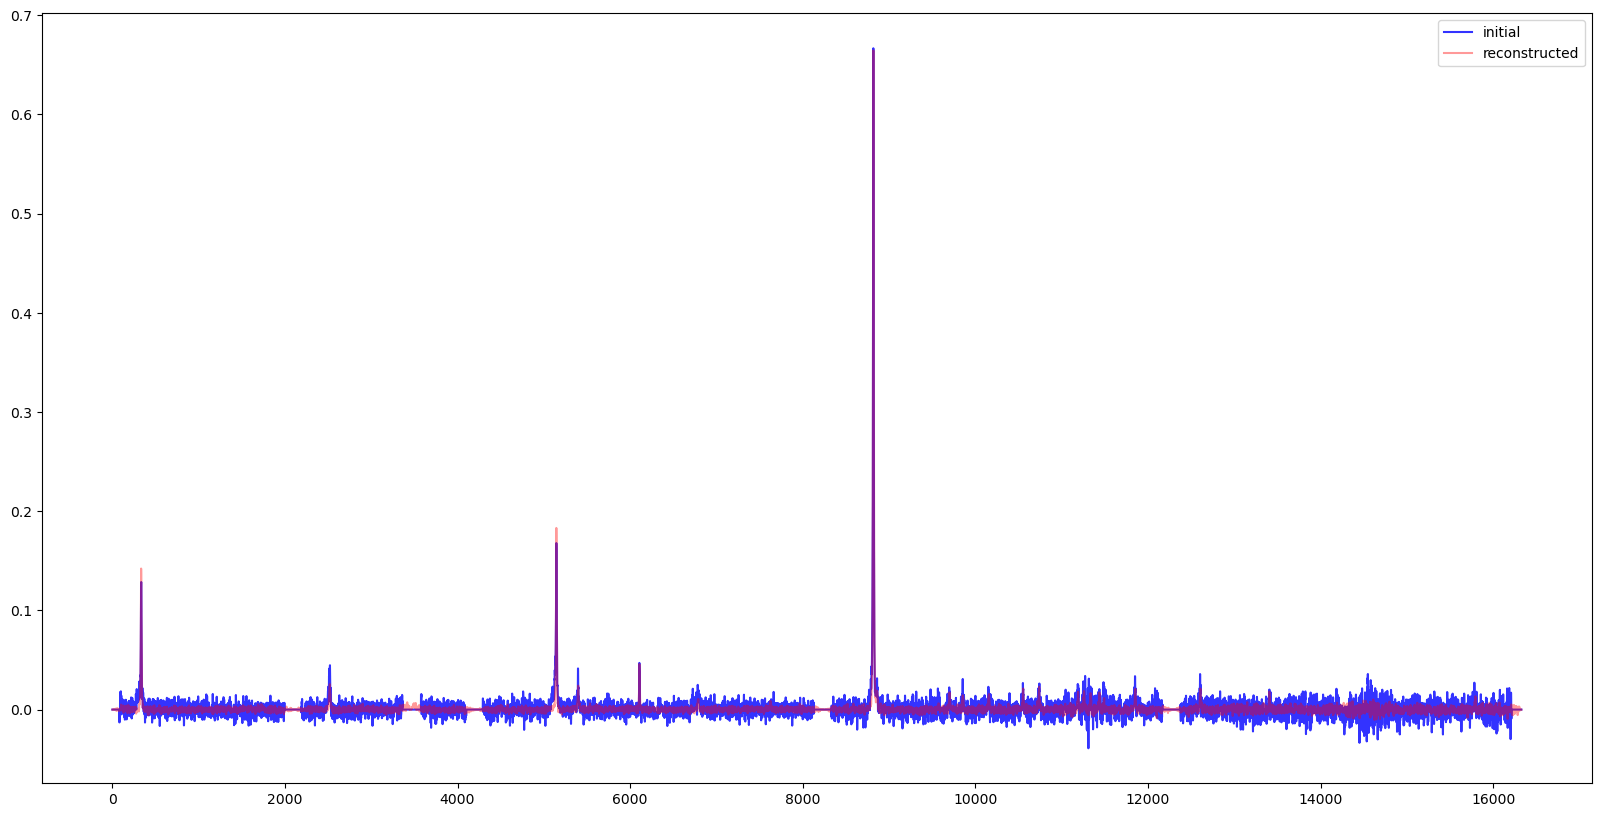

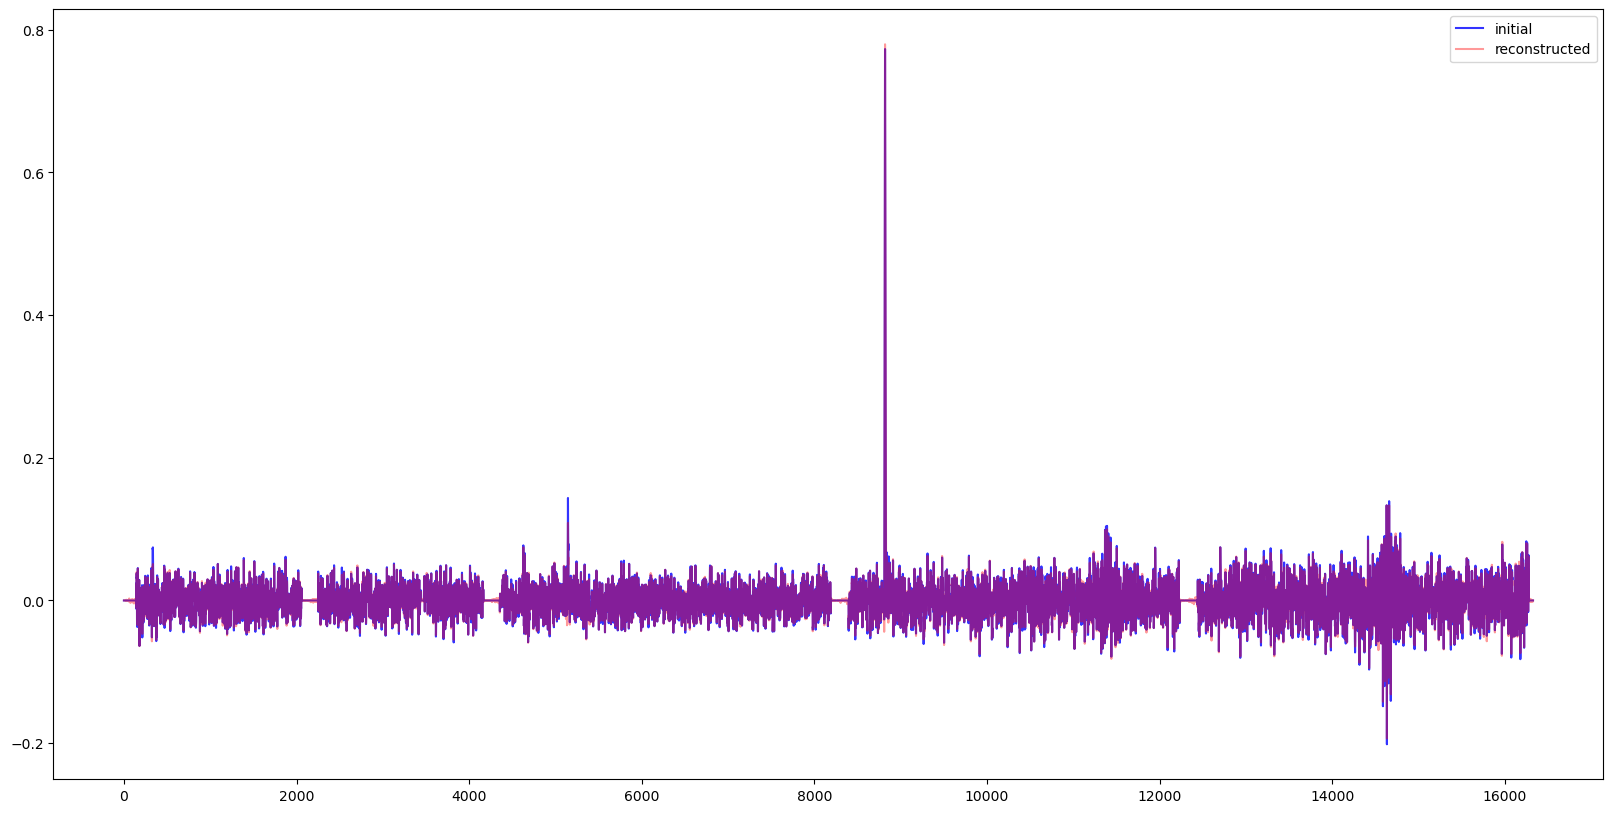

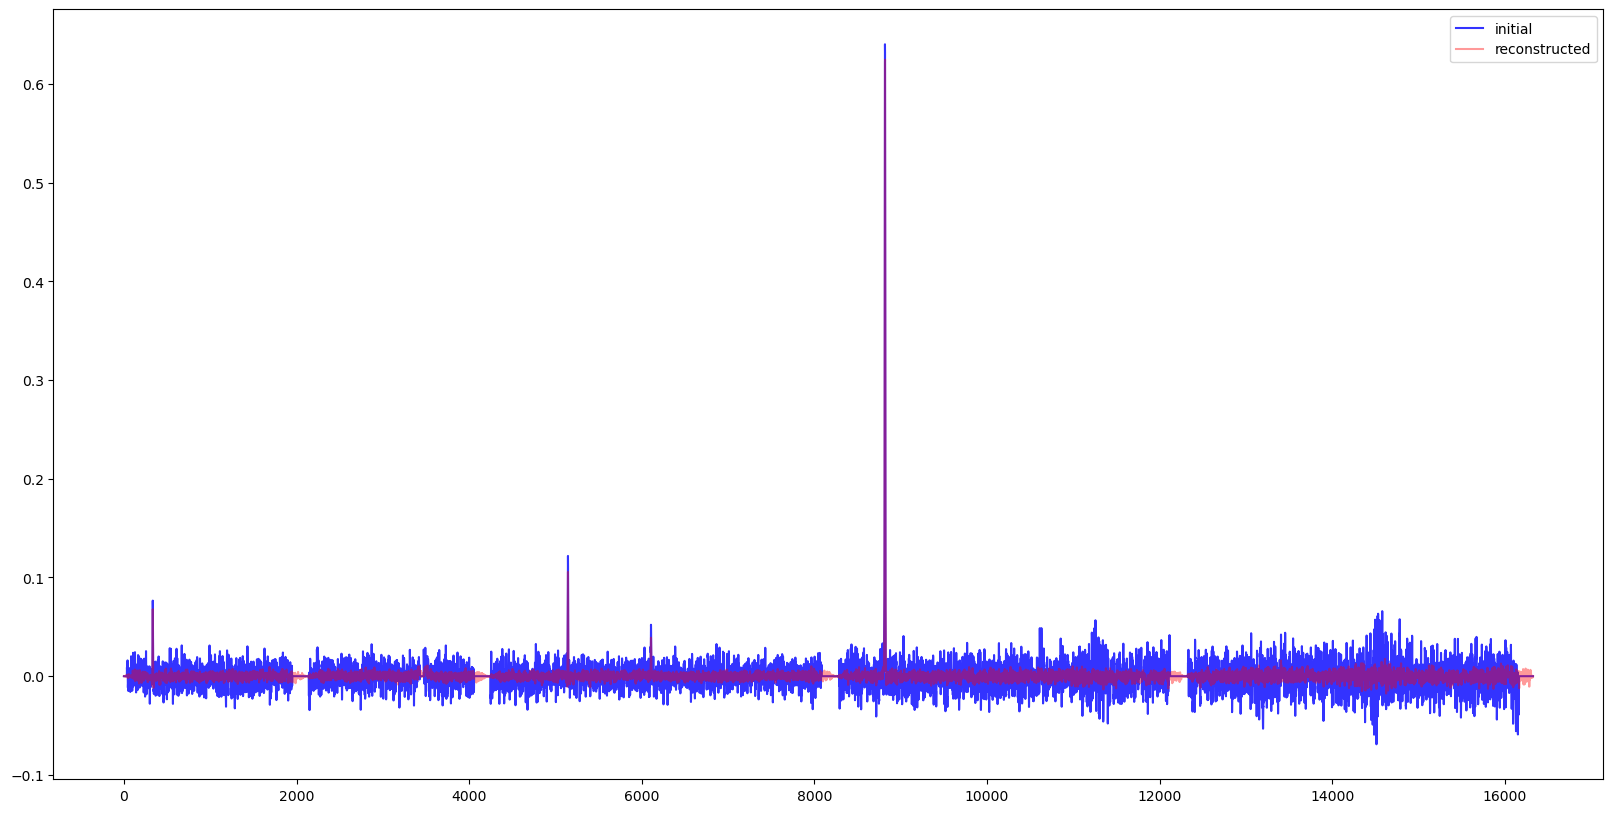

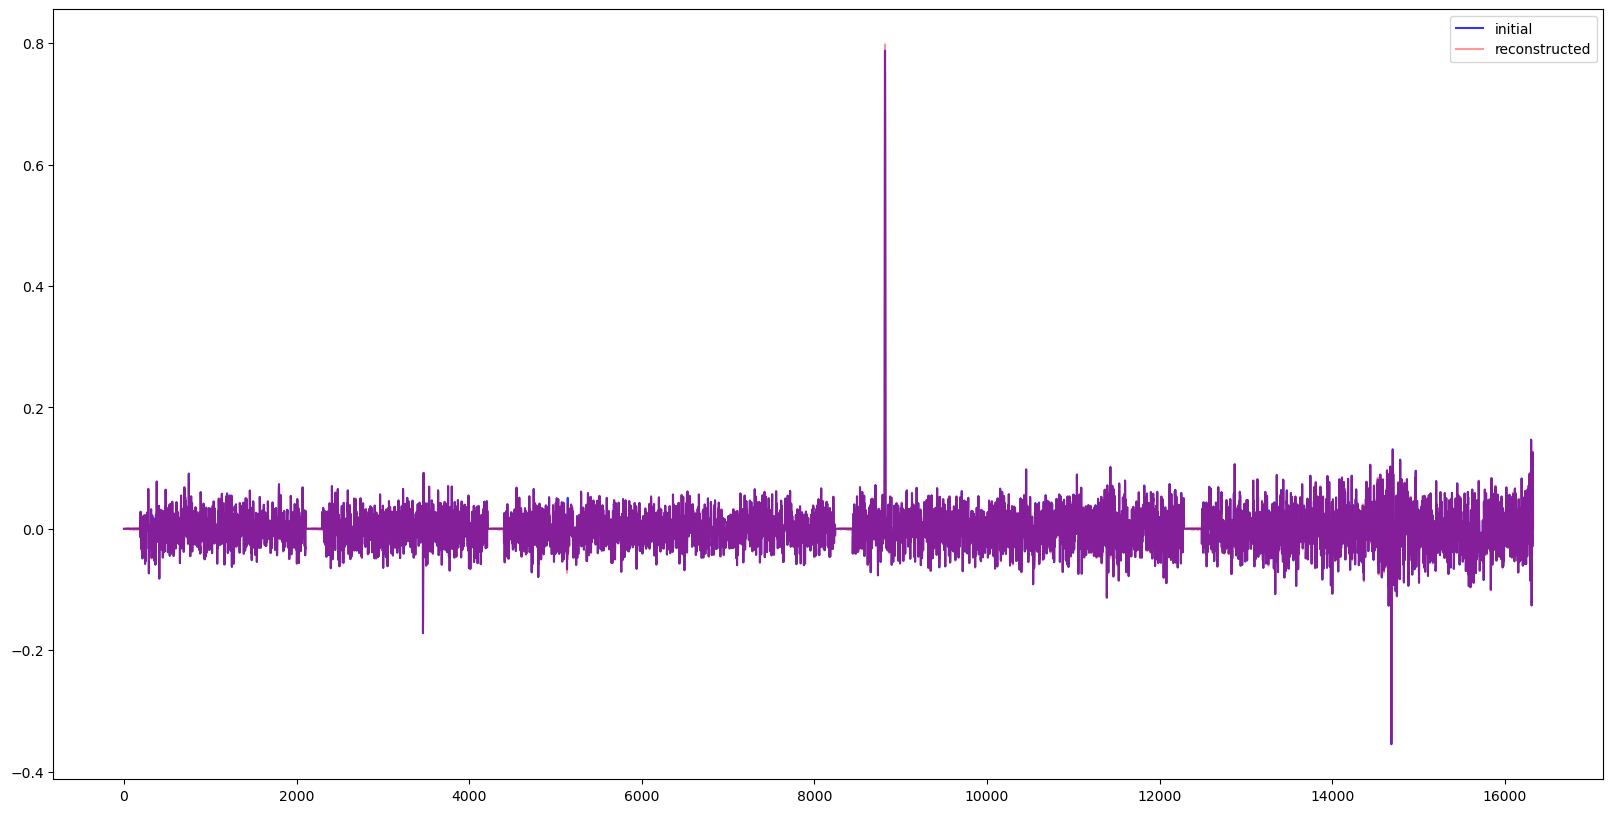

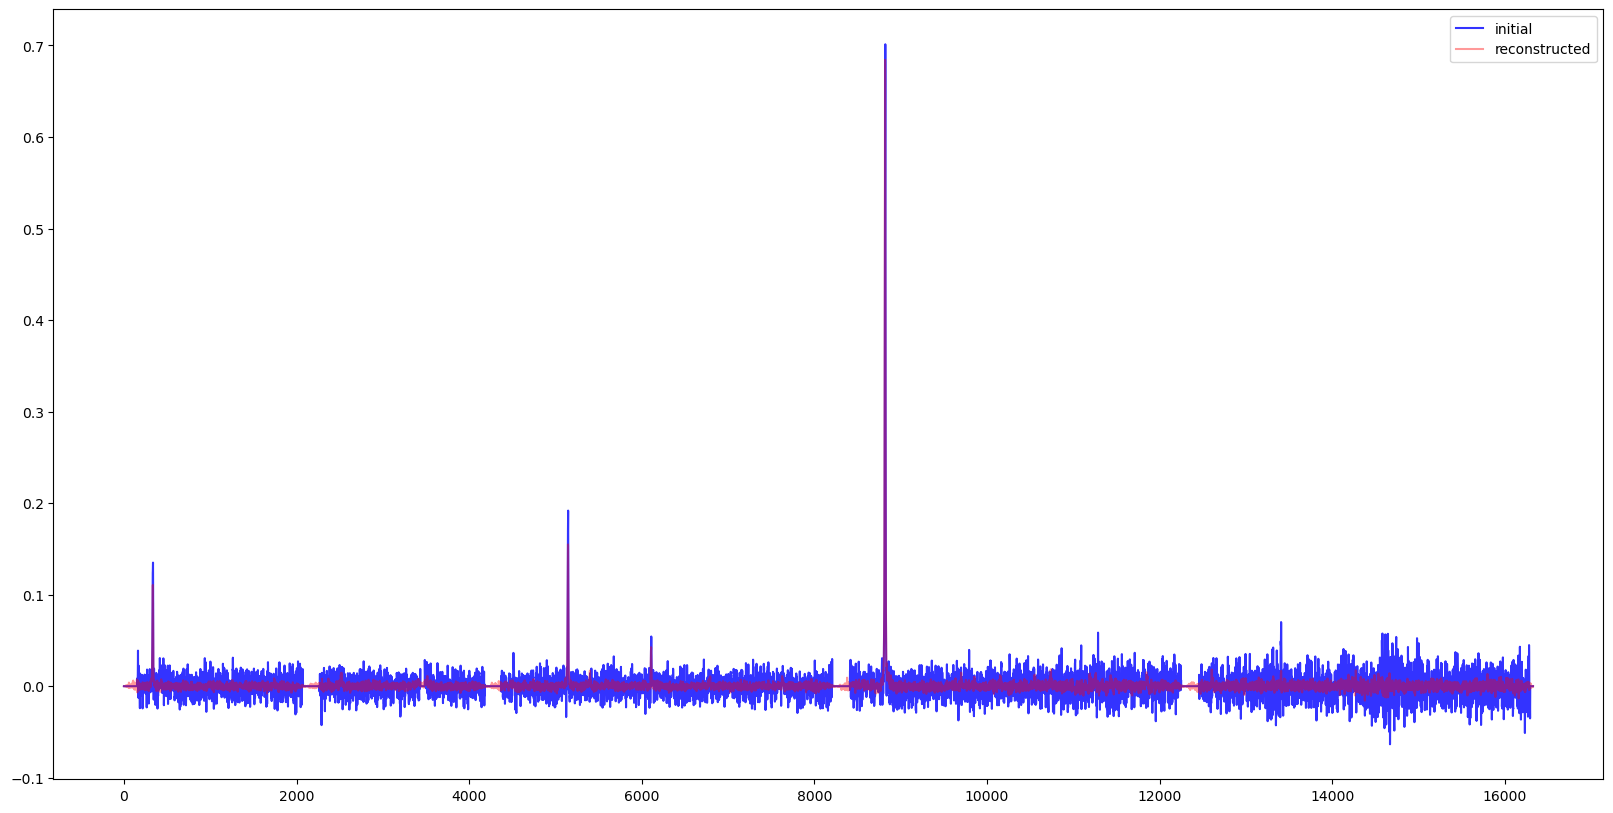

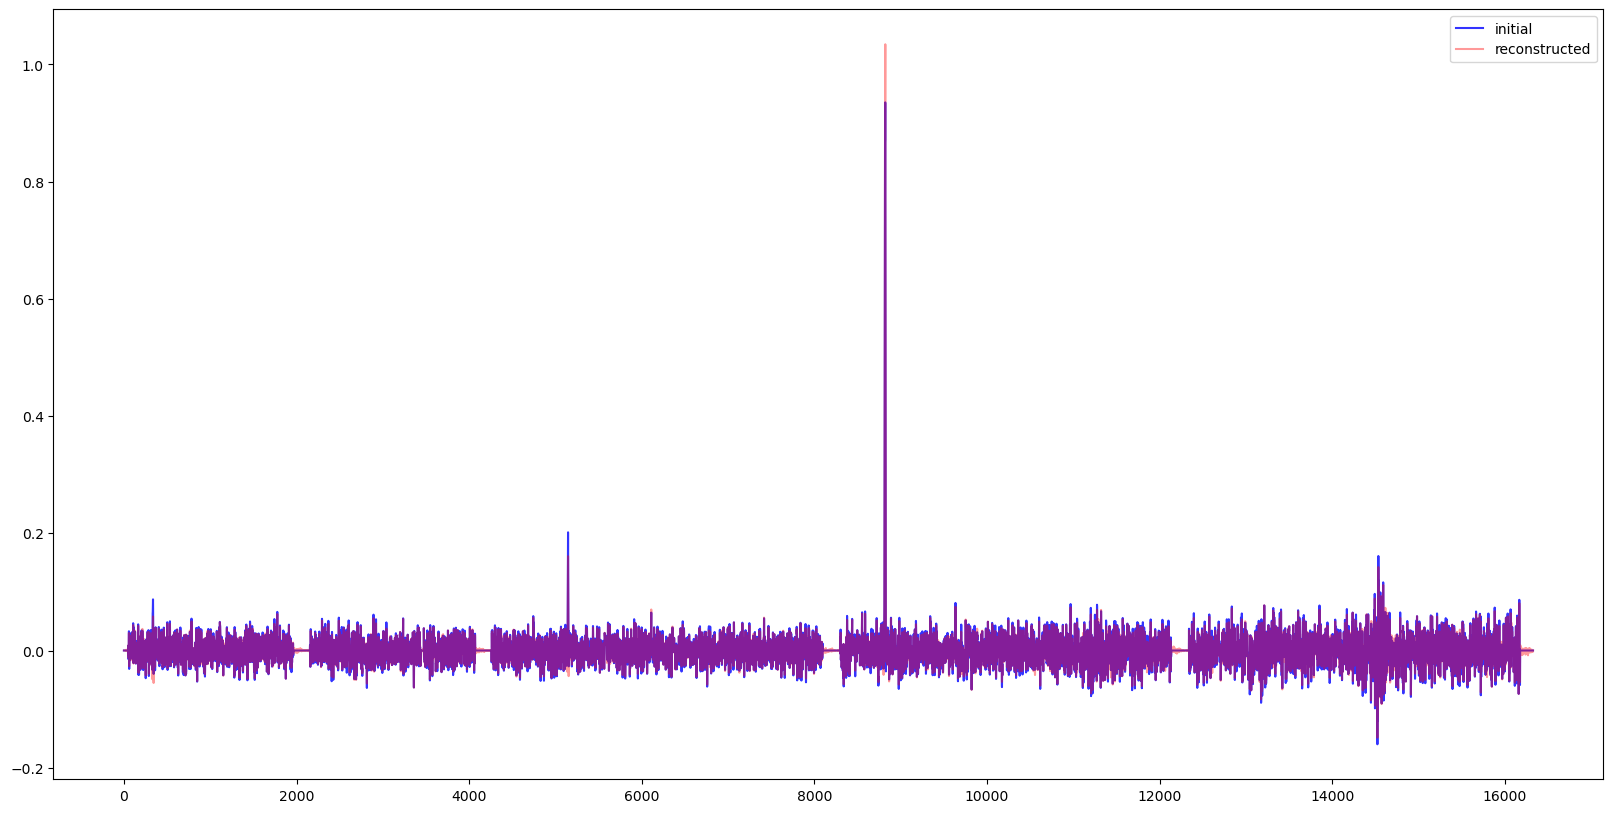

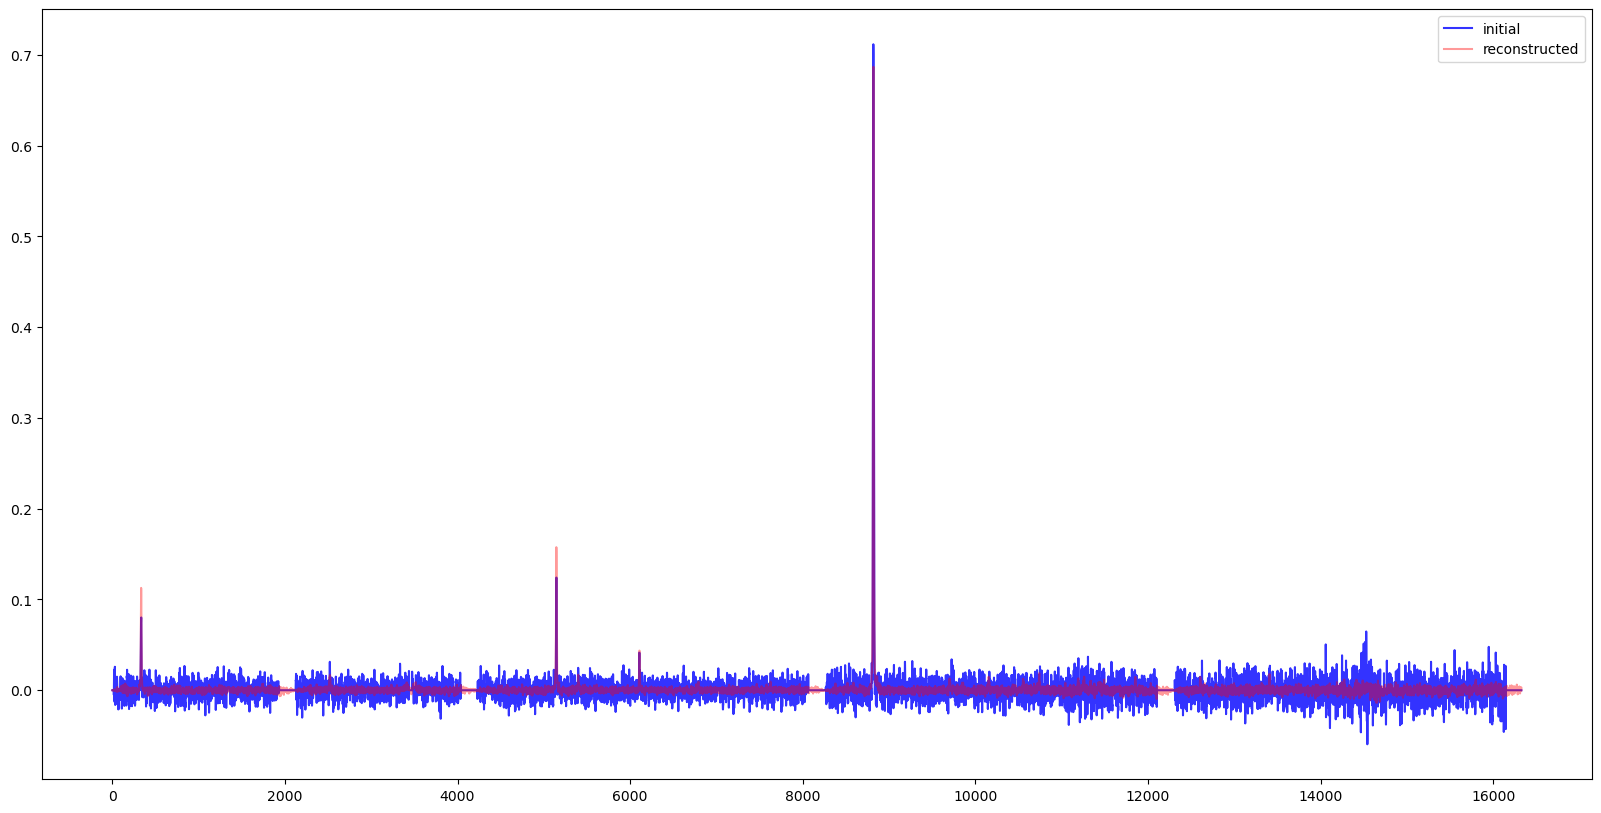

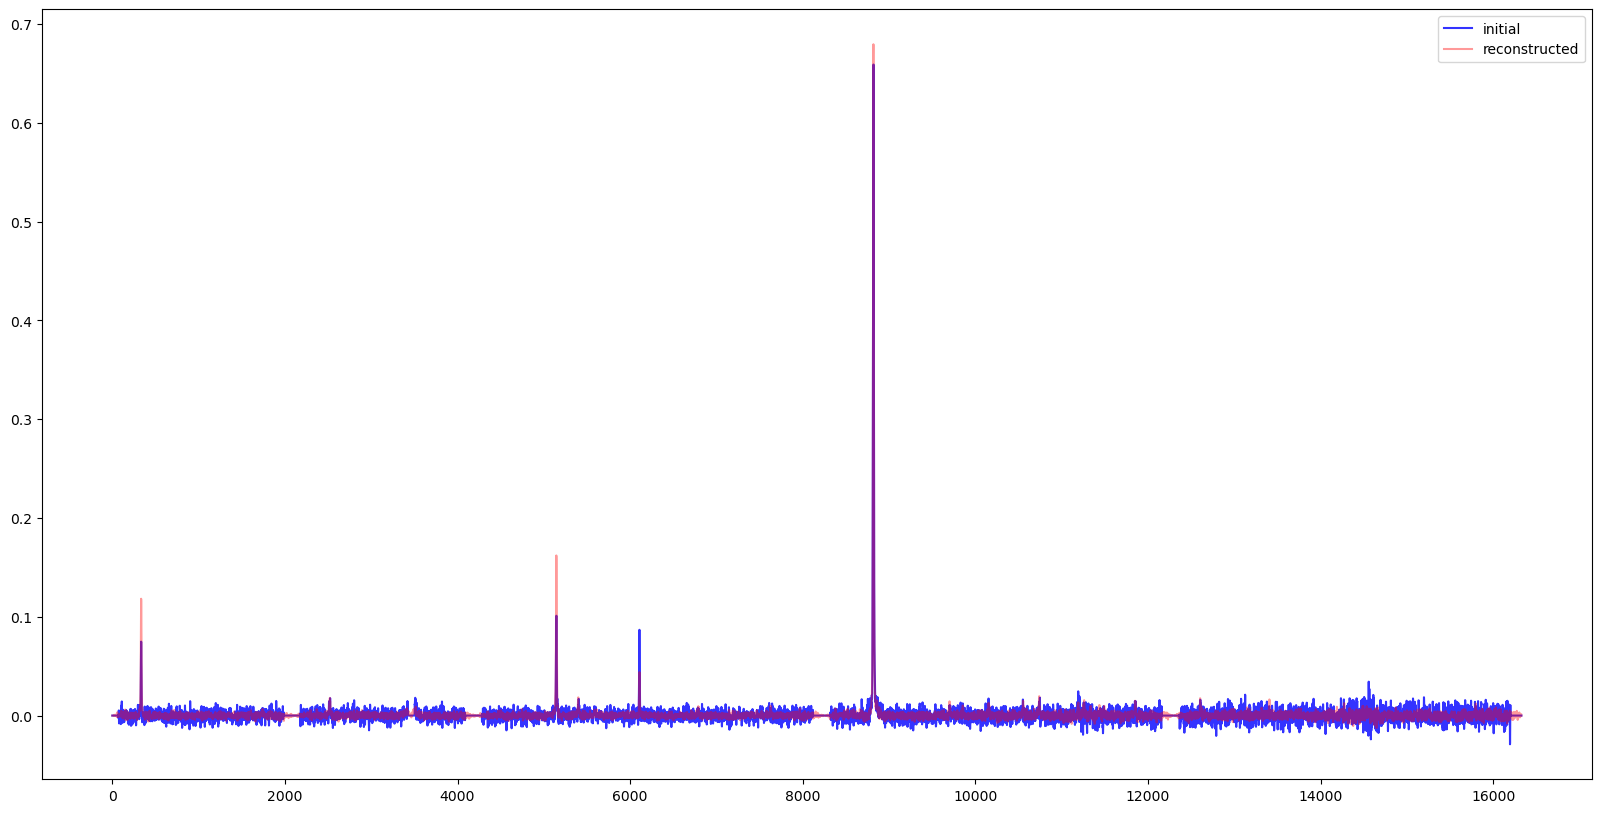

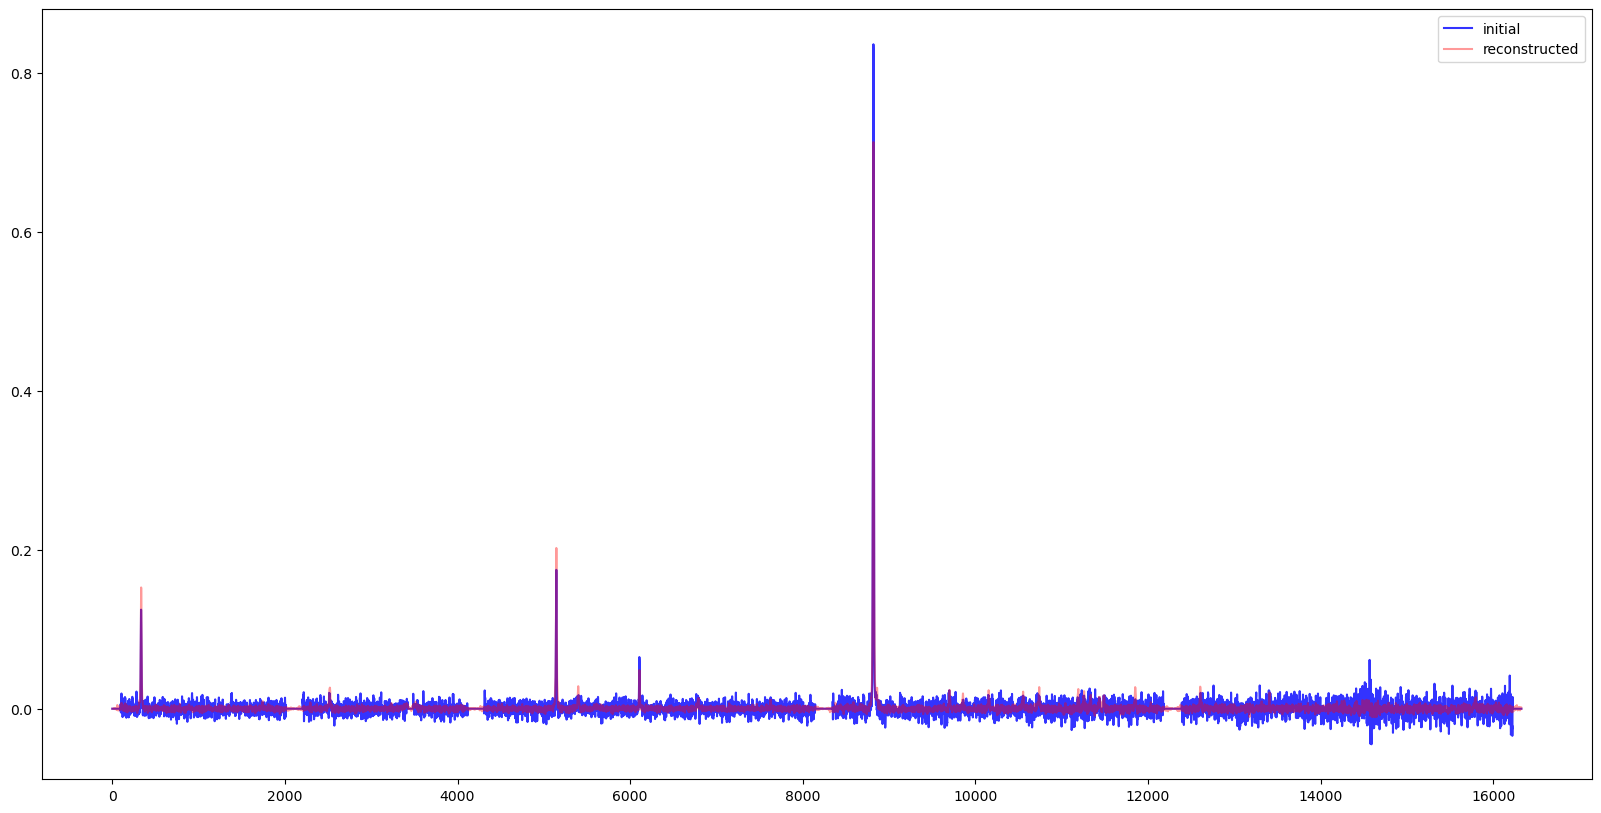

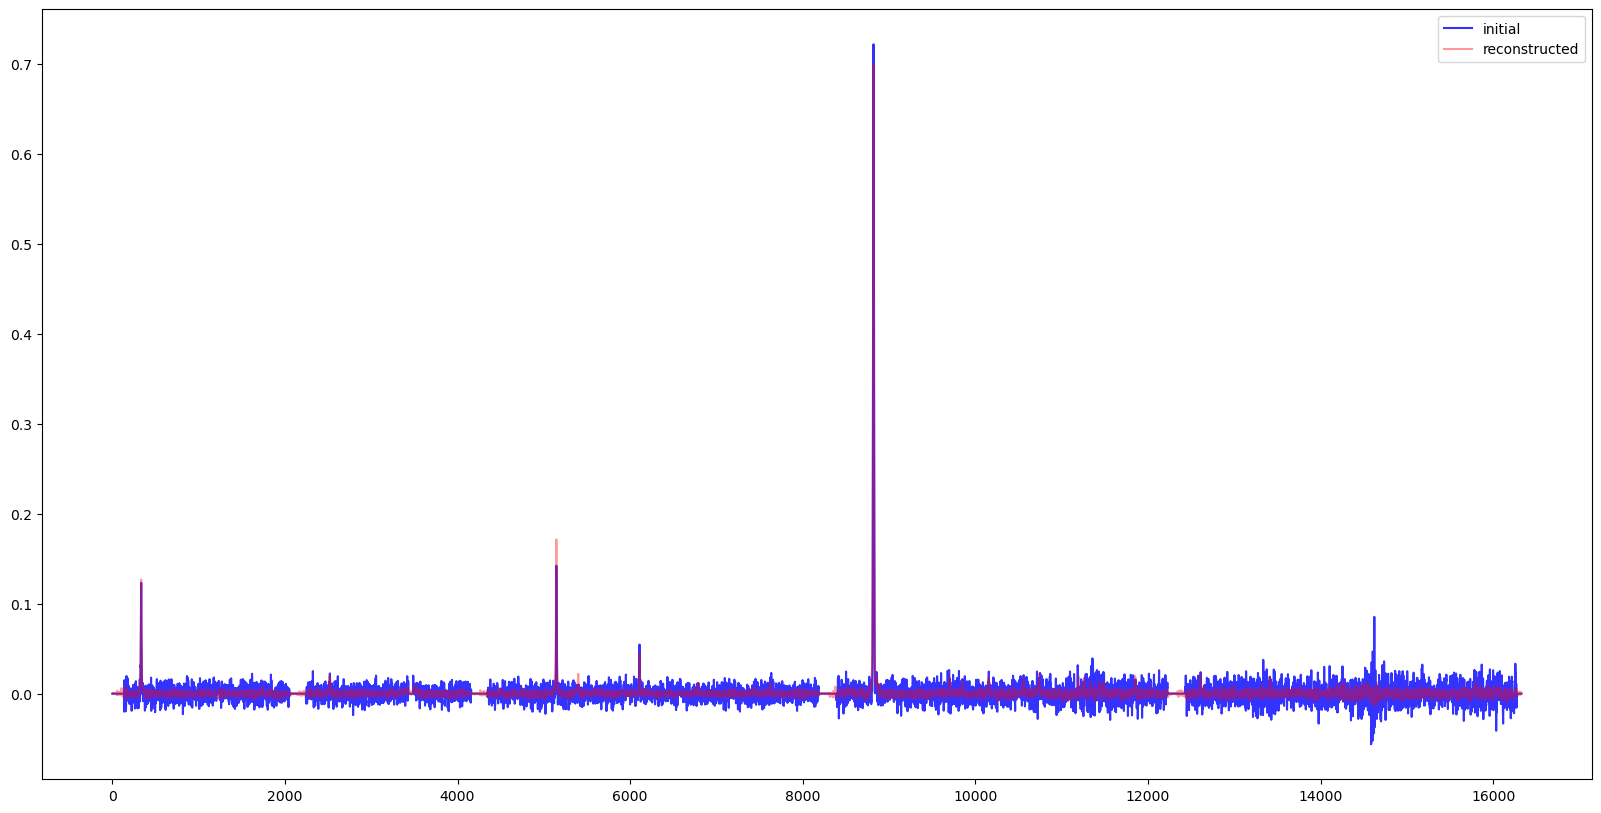

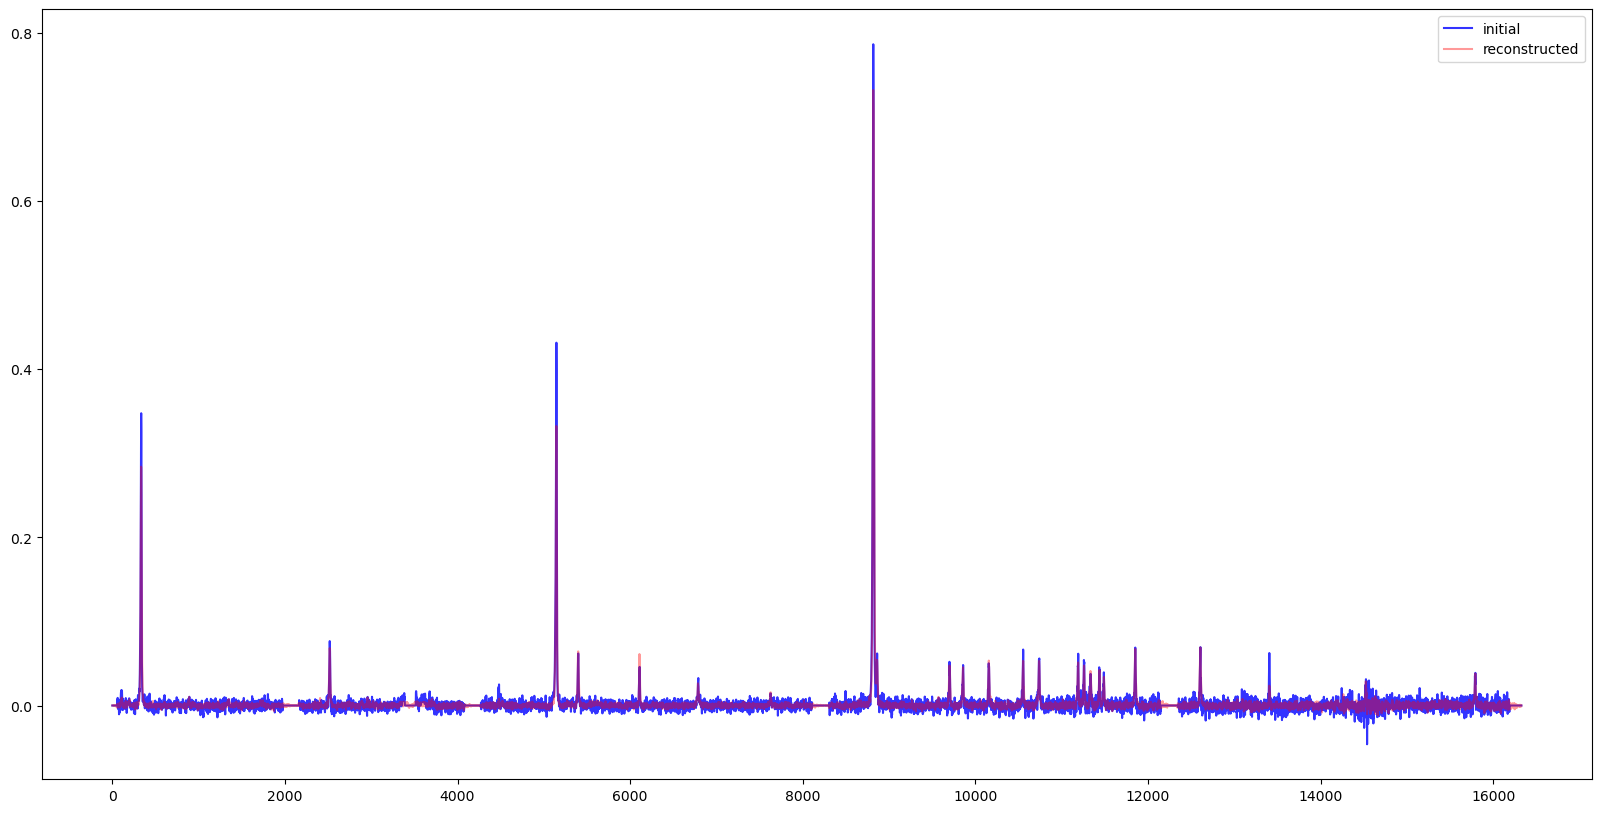

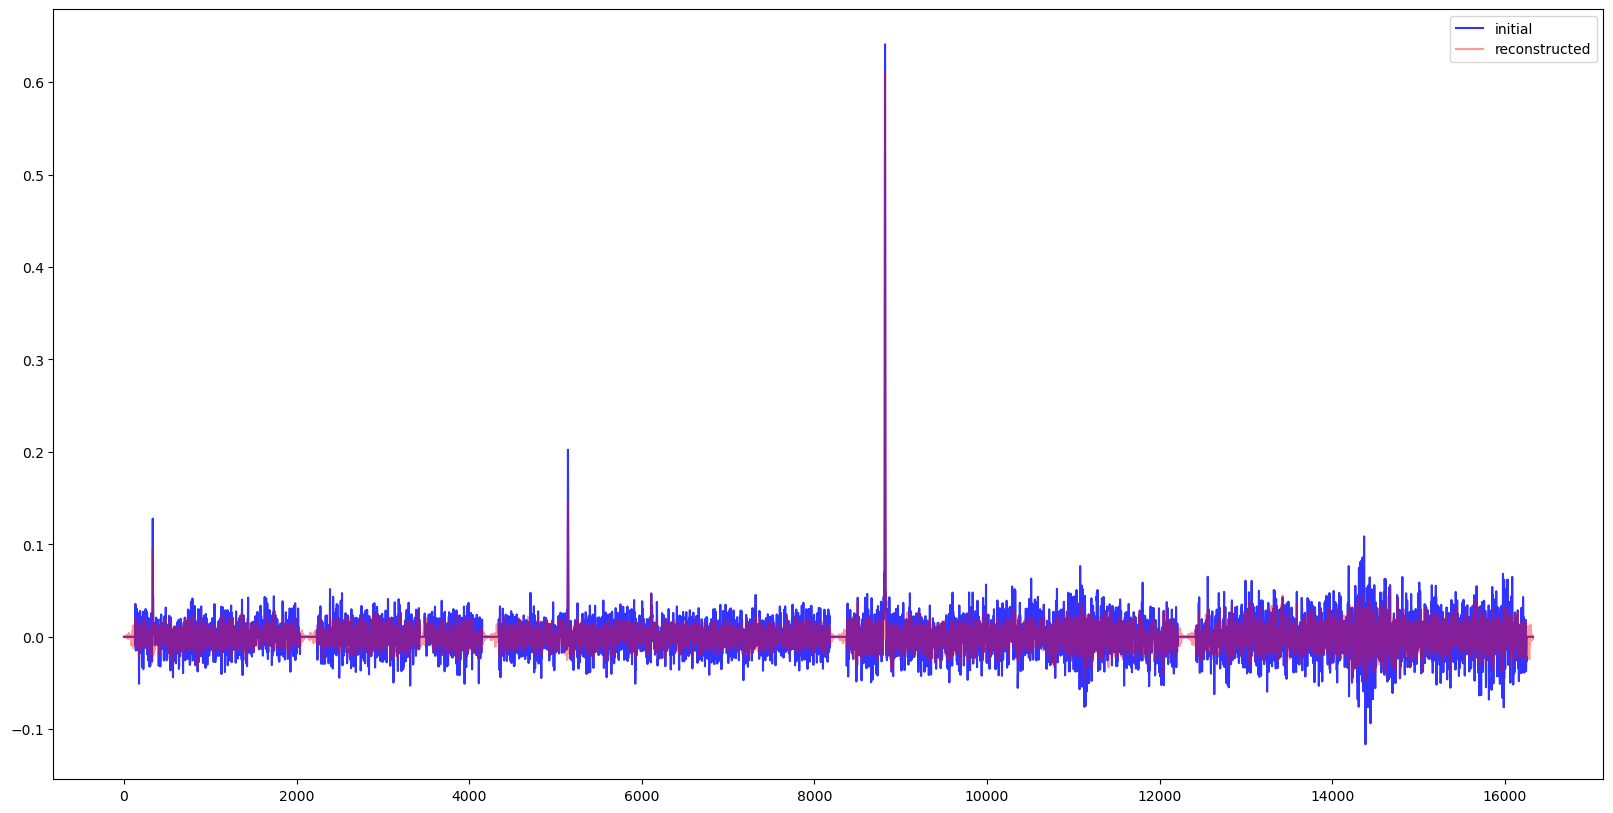

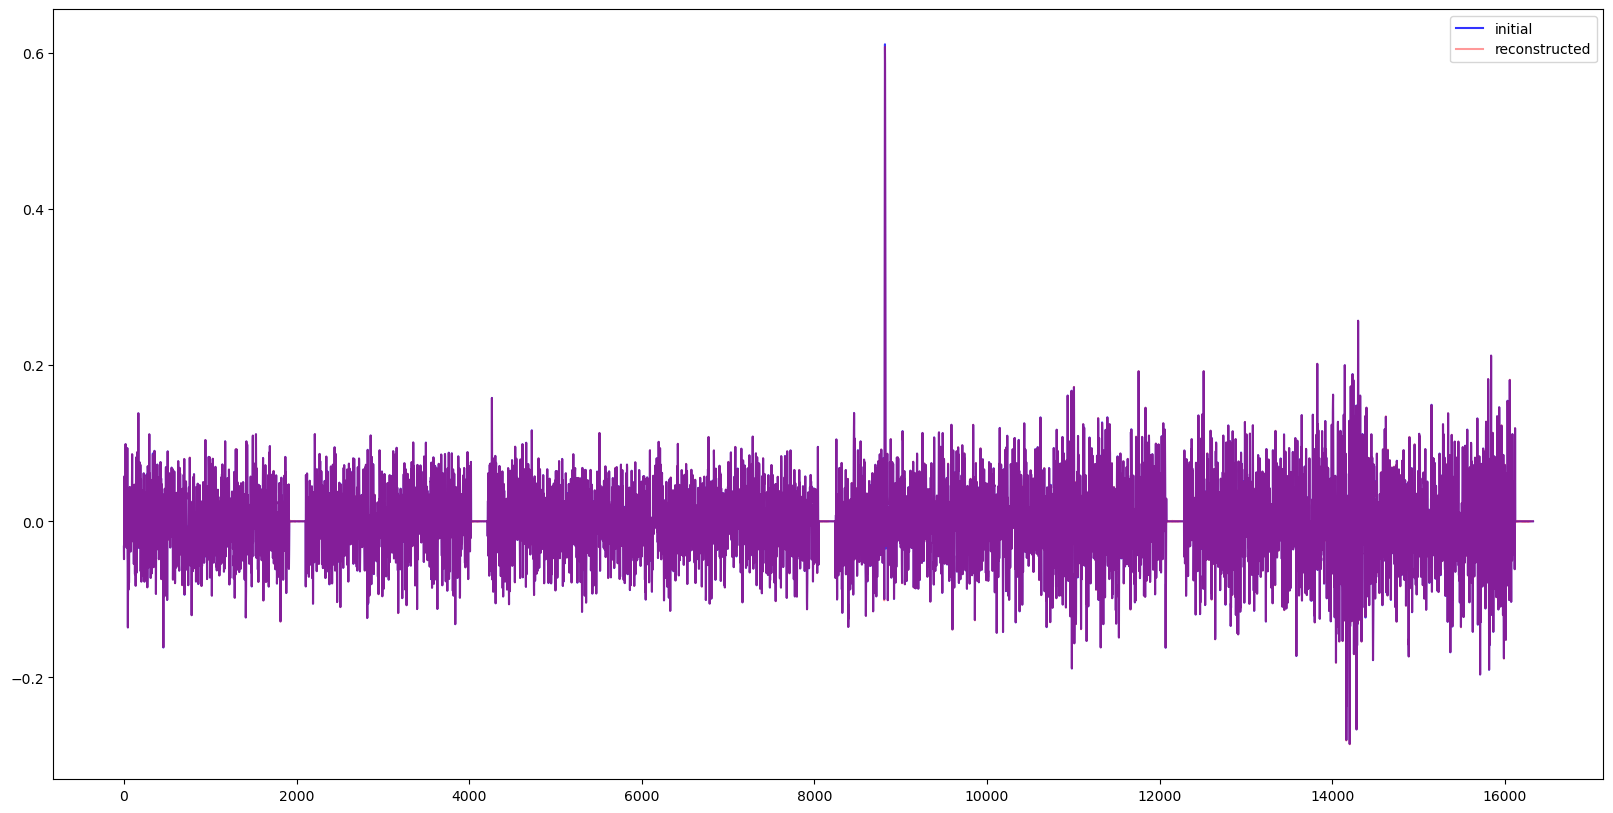

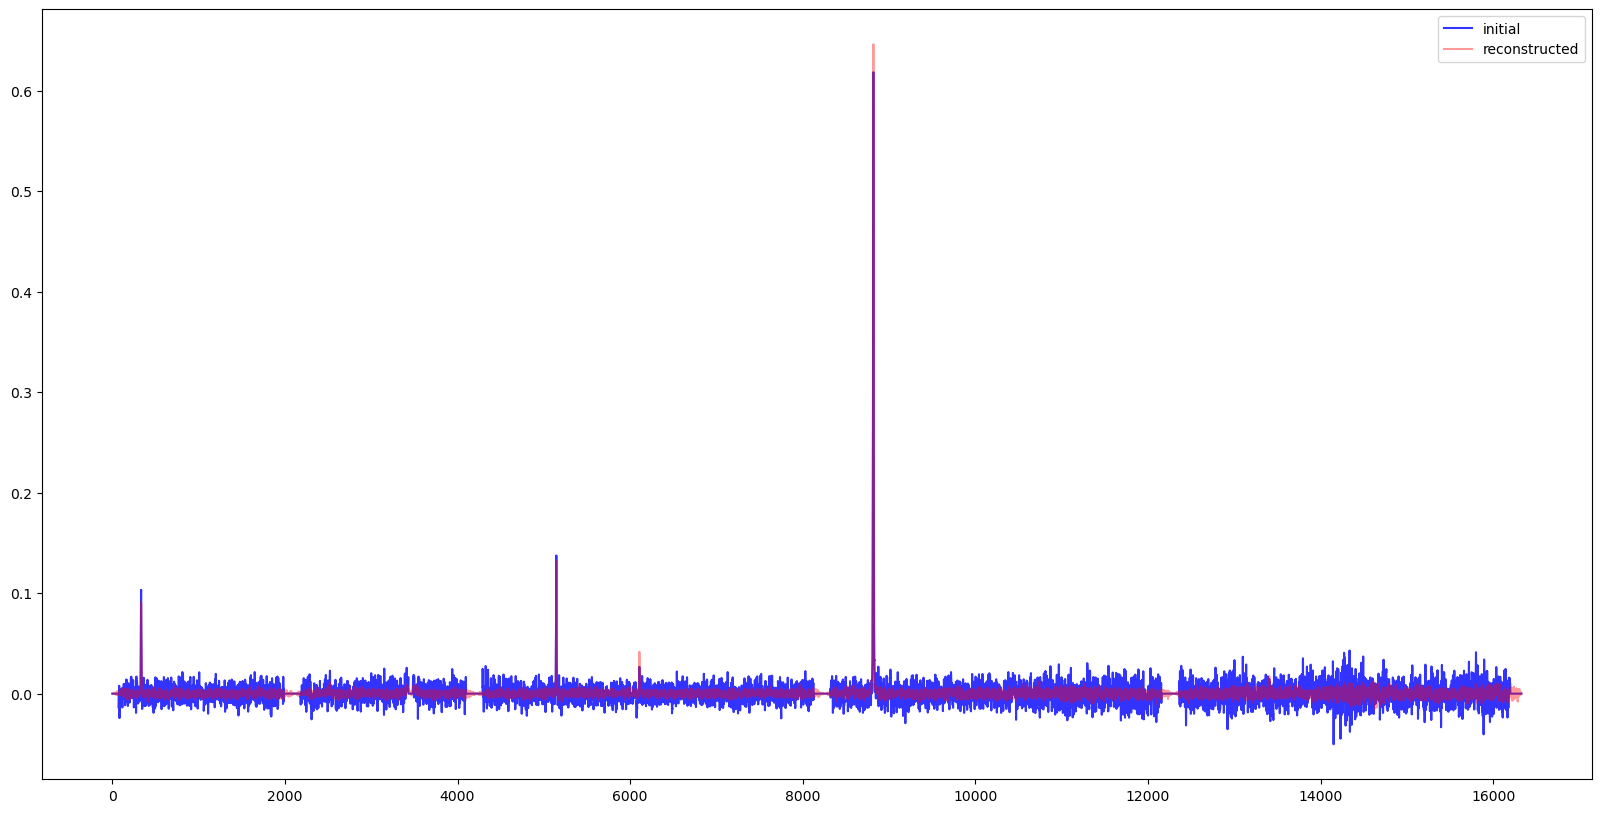

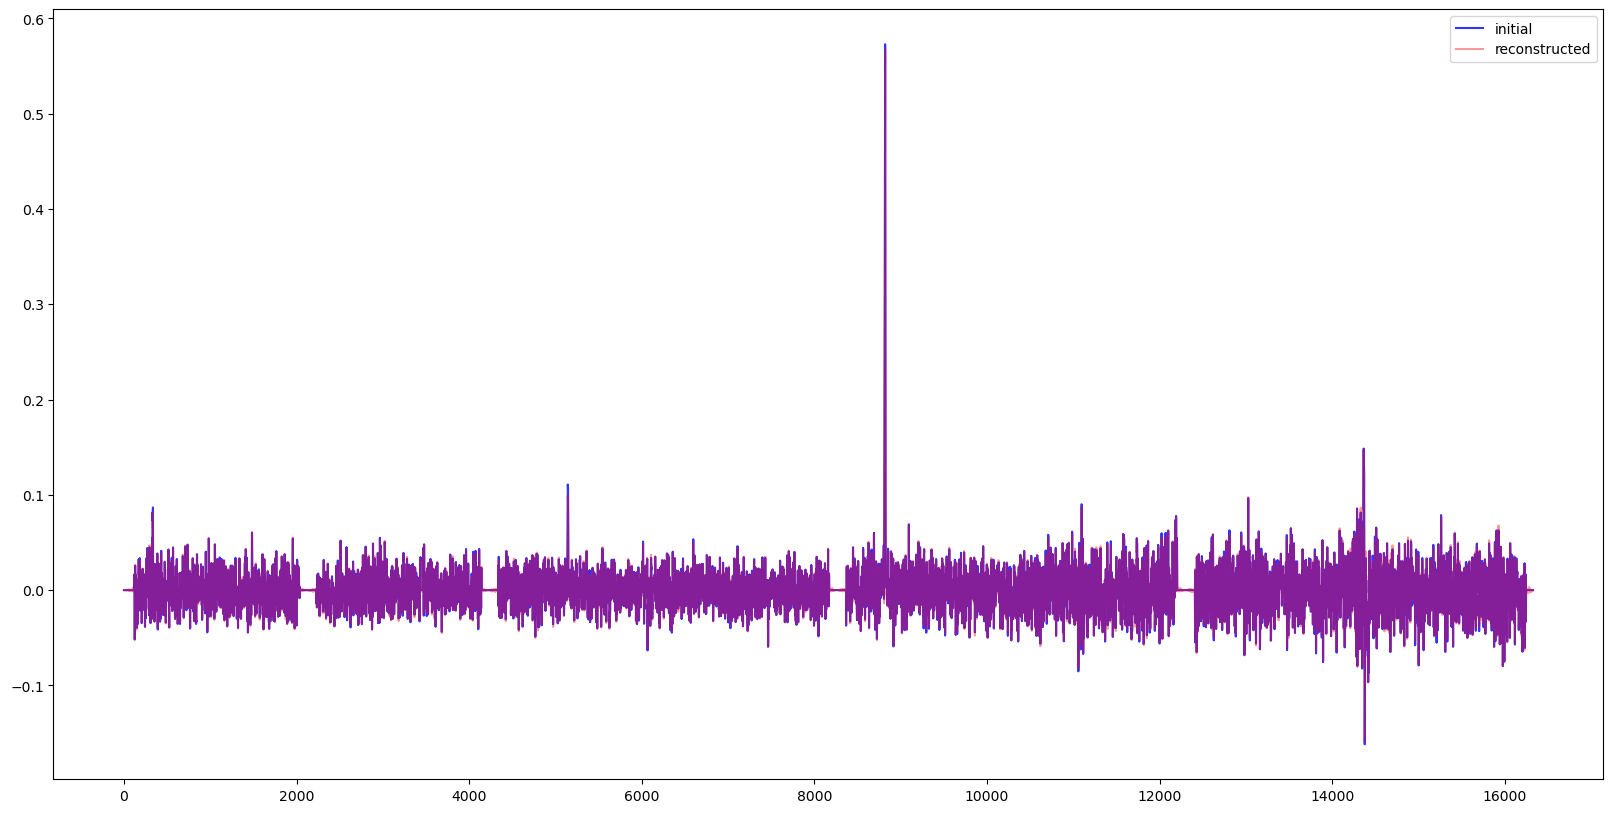

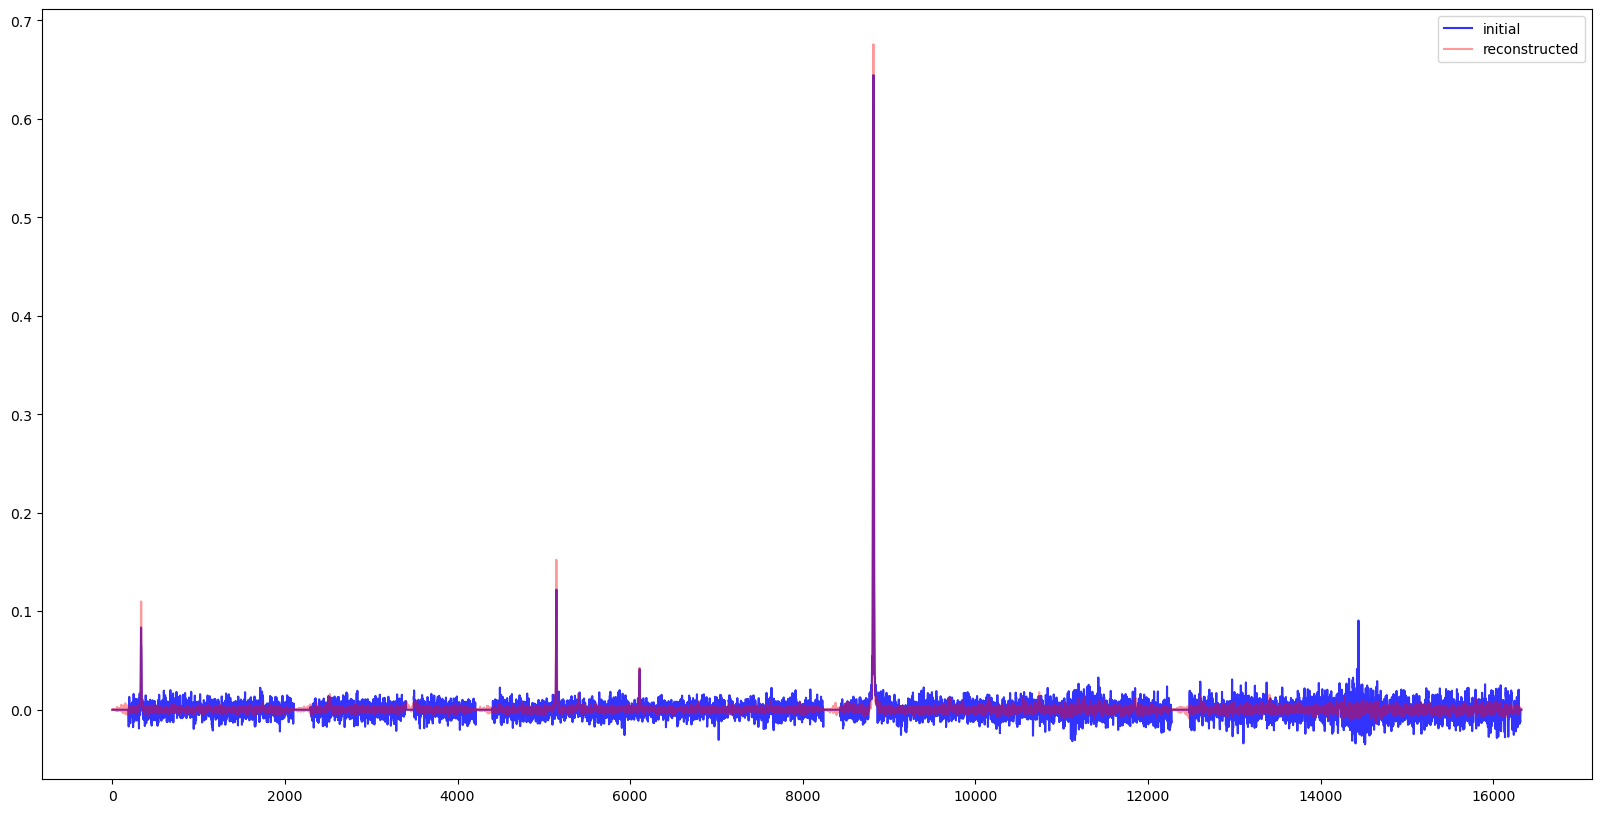

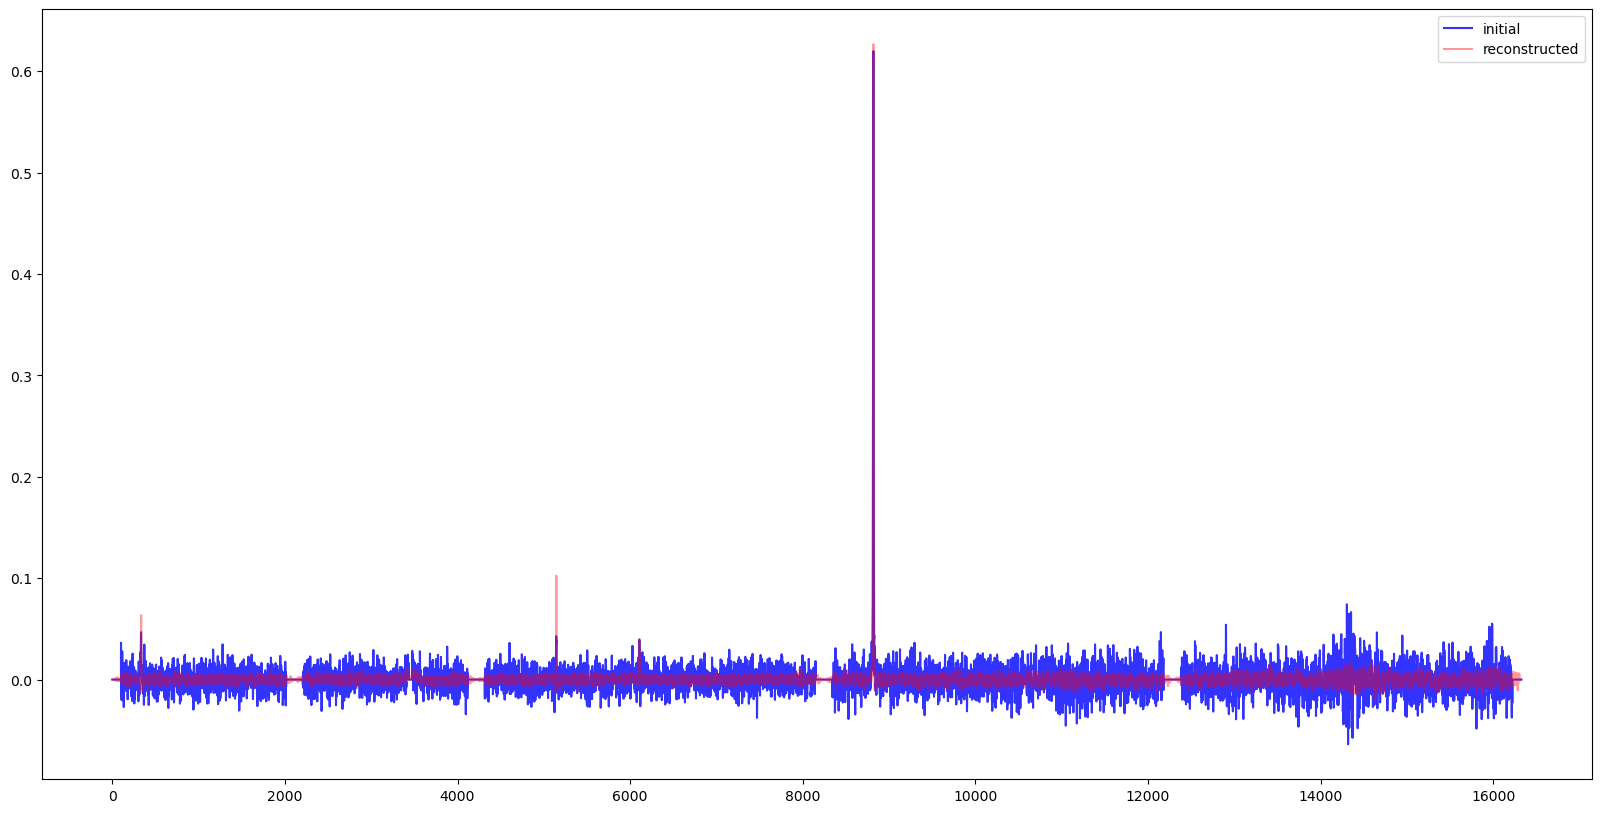

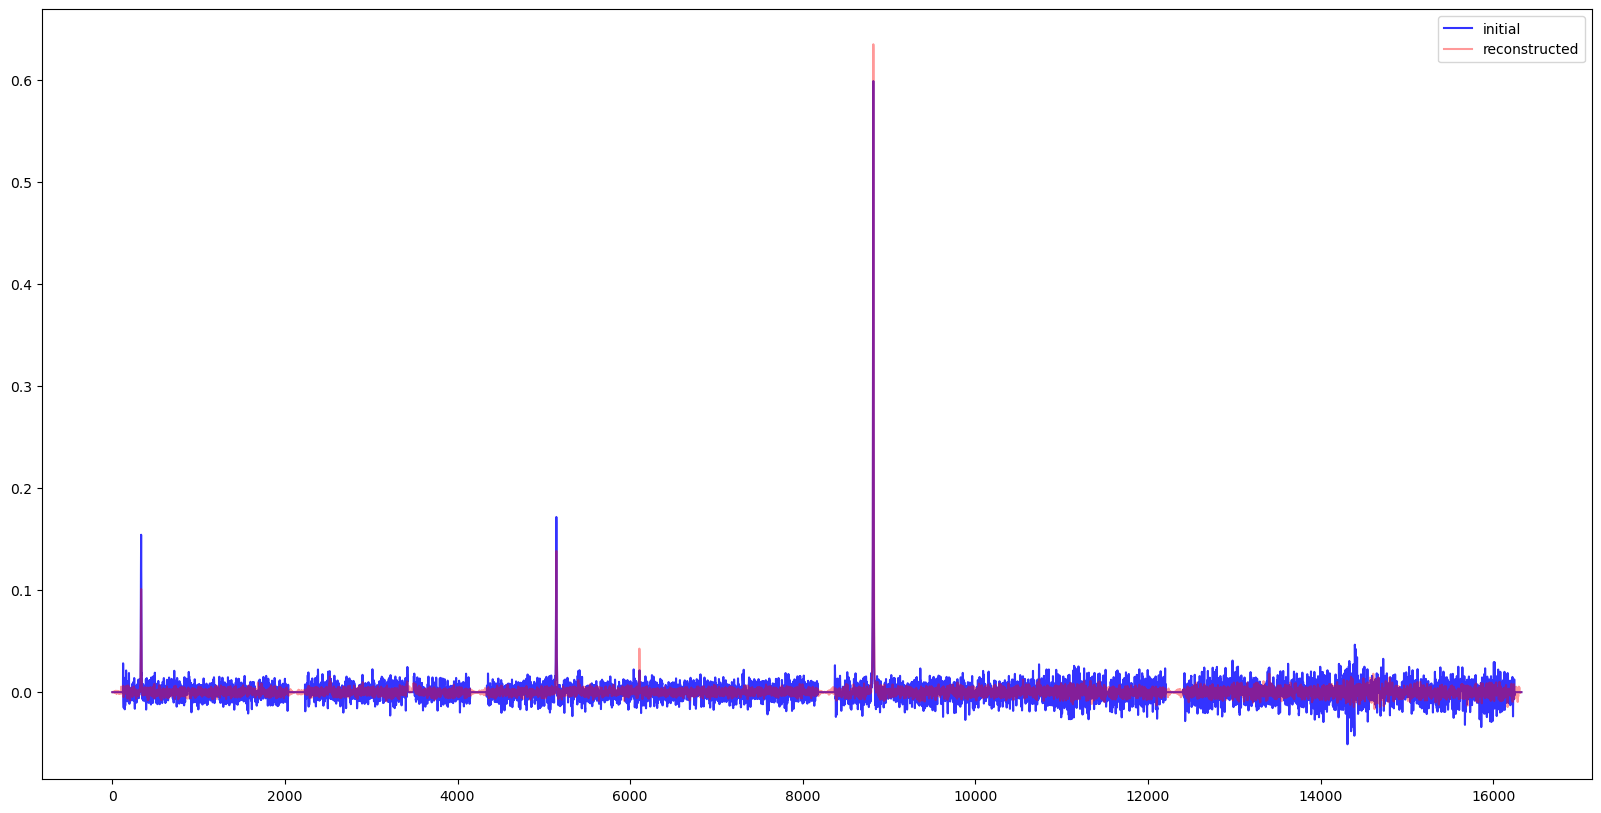

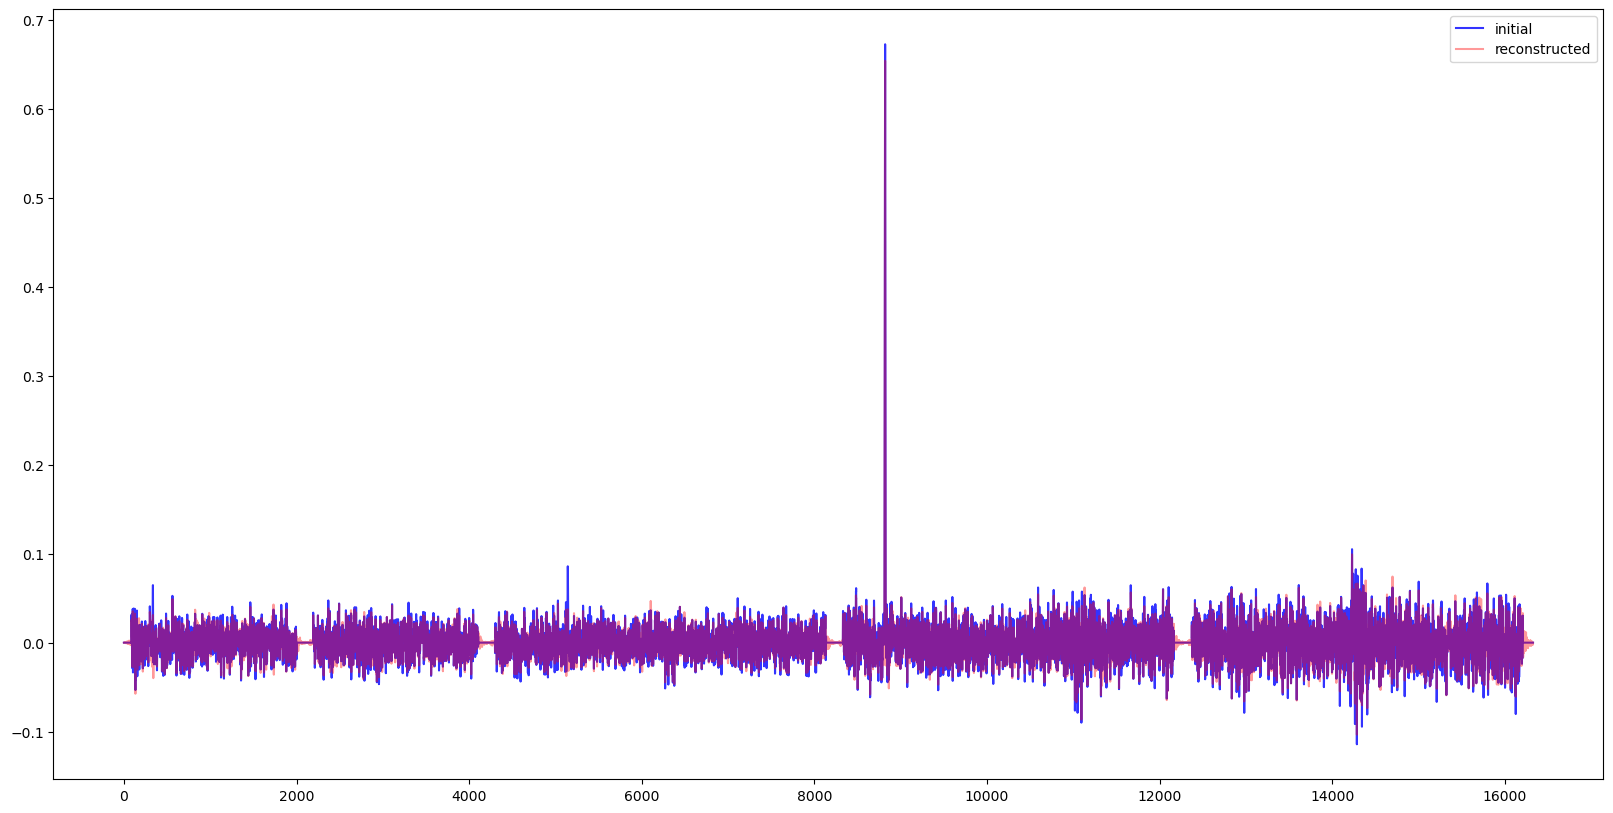

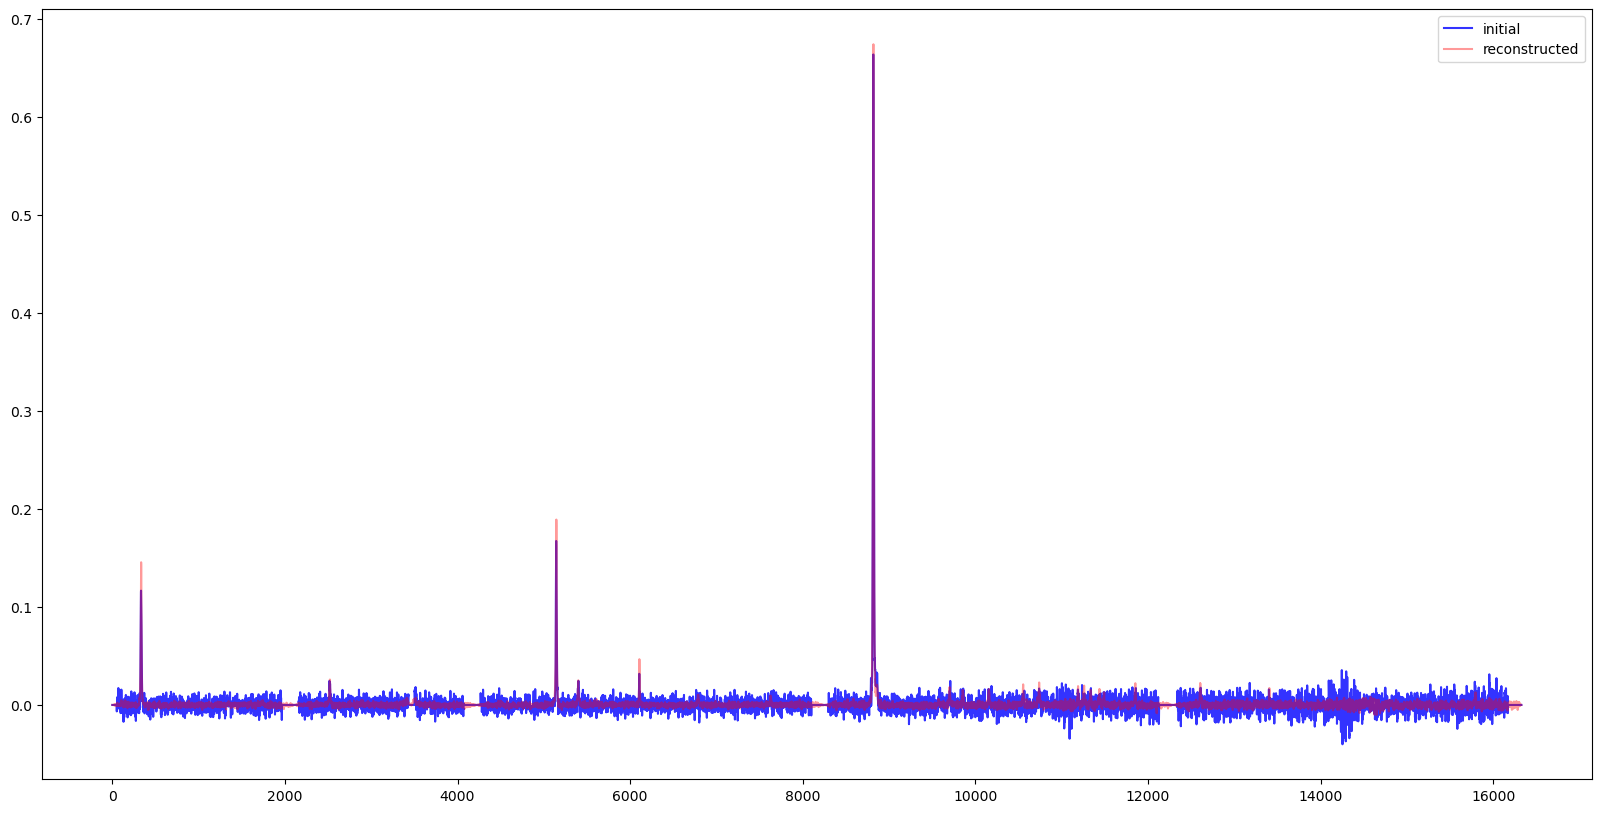

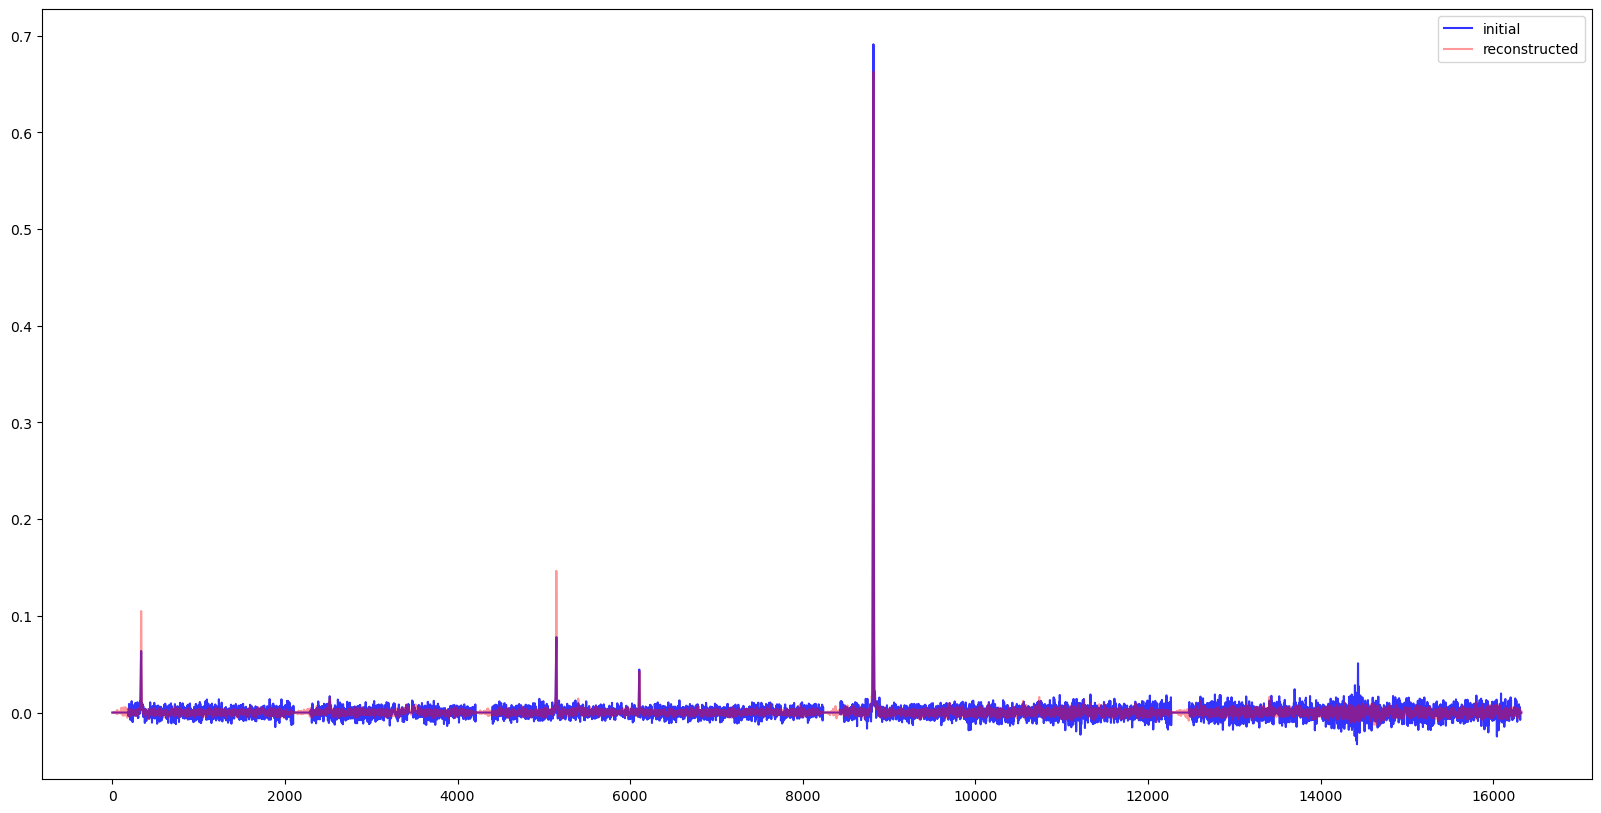

In [102]:
digits_reconstructed2 = digits_pca2 @ component2 + mean2

x=list(range(0,len(data_flux_outCO[0]),1))
for i in range(len(digits_pca2)):
    plt.figure(figsize=(20,10))
    plt.plot(data_flux_outCO[i],label="initial",color="blue",alpha=0.8)
    plt.plot(digits_reconstructed2[i],label="reconstructed",color="red",alpha=0.4)
#     # 标记重叠区域（例如差异小于阈值）
#     threshold = 0.1
#     overlap_mask = np.abs(data_flux[i] - digits_reconstructed[i]) < threshold
#     plt.fill_between(x,data_flux[i], digits_reconstructed[i], where=overlap_mask, color="green", alpha=0.8, label="Overlap Region")

    #plt.ylim(-0.01,0.05)
    plt.legend()
    plt.show()